#BAGIAN 1 — Preprocessing

In [6]:
pip install numpy matplotlib seaborn wordcloud plotly

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\emanuella\AppData\Local\Programs\Python\Python313\pythonw.exe -m pip install --upgrade pip


In [4]:
# =====================================================
# 1. IMPORT LIBRARY
# =====================================================
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.graph_objects as go

!pip install Sastrawi -q

# Tambahkan ini — import Sastrawi setelah install
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

ModuleNotFoundError: No module named 'pandas'

In [ ]:
#LOAD DATA
data_new = pd.read_csv("data_banjir.csv", sep=",", encoding="utf-8")
data_new

,text,clean_text,created_at,keyword,processed_text,sentimen,label,emoticon
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit menemukan siapa pemilik kayu yg m...,2026-01-13,Banjir Sumatra 2025,polisi sulit temu siapa milik kayu sebab banji...,negatif,0.0,NaN
1,Seorang Ibu harus memanjat tebing demi membawa...,seorang ibu harus memanjat tebing demi membawa...,2026-01-13,Banjir Sumatra 2025,orang ibu panjat tebing bawa bayi puskesmas ga...,negatif,0.0,NaN
2,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,waspada banjir pesisir durasi januari,2026-01-13,Banjir Sumatra 2025,waspada banjir pesisir durasi januari,netral,1.0,NaN
3,Konsistensi Toba Pulp Lestari menerapkan prins...,konsistensi toba pulp lestari menerapkan prins...,2026-01-12,Banjir Sumatra 2025,konsistensi toba pulp lestari terap prinsip la...,netral,1.0,NaN
4,BANJIR bandang yang menghancurkan kawasan Aceh...,banjir bandang yang menghancurkan kawasan aceh...,2026-01-12,Banjir Sumatra 2025,banjir bandang hancur kawasan aceh sumatra uta...,negatif,0.0,NaN
...,...,...,...,...,...,...,...,...
8643,"Definisi ""membaik"" dalam konteks bencana BNPB ...",definisi membaik dalam konteks bencana bnpb bi...,2025-11-29,banjir Sumatera Barat,definisi baik konteks bencana bnpb biasa rujuk...,negatif,0.0,NaN
8644,Beberapa hari terakhir ini saudara-saudara kit...,beberapa hari terakhir ini saudara saudara kit...,2025-11-29,banjir Sumatera Barat,beberapa hari akhir saudara saudara aceh sumat...,netral,1.0,NaN
8645,BNPB ungkapkan alasan mengapa bencana banjir d...,bnpb ungkapkan alasan mengapa bencana banjir d...,2025-11-29,banjir Sumatera Barat,bnpb ungkap alas bencana banjir wilayah sumate...,netral,1.0,NaN
8646,Markas Besar Tentara Nasional Indonesia (Mabes...,markas besar tentara nasional indonesia mabes ...,2025-11-29,banjir Sumatera Barat,markas besar tentara nasional indonesia mabes ...,positif,2.0,NaN


In [ ]:
print(data_new.head())
print(data_new.columns)
print("Total data:", len(data_new))

                                                text  \
0  Polisi : Sulit menemukan siapa pemilik kayu yg...   
1  Seorang Ibu harus memanjat tebing demi membawa...   
2  WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...   
3  Konsistensi Toba Pulp Lestari menerapkan prins...   
4  BANJIR bandang yang menghancurkan kawasan Aceh...   

                                          clean_text  created_at  \
0  polisi sulit menemukan siapa pemilik kayu yg m...  2026-01-13   
1  seorang ibu harus memanjat tebing demi membawa...  2026-01-13   
2              waspada banjir pesisir durasi januari  2026-01-13   
3  konsistensi toba pulp lestari menerapkan prins...  2026-01-12   
4  banjir bandang yang menghancurkan kawasan aceh...  2026-01-12   

               keyword                                     processed_text  \
0  Banjir Sumatra 2025  polisi sulit temu siapa milik kayu sebab banji...   
1  Banjir Sumatra 2025  orang ibu panjat tebing bawa bayi puskesmas ga...   
2  Banjir Sumatra 2025 

In [ ]:
#Cek label sentimen
total_data = len(data_new)
sentimen_count = data_new['sentimen'].value_counts()

print("Total data:", total_data)
print("Negatif:", sentimen_count.get('negatif', 0))
print("Netral :", sentimen_count.get('netral', 0))
print("Positif:", sentimen_count.get('positif', 0))

Total data: 8648
Negatif: 4843
Netral : 1465
Positif: 2340


In [ ]:
#Tabel distribusi sentimen
distribusi = data_new['sentimen'].value_counts().reset_index()
distribusi.columns = ['sentimen', 'jumlah']
distribusi['persentase'] = distribusi['jumlah'] / distribusi['jumlah'].sum() * 100

print(distribusi)

  sentimen  jumlah  persentase
0  negatif    4843   56.001388
1  positif    2340   27.058279
2   netral    1465   16.940333


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import re

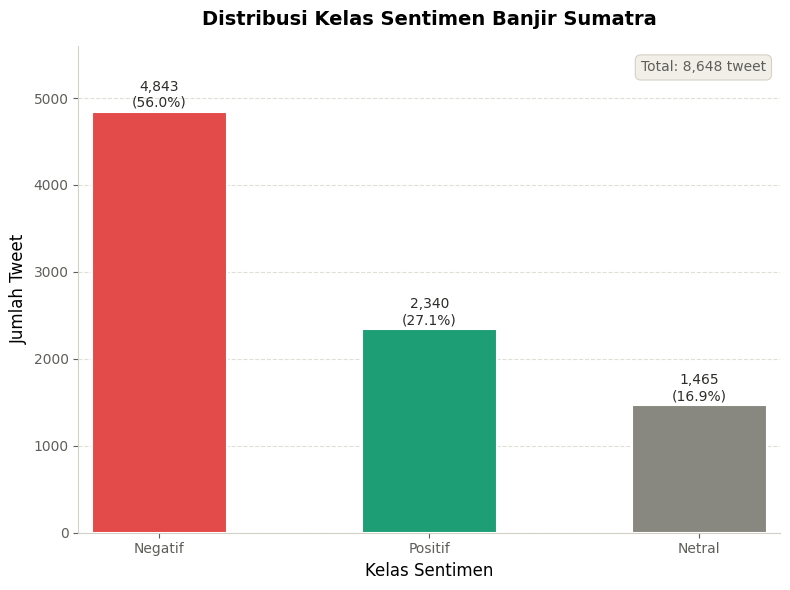

Chart berhasil disimpan!


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =====================================================
# DATA
# =====================================================
data = {
    'Sentimen': ['Negatif', 'Positif', 'Netral'],
    'Jumlah'  : [4843, 2340, 1465],
    'Persen'  : [56.0, 27.1, 16.9]
}
df = pd.DataFrame(data)
total = sum(df['Jumlah'])
colors = ['#E24B4A', '#1D9E75', '#888780']

# =====================================================
# BAR CHART
# =====================================================
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(df['Sentimen']))
width = 0.5  # dinaikkan

bars = ax.bar(
    x, df['Jumlah'],
    color=colors, width=width,
    edgecolor='white', linewidth=1.5
)

# Label di atas bar
for bar, jml, pct in zip(bars, df['Jumlah'], df['Persen']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{jml:,}\n({pct}%)',
        ha='center', va='bottom',
        fontsize=10, color='#2C2C2A'
    )

# Total di pojok kanan atas
ax.text(
    0.98, 0.97,
    f'Total: {total:,} tweet',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=10, color='#5F5E5A',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#F1EFE8',
              edgecolor='#D3D1C7',
              linewidth=0.8)
)

ax.set_title('Distribusi Kelas Sentimen Banjir Sumatra',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kelas Sentimen', fontsize=12)
ax.set_ylabel('Jumlah Tweet', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df['Sentimen'])
ax.set_xlim(-0.3, 2.3)  # dipersempit
ax.set_ylim(0, 5600)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D3D1C7')
ax.spines['bottom'].set_color('#D3D1C7')
ax.yaxis.grid(True, color='#D3D1C7',
              linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.tick_params(colors='#5F5E5A')

plt.tight_layout()
plt.savefig('distribusi_sentimen.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Chart berhasil disimpan!")

In [ ]:
#cek emoticon
print("Jumlah data dengan emoticon:")
print(data_new['emoticon'].notna().sum())

print("\nContoh data dengan emoticon:")
print(data_new.loc[data_new['emoticon'].notna(), ['text', 'emoticon']].head(20))

print("\nFrekuensi emoticon:")
print(data_new['emoticon'].dropna().value_counts().head(30))

Jumlah data dengan emoticon:
165

Contoh data dengan emoticon:
                                                   text emoticon
7674  Satgas PKH turun tangan selidiki penyebab banj...      🇮🇩💪
7682  Ramadhan  Hampir tiba, ratusan Mesjid  masih b...       ✨🤝
7695  Seorang Ibu harus memanjat tebing demi membawa...     🌀📍👶🤱
7701  Terimakasih ya orang-orang baik sudah menyisih...      🙏🏻🥹
7702  Selain popok, makanan bayi, biskuit, minyak ka...        😢
7721  Lebih dari 45 hari bencanaGampong Sikundo, Ace...       📍🗓
7728  Akhirnya... Turut dilanda banjir setelah hujan...      😊🙏🏻
7735  sekarang, sumatera selatan terkhusus oku timur...       🙏🏻
7740  emng di arah rs abdul muluk banjir ya?? masa p...        🦧
7743  Ngeliat video banjir where ada orang yang naik...        💔
7745  Kok gak ada lagi berita musibah Sumatera yaa.....        👍
7750  Alhamdulillah...   Terima kasih telah membantu...        🥰
7753  Wirit subuh (Al Matsurat)  Santri Pesantren Ya...       🙏😊
7755  "Bantu Yatim Tapanuli

In [ ]:
#Konversi emoticon menjadi kata
emoji_dict = {
    # sedih / duka / prihatin
    "😭": " sedih ",
    "😢": " sedih ",
    "🥲": " sedih ",
    "🥺": " sedih ",
    "😔": " sedih ",
    "😞": " sedih ",
    "💔": " sedih ",
    "🥀": " sedih ",
    "❤️‍🩹": " pulih ",

    # doa / harapan / empati
    "🙏": " doa ",
    "🙏🏻": " doa ",
    "🤲": " doa ",
    "🥹": " haru ",

    # dukungan / apresiasi / semangat
    "💪": " semangat ",
    "👍": " setuju ",
    "✅": " setuju ",
    "🤝": " kerja sama ",
    "💖": " dukungan ",
    "❤️": " dukungan ",
    "❤": " dukungan ",
    "🤍": " dukungan ",
    "💚": " dukungan ",

    # positif / senang
    "😊": " senang ",
    "☺️": " senang ",
    "🥰": " senang ",

    # peringatan / darurat
    "🚨": " darurat ",
    "‼️": " peringatan ",
    "📢": " informasi ",
    "📍": " lokasi ",
    "🗓": " waktu ",
    "🌧️": " hujan ",
    "🌀": " badai ",

    # bingung / tanya / kritik
    "🤔": " bingung ",
    "🙃": " bingung ",

    # tertawa
    "🤣": " tertawa ",

    # lainnya, jika tidak terlalu relevan
    "🎥": " video ",
    "👶": " bayi ",
    "🤱": " ibu bayi ",
    "🇮🇩": " indonesia "
}

In [ ]:
def convert_emoticon(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Urutkan emoji paling panjang dulu agar kombinasi seperti ❤️‍🩹 tidak pecah
    for emo in sorted(emoji_dict.keys(), key=len, reverse=True):
        text = text.replace(emo, emoji_dict[emo])

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
#Gabungkan text dan emoticon
data_new['emoticon'] = data_new['emoticon'].fillna('')

data_new['text_with_emoticon_raw'] = (
    data_new['text'].astype(str) + ' ' + data_new['emoticon'].astype(str)
)

data_new['text_with_emoticon'] = data_new['text_with_emoticon_raw'].apply(convert_emoticon)

print("Contoh hasil gabungan khusus data yang punya emoticon:")
display(
    data_new.loc[data_new['emoticon'] != '',
                 ['text', 'emoticon', 'text_with_emoticon_raw', 'text_with_emoticon', 'sentimen']]
    .head(30)
)

Contoh hasil gabungan khusus data yang punya emoticon:


,text,emoticon,text_with_emoticon_raw,text_with_emoticon,sentimen
7674,Satgas PKH turun tangan selidiki penyebab banj...,🇮🇩💪,Satgas PKH turun tangan selidiki penyebab banj...,Satgas PKH turun tangan selidiki penyebab banj...,negatif
7682,"Ramadhan Hampir tiba, ratusan Mesjid masih b...",✨🤝,"Ramadhan Hampir tiba, ratusan Mesjid masih b...","Ramadhan Hampir tiba, ratusan Mesjid masih bel...",negatif
7695,Seorang Ibu harus memanjat tebing demi membawa...,🌀📍👶🤱,Seorang Ibu harus memanjat tebing demi membawa...,Seorang Ibu harus memanjat tebing demi membawa...,negatif
7701,Terimakasih ya orang-orang baik sudah menyisih...,🙏🏻🥹,Terimakasih ya orang-orang baik sudah menyisih...,Terimakasih ya orang-orang baik sudah menyisih...,positif
7702,"Selain popok, makanan bayi, biskuit, minyak ka...",😢,"Selain popok, makanan bayi, biskuit, minyak ka...","Selain popok, makanan bayi, biskuit, minyak ka...",positif
7721,"Lebih dari 45 hari bencanaGampong Sikundo, Ace...",📍🗓,"Lebih dari 45 hari bencanaGampong Sikundo, Ace...","Lebih dari 45 hari bencanaGampong Sikundo, Ace...",negatif
7728,Akhirnya... Turut dilanda banjir setelah hujan...,😊🙏🏻,Akhirnya... Turut dilanda banjir setelah hujan...,Akhirnya... Turut dilanda banjir setelah hujan...,positif
7735,"sekarang, sumatera selatan terkhusus oku timur...",🙏🏻,"sekarang, sumatera selatan terkhusus oku timur...","sekarang, sumatera selatan terkhusus oku timur...",negatif
7740,emng di arah rs abdul muluk banjir ya?? masa p...,🦧,emng di arah rs abdul muluk banjir ya?? masa p...,emng di arah rs abdul muluk banjir ya?? masa p...,negatif
7743,Ngeliat video banjir where ada orang yang naik...,💔,Ngeliat video banjir where ada orang yang naik...,Ngeliat video banjir where ada orang yang naik...,netral


In [ ]:
cek_emoticon = data_new.loc[
    data_new['emoticon'] != '',
    ['text', 'emoticon', 'text_with_emoticon']
].copy()

display(cek_emoticon.head(50))

,text,emoticon,text_with_emoticon
7674,Satgas PKH turun tangan selidiki penyebab banj...,🇮🇩💪,Satgas PKH turun tangan selidiki penyebab banj...
7682,"Ramadhan Hampir tiba, ratusan Mesjid masih b...",✨🤝,"Ramadhan Hampir tiba, ratusan Mesjid masih bel..."
7695,Seorang Ibu harus memanjat tebing demi membawa...,🌀📍👶🤱,Seorang Ibu harus memanjat tebing demi membawa...
7701,Terimakasih ya orang-orang baik sudah menyisih...,🙏🏻🥹,Terimakasih ya orang-orang baik sudah menyisih...
7702,"Selain popok, makanan bayi, biskuit, minyak ka...",😢,"Selain popok, makanan bayi, biskuit, minyak ka..."
7721,"Lebih dari 45 hari bencanaGampong Sikundo, Ace...",📍🗓,"Lebih dari 45 hari bencanaGampong Sikundo, Ace..."
7728,Akhirnya... Turut dilanda banjir setelah hujan...,😊🙏🏻,Akhirnya... Turut dilanda banjir setelah hujan...
7735,"sekarang, sumatera selatan terkhusus oku timur...",🙏🏻,"sekarang, sumatera selatan terkhusus oku timur..."
7740,emng di arah rs abdul muluk banjir ya?? masa p...,🦧,emng di arah rs abdul muluk banjir ya?? masa p...
7743,Ngeliat video banjir where ada orang yang naik...,💔,Ngeliat video banjir where ada orang yang naik...


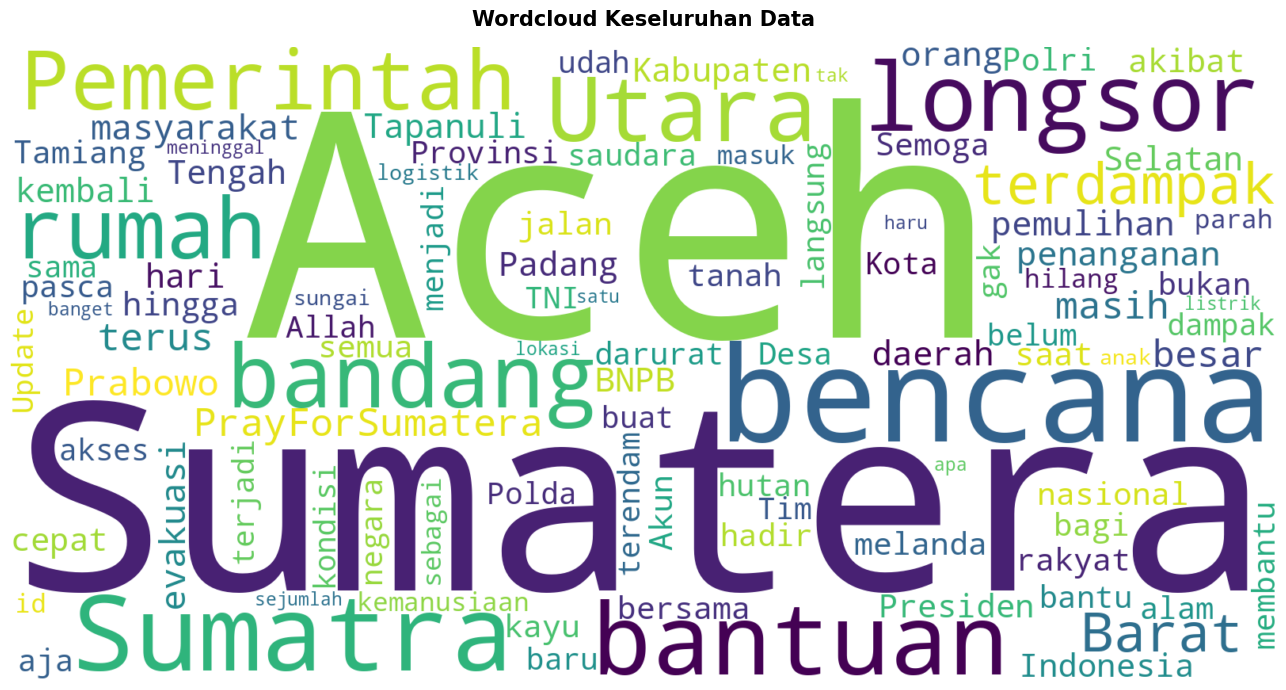

Wordcloud keseluruhan disimpan!


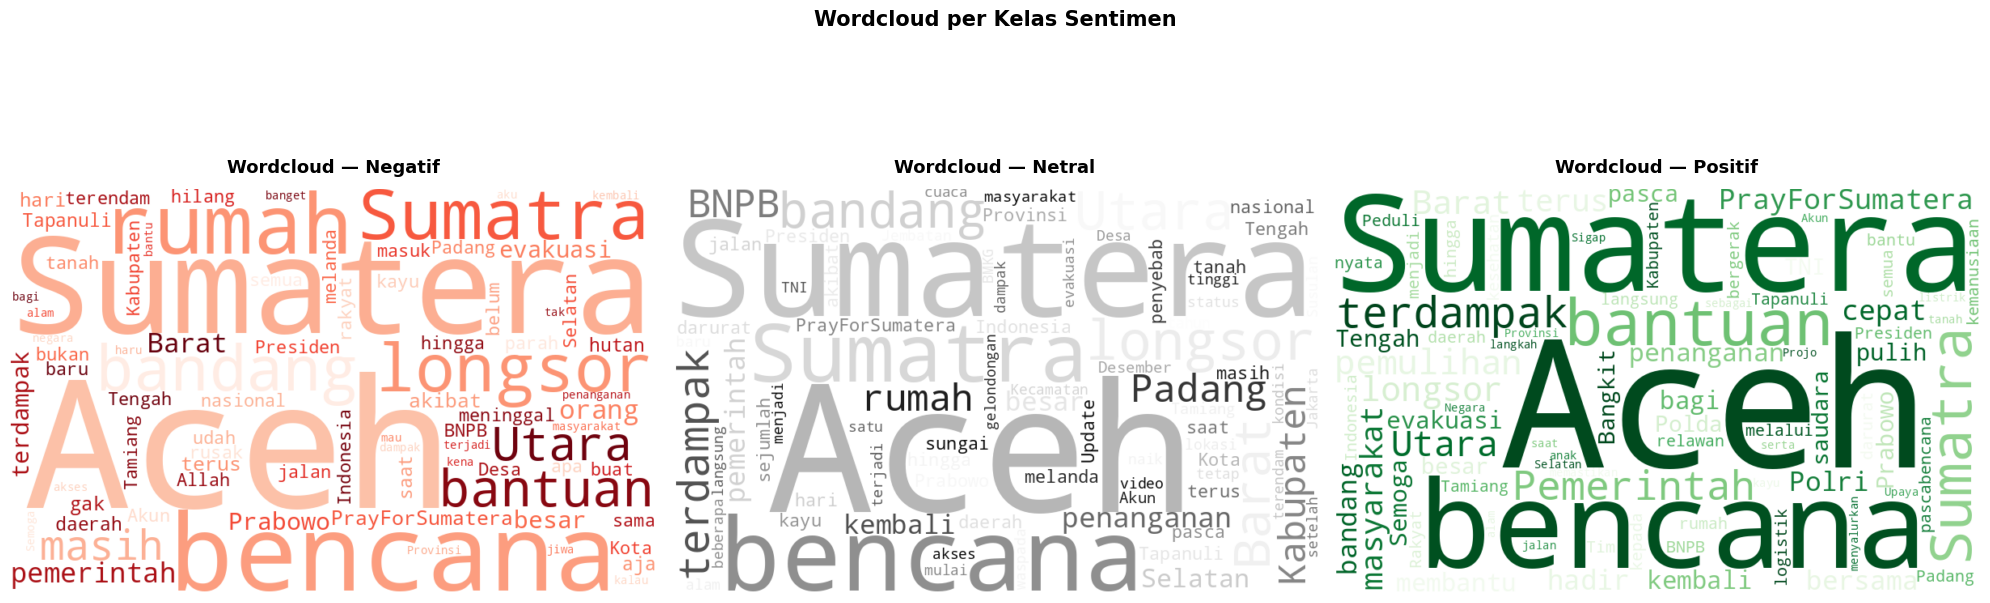

Wordcloud per kelas disimpan!


In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# =====================================================
# STOPWORD
# =====================================================
custom_stopwords = set(STOPWORDS)

custom_stopwords.update([
    'yang', 'dan', 'untuk', 'ini', 'itu', 'di', 'ke', 'dari',
    'dengan', 'pada', 'adalah', 'akan', 'sudah', 'ada', 'juga',
    'tidak', 'bisa', 'lebih', 'kita', 'saya', 'kami', 'mereka',
    'atau', 'tapi', 'karena', 'jadi', 'lagi', 'banyak', 'dalam',
    'ya', 'ga', 'yg', 'rb', 'com', 'tampilkan', 'membalas',
    'nya', 'ber', 'ter', 'me', 'kan', 'lah', 'pun', 'ku',
    'si', 'sang', 'para', 'namun', 'walau', 'meski',
    'https', 'http', 'co', 'pic', 'twitter',

    # lokasi
    'sumut', 'sumbar', 'sumsel',
    'riau', 'jambi', 'lampung',

    # kata terlalu umum
    'banjir', 'warga', 'korban',
    'air', 'hujan', 'wilayah'
])

# =====================================================
# WORDCLOUD KESELURUHAN
# =====================================================

# PAKAI TEXT + EMOTICON
teks_all = ' '.join(data_new['text_with_emoticon'])

wc_all = WordCloud(
    width=1600,
    height=800,
    max_words=100,
    background_color='white',
    colormap='viridis',
    stopwords=custom_stopwords,
    collocations=False,
    min_font_size=10
).generate(teks_all)

plt.figure(figsize=(14, 7))

plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')

plt.title(
    'Wordcloud Keseluruhan Data',
    fontsize=15,
    fontweight='bold',
    pad=15
)

plt.tight_layout()

plt.savefig(
    'wordcloud_keseluruhan.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Wordcloud keseluruhan disimpan!")

# =====================================================
# WORDCLOUD PER KELAS SENTIMEN
# =====================================================

warna = {
    'negatif': 'Reds',
    'netral' : 'Greys',
    'positif': 'Greens'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, sentimen in zip(
    axes,
    ['negatif', 'netral', 'positif']
):

    teks = ' '.join(
        data_new[
            data_new['sentimen'] == sentimen
        ]['text_with_emoticon']
    )

    wc = WordCloud(
        width=800,
        height=500,
        max_words=80,
        background_color='white',
        colormap=warna[sentimen],
        stopwords=custom_stopwords,
        collocations=False,
        min_font_size=10
    ).generate(teks)

    ax.imshow(wc, interpolation='bilinear')

    ax.axis('off')

    ax.set_title(
        f'Wordcloud — {sentimen.capitalize()}',
        fontsize=13,
        fontweight='bold',
        pad=12
    )

plt.suptitle(
    'Wordcloud per Kelas Sentimen',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'wordcloud_per_kelas.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Wordcloud per kelas disimpan!")

Prepocessing LSTM

In [ ]:
normalisasi_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "ngga": "tidak",
    "tdk": "tidak",
    "tak": "tidak",
    "bgt": "banget",
    "bangett": "banget",
    "dr": "dari",
    "dri": "dari",
    "yg": "yang",
    "dgn": "dengan",
    "krn": "karena",
    "karna": "karena",
    "tp": "tapi",
    "tpi": "tapi",
    "jd": "jadi",
    "udh": "sudah",
    "udah": "sudah",
    "sm": "sama",
    "aja": "saja",
    "utk": "untuk",
    "dlm": "dalam",
    "org": "orang",
    "w": "saya",
    "gw": "saya",
    "gue": "saya",
    "lo": "kamu",
    "lu": "kamu"
}

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

# Kata ini jangan dihapus karena punya sinyal sentimen
keep_words = {
    "tidak", "bukan", "jangan", "belum",
    "sedih", "marah", "senang", "doa",
    "dukungan", "setuju", "semangat",
    "tertawa", "bingung", "haru", "pulih",
    "peringatan", "darurat", "hujan", "badai",
    "lokasi", "informasi", "harapan", "takut"
}

stopwords = stopwords - keep_words

stemmer = StemmerFactory().create_stemmer()
stem_cache = {}

def preprocess_lstm(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Hapus URL dan mention
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)

    # Hashtag tetap ambil katanya
    text = re.sub(r"#(\w+)", r"\1", text)

    # Hapus noise hasil scraping
    text = re.sub(r'\bcom\b', '', text)
    text = re.sub(r'\brb\b', '', text)
    text = re.sub(r'\btampilkan\b', '', text)
    text = re.sub(r'\bmembalas\b', '', text)

    # Hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenizing
    tokens = text.split()

    # Normalisasi
    tokens = [normalisasi_dict.get(w, w) for w in tokens]

    # Stopword removal
    tokens = [w for w in tokens if w not in stopwords]

    # Stemming
    result = []
    for word in tokens:
        if word not in stem_cache:
            stem_cache[word] = stemmer.stem(word)
        result.append(stem_cache[word])

    return ' '.join(result)

Prepocessing IndoBERT

In [ ]:
def preprocess_bert(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Hapus URL dan mention
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)

    # Hashtag tetap ambil katanya
    text = re.sub(r"#(\w+)", r"\1", text)

    # Rapikan simbol yang sering mengganggu
    text = re.sub(r"[:]", " ", text)

    # Rapikan spasi
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
print("Preprocessing BiLSTM...")
data_new['clean_text_lstm'] = data_new['text_with_emoticon'].apply(preprocess_lstm)

print("Preprocessing IndoBERTweet-LoRA...")
data_new['text_bert'] = data_new['text_with_emoticon'].apply(preprocess_bert)

print("Selesai.")

display(
    data_new.loc[data_new['emoticon'] != '',
                 ['text', 'emoticon', 'text_with_emoticon', 'clean_text_lstm', 'text_bert', 'sentimen']]
    .head(30)
)

Preprocessing BiLSTM...
Preprocessing IndoBERTweet-LoRA...
Selesai.


,text,emoticon,text_with_emoticon,clean_text_lstm,text_bert,sentimen
7674,Satgas PKH turun tangan selidiki penyebab banj...,🇮🇩💪,Satgas PKH turun tangan selidiki penyebab banj...,satgas pkh turun tangan selidik sebab banjir s...,Satgas PKH turun tangan selidiki penyebab banj...,negatif
7682,"Ramadhan Hampir tiba, ratusan Mesjid masih b...",✨🤝,"Ramadhan Hampir tiba, ratusan Mesjid masih bel...",ramadhan hampir tiba ratus mesjid belum bersih...,"Ramadhan Hampir tiba, ratusan Mesjid masih bel...",negatif
7695,Seorang Ibu harus memanjat tebing demi membawa...,🌀📍👶🤱,Seorang Ibu harus memanjat tebing demi membawa...,orang ibu panjat tebing bawa bayi puskesmas ga...,Seorang Ibu harus memanjat tebing demi membawa...,negatif
7701,Terimakasih ya orang-orang baik sudah menyisih...,🙏🏻🥹,Terimakasih ya orang-orang baik sudah menyisih...,terimakasih orang orang baik sisih warga dampa...,Terimakasih ya orang-orang baik sudah menyisih...,positif
7702,"Selain popok, makanan bayi, biskuit, minyak ka...",😢,"Selain popok, makanan bayi, biskuit, minyak ka...",popok makan bayi biskuit minyak kayu putih baw...,"Selain popok, makanan bayi, biskuit, minyak ka...",positif
7721,"Lebih dari 45 hari bencanaGampong Sikundo, Ace...",📍🗓,"Lebih dari 45 hari bencanaGampong Sikundo, Ace...",lebih hari bencanagampong sikundo aceh barat i...,"Lebih dari 45 hari bencanaGampong Sikundo, Ace...",negatif
7728,Akhirnya... Turut dilanda banjir setelah hujan...,😊🙏🏻,Akhirnya... Turut dilanda banjir setelah hujan...,akhir turut landa banjir hujan deras hari mala...,Akhirnya... Turut dilanda banjir setelah hujan...,positif
7735,"sekarang, sumatera selatan terkhusus oku timur...",🙏🏻,"sekarang, sumatera selatan terkhusus oku timur...",sekarang sumatera selatan khusus oku timur ker...,"sekarang, sumatera selatan terkhusus oku timur...",negatif
7740,emng di arah rs abdul muluk banjir ya?? masa p...,🦧,emng di arah rs abdul muluk banjir ya?? masa p...,emng arah rs abdul muluk banjir masa paket aku...,emng di arah rs abdul muluk banjir ya?? masa p...,negatif
7743,Ngeliat video banjir where ada orang yang naik...,💔,Ngeliat video banjir where ada orang yang naik...,ngeliat video banjir where orang naik pohon ki...,Ngeliat video banjir where ada orang yang naik...,netral


In [ ]:
#Encode label
label_map = {
    'negatif': 0,
    'netral': 1,
    'positif': 2
}

data_new['label'] = data_new['sentimen'].map(label_map).astype(int)

print(data_new[['sentimen', 'label']].head())
print(data_new['label'].value_counts().sort_index())

  sentimen  label
0  negatif      0
1  negatif      0
2   netral      1
3   netral      1
4  negatif      0
label
0    4843
1    1465
2    2340
Name: count, dtype: int64


In [ ]:
#Simpan hasil preprocessing
data_new.to_pickle('data_preprocessed_with_emoticon.pkl')
data_new.to_csv('data_preprocessed_with_emoticon.csv', index=False)

print("Data hasil preprocessing dengan emoticon berhasil disimpan.")

Data hasil preprocessing dengan emoticon berhasil disimpan.


In [ ]:
#Lihat perbandingan data sebelum dan sesudah preprocessing
display(
    data_new[['text', 'emoticon', 'text_with_emoticon', 'clean_text_lstm', 'text_bert', 'sentimen', 'label']]
    .head(20)
)

,text,emoticon,text_with_emoticon,clean_text_lstm,text_bert,sentimen,label
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit temu siapa milik kayu sebab banji...,Polisi Sulit menemukan siapa pemilik kayu yg m...,negatif,0
1,Seorang Ibu harus memanjat tebing demi membawa...,,Seorang Ibu harus memanjat tebing demi membawa...,orang ibu panjat tebing bawa bayi puskesmas ga...,Seorang Ibu harus memanjat tebing demi membawa...,negatif,0
2,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,,WASPADA BANJIR PESISIR Durasi: 13 - 20 Januari...,waspada banjir pesisir durasi januari,WASPADA BANJIR PESISIR Durasi 13 - 20 Januari ...,netral,1
3,Konsistensi Toba Pulp Lestari menerapkan prins...,,Konsistensi Toba Pulp Lestari menerapkan prins...,konsistensi toba pulp lestari terap prinsip la...,Konsistensi Toba Pulp Lestari menerapkan prins...,netral,1
4,BANJIR bandang yang menghancurkan kawasan Aceh...,,BANJIR bandang yang menghancurkan kawasan Aceh...,banjir bandang hancur kawasan aceh sumatra uta...,BANJIR bandang yang menghancurkan kawasan Aceh...,negatif,0
5,"Be honest, what do you see? This isn’t the re...",,"Be honest, what do you see? This isn’t the res...",be honest what do you see this isn t the resul...,"Be honest, what do you see? This isn’t the res...",negatif,0
6,Masyarakat Aceh terpaksa mengangkut barang dag...,,Masyarakat Aceh terpaksa mengangkut barang dag...,masyarakat aceh paksa angkut barang dagang but...,Masyarakat Aceh terpaksa mengangkut barang dag...,negatif,0
7,"Melalui Nurani Astra, Astra bersama Grup Astra...",,"Melalui Nurani Astra, Astra bersama Grup Astra...",lalu nurani astra astra sama grup astra salur ...,"Melalui Nurani Astra, Astra bersama Grup Astra...",positif,2
8,BANJIR susulan masih menjadi kekhawatiran masy...,,BANJIR susulan masih menjadi kekhawatiran masy...,banjir susul jadi khawatir masyarakat jumlah w...,BANJIR susulan masih menjadi kekhawatiran masy...,netral,1
9,Akun komentar Belum ada shalat berjamaah di Me...,,Akun komentar Belum ada shalat berjamaah di Me...,akun komentar belum shalat jamaah mesjid sejak...,Akun komentar Belum ada shalat berjamaah di Me...,netral,1


In [ ]:
#Lihat hanya data yang ada emoticon setelah digabung
display(
    data_new.loc[data_new['emoticon'] != '',
                 ['text', 'emoticon', 'text_with_emoticon', 'clean_text_lstm', 'text_bert', 'sentimen', 'label']]
    .head(50)
)

,text,emoticon,text_with_emoticon,clean_text_lstm,text_bert,sentimen,label
7674,Satgas PKH turun tangan selidiki penyebab banj...,🇮🇩💪,Satgas PKH turun tangan selidiki penyebab banj...,satgas pkh turun tangan selidik sebab banjir s...,Satgas PKH turun tangan selidiki penyebab banj...,negatif,0
7682,"Ramadhan Hampir tiba, ratusan Mesjid masih b...",✨🤝,"Ramadhan Hampir tiba, ratusan Mesjid masih bel...",ramadhan hampir tiba ratus mesjid belum bersih...,"Ramadhan Hampir tiba, ratusan Mesjid masih bel...",negatif,0
7695,Seorang Ibu harus memanjat tebing demi membawa...,🌀📍👶🤱,Seorang Ibu harus memanjat tebing demi membawa...,orang ibu panjat tebing bawa bayi puskesmas ga...,Seorang Ibu harus memanjat tebing demi membawa...,negatif,0
7701,Terimakasih ya orang-orang baik sudah menyisih...,🙏🏻🥹,Terimakasih ya orang-orang baik sudah menyisih...,terimakasih orang orang baik sisih warga dampa...,Terimakasih ya orang-orang baik sudah menyisih...,positif,2
7702,"Selain popok, makanan bayi, biskuit, minyak ka...",😢,"Selain popok, makanan bayi, biskuit, minyak ka...",popok makan bayi biskuit minyak kayu putih baw...,"Selain popok, makanan bayi, biskuit, minyak ka...",positif,2
7721,"Lebih dari 45 hari bencanaGampong Sikundo, Ace...",📍🗓,"Lebih dari 45 hari bencanaGampong Sikundo, Ace...",lebih hari bencanagampong sikundo aceh barat i...,"Lebih dari 45 hari bencanaGampong Sikundo, Ace...",negatif,0
7728,Akhirnya... Turut dilanda banjir setelah hujan...,😊🙏🏻,Akhirnya... Turut dilanda banjir setelah hujan...,akhir turut landa banjir hujan deras hari mala...,Akhirnya... Turut dilanda banjir setelah hujan...,positif,2
7735,"sekarang, sumatera selatan terkhusus oku timur...",🙏🏻,"sekarang, sumatera selatan terkhusus oku timur...",sekarang sumatera selatan khusus oku timur ker...,"sekarang, sumatera selatan terkhusus oku timur...",negatif,0
7740,emng di arah rs abdul muluk banjir ya?? masa p...,🦧,emng di arah rs abdul muluk banjir ya?? masa p...,emng arah rs abdul muluk banjir masa paket aku...,emng di arah rs abdul muluk banjir ya?? masa p...,negatif,0
7743,Ngeliat video banjir where ada orang yang naik...,💔,Ngeliat video banjir where ada orang yang naik...,ngeliat video banjir where orang naik pohon ki...,Ngeliat video banjir where ada orang yang naik...,netral,1


BAGIAN 2 — Split Data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# =====================================================
# 11. SPLIT DATA — dengan reset_index ← PERUBAHAN UTAMA
# =====================================================
train_idx, test_idx = train_test_split(
    data_new.index,
    test_size=0.2,
    stratify=data_new['label'],
    random_state=42
)

# RESET INDEX — ini yang penting!
X_train_lstm = data_new.loc[train_idx, 'clean_text_lstm'].reset_index(drop=True)
X_test_lstm  = data_new.loc[test_idx,  'clean_text_lstm'].reset_index(drop=True)
X_train_bert = data_new.loc[train_idx, 'text_bert'].reset_index(drop=True)
X_test_bert  = data_new.loc[test_idx,  'text_bert'].reset_index(drop=True)
y_train      = data_new.loc[train_idx, 'label'].reset_index(drop=True)
y_test       = data_new.loc[test_idx,  'label'].reset_index(drop=True)

print("Distribusi y_train:")
print(y_train.value_counts().sort_index())
print("\nDistribusi y_test:")
print(y_test.value_counts().sort_index())
print(f"\nTotal train: {len(y_train)}, Total test: {len(y_test)}")

Distribusi y_train:
label
0    3874
1    1172
2    1872
Name: count, dtype: int64

Distribusi y_test:
label
0    969
1    293
2    468
Name: count, dtype: int64

Total train: 6918, Total test: 1730


In [ ]:
import pickle

In [ ]:
# =====================================================
# 12. SIMPAN SPLIT DATA
# =====================================================
with open('split_data.pkl', 'wb') as f:
    pickle.dump({
        'X_train_lstm': X_train_lstm,
        'X_test_lstm' : X_test_lstm,
        'X_train_bert': X_train_bert,
        'X_test_bert' : X_test_bert,
        'y_train'     : y_train,
        'y_test'      : y_test
    }, f)

print("Split data berhasil disimpan ke split_data.pkl!")
print("Notebook 1 selesai — lanjut ke Notebook 2 (LSTM) atau Notebook 3 (IndoBERTweet)")

Split data berhasil disimpan ke split_data.pkl!
Notebook 1 selesai — lanjut ke Notebook 2 (LSTM) atau Notebook 3 (IndoBERTweet)


#coba data empiris lstm dengan grid search hyperparameter

In [ ]:
# =====================================================
# LSTM EMPIRIS DENGAN GRID SEARCH
# =====================================================

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

In [ ]:
# =====================================================
# Set seed
# =====================================================
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
# =====================================================
# Load data preprocessing
# =====================================================
data_new = pd.read_csv("data_preprocessed_with_emoticon.csv")

X = data_new['clean_text_lstm']
y = data_new['label']

train_idx, test_idx = train_test_split(
    data_new.index,
    test_size=0.2,
    stratify=data_new['label'],
    random_state=seed
)

X_train = data_new.loc[train_idx, 'clean_text_lstm']
X_test  = data_new.loc[test_idx, 'clean_text_lstm']
y_train = data_new.loc[train_idx, 'label']
y_test  = data_new.loc[test_idx, 'label']


In [ ]:
# =====================================================
# Split train jadi final + validation
# =====================================================
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=seed
)

In [ ]:
# =====================================================
# Tokenizer & padding
# =====================================================
max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_final)

X_train_seq = tokenizer.texts_to_sequences(X_train_final)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [ ]:
# =====================================================
# Grid search hyperparameter
# =====================================================
param_grid = [
    {"batch_size":16, "dropout":0.2, "learning_rate":5e-5, "units":32},
    {"batch_size":16, "dropout":0.2, "learning_rate":1e-4, "units":64},
    {"batch_size":16, "dropout":0.3, "learning_rate":1e-4, "units":64},
    {"batch_size":16, "dropout":0.3, "learning_rate":2e-4, "units":64},
    {"batch_size":32, "dropout":0.2, "learning_rate":1e-4, "units":64},
    {"batch_size":32, "dropout":0.3, "learning_rate":1e-4, "units":64},
]

best_f1 = -1
best_model = None
best_params = None

for i, params in enumerate(param_grid):
    print("\n=====================================================")
    print(f"Percobaan ke-{i+1}")
    print(params)
    print("=====================================================")

    K.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # Build model LSTM
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
    model.add(LSTM(params["units"]))
    model.add(Dropout(params["dropout"]))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(3, activation='softmax'))

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=params["learning_rate"]),
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train_pad, y_train_final,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=params["batch_size"],
        callbacks=[early_stop],
        verbose=1
    )

    # Predict validation
    y_val_pred = np.argmax(model.predict(X_val_pad), axis=1)
    _, _, f1_macro, _ = precision_recall_fscore_support(y_val, y_val_pred, average='macro', zero_division=0)
    print(f"Macro F1: {f1_macro}")

    if f1_macro > best_f1:
        best_f1 = f1_macro
        best_model = model
        best_params = params

print("\n=====================================================")
print("HYPERPARAMETER TERBAIK LSTM")
print("=====================================================")
print("Parameter terbaik:", best_params)
print("Best validation Macro F1:", best_f1)


Percobaan ke-1
{'batch_size': 16, 'dropout': 0.2, 'learning_rate': 5e-05, 'units': 32}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.5594 - loss: 1.0082 - val_accuracy: 0.5607 - val_loss: 0.9790
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5599 - loss: 0.9832 - val_accuracy: 0.5607 - val_loss: 0.9787
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5599 - loss: 0.9833 - val_accuracy: 0.5607 - val_loss: 0.9784
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5599 - loss: 0.9823 - val_accuracy: 0.5607 - val_loss: 0.9782
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5599 - loss: 0.9819 - val_accuracy: 0.5607 - val_loss: 0.9779
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5599 - loss: 0.9816 - val_accuracy: 0.5607 - val_loss: 0.9776
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5599 - loss: 0.9797 - val_accuracy: 0.5607 - val_loss: 0.9751
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6084 - loss: 0.8681 - val_accuracy: 0.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5559 - loss: 0.9958 - val_accuracy: 0.5607 - val_loss: 0.9791
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5599 - loss: 0.9829 - val_accuracy: 0.5607 - val_loss: 0.9785
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5599 - loss: 0.9807 - val_accuracy: 0.5607 - val_loss: 0.9769
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6375 - loss: 0.8404 - val_accuracy: 0.7254 - val_loss: 0.7311
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7477 - loss: 0.6348 - val_accuracy: 0.7370 - val_loss: 0.6873
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7851 - loss: 0.5296 - val_accuracy: 0.7399 - val_loss: 0.6746
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8341 - loss: 0.4529 - val_accuracy: 0.7240 - val_loss: 0.6988
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8701 - loss: 0.3927 - val_accuracy: 0.7139 - val_

...

390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5586 - loss: 0.9914 - val_accuracy: 0.5607 - val_loss: 0.9789
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5599 - loss: 0.9801 - val_accuracy: 0.5607 - val_loss: 1.0551
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7109 - loss: 0.7181 - val_accuracy: 0.7254 - val_loss: 0.7406
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7764 - loss: 0.5581 - val_accuracy: 0.7168 - val_loss: 0.7245
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8309 - loss: 0.4612 - val_accuracy: 0.7240 - val_loss: 0.7093
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8646 - loss: 0.3965 - val_accuracy: 0.7197 - val_loss: 0.7502
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8774 - loss: 0.3757 - val_accuracy: 0.7197 - val_loss: 0.7742
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9025 - loss: 0.3248 - val_accuracy: 0.7298 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5556 - loss: 1.0019 - val_accuracy: 0.5607 - val_loss: 0.9792
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5599 - loss: 0.9829 - val_accuracy: 0.5607 - val_loss: 0.9790
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5599 - loss: 0.9829 - val_accuracy: 0.5607 - val_loss: 0.9786
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5599 - loss: 0.9806 - val_accuracy: 0.5607 - val_loss: 0.9780
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5636 - loss: 0.9620 - val_accuracy: 0.6315 - val_loss: 0.9358
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7228 - loss: 0.7089 - val_accuracy: 0.7355 - val_loss: 0.6949
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7652 - loss: 0.5863 - val_accuracy: 0.7442 - val_loss: 0.6689
Epoch 8/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7941 - loss: 0.5053 - val_accuracy: 0.7355 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5549 - loss: 1.0036 - val_accuracy: 0.5607 - val_loss: 0.9794
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5599 - loss: 0.9837 - val_accuracy: 0.5607 - val_loss: 0.9791
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5599 - loss: 0.9833 - val_accuracy: 0.5607 - val_loss: 0.9785
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5599 - loss: 0.9822 - val_accuracy: 0.5607 - val_loss: 0.9781
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5668 - loss: 0.9396 - val_accuracy: 0.6460 - val_loss: 0.9615
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7170 - loss: 0.7202 - val_accuracy: 0.7341 - val_loss: 0.6953
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7615 - loss: 0.5988 - val_accuracy: 0.7384 - val_loss: 0.6637
Epoch 8/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7904 - loss: 0.5159 - val_accuracy: 0.7327 - val_

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

=== CLASSIFICATION REPORT LSTM EMPIRIS ===
              precision    recall  f1-score   support

     negatif       0.81      0.91      0.86       969
      netral       0.41      0.43      0.42       293
     positif       0.85      0.60      0.70       468

    accuracy                           0.75      1730
   macro avg       0.69      0.65      0.66      1730
weighted avg       0.75      0.75      0.74      1730



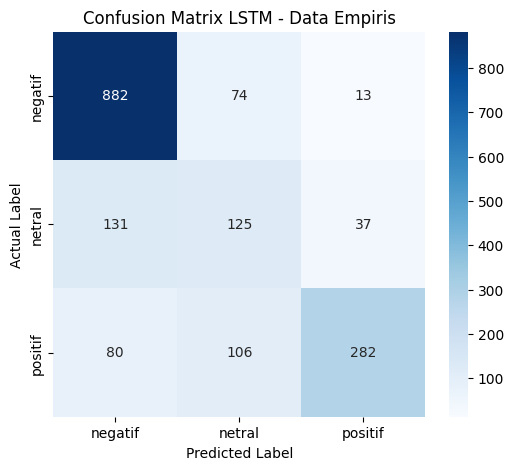

In [ ]:
# =====================================================
# Evaluasi pada test
# =====================================================
y_test_pred = np.argmax(best_model.predict(X_test_pad), axis=1)

label_names = ['negatif','netral','positif']

print("\n=== CLASSIFICATION REPORT LSTM EMPIRIS ===")
print(classification_report(y_test, y_test_pred, target_names=label_names, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix LSTM - Data Empiris")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
# =====================================================
# 1. IMPORT LIBRARY
# =====================================================
import os
import numpy as np
import pandas as pd
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

In [ ]:
# =====================================================
# 2. SET GLOBAL SEED (deterministic)
# =====================================================
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.keras.utils.set_random_seed(seed)

In [ ]:
# =====================================================
# 3. LOAD DATA
# =====================================================
data_new = pd.read_csv("data_preprocessed_with_emoticon.csv")
X = data_new['clean_text_lstm']
y = data_new['label']

train_idx, test_idx = train_test_split(
    data_new.index, test_size=0.2, stratify=y, random_state=seed
)
X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

# Split train → train_final + val
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=seed
)


In [ ]:
# =====================================================
# 4. TOKENIZER & PADDING
# =====================================================
max_words = 10000
max_len   = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_final)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train_final),
                            maxlen=max_len, padding='post')
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val),
                            maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                            maxlen=max_len, padding='post')

In [ ]:
# =====================================================
# 5. GRID SEARCH PARAMETER
# =====================================================
param_grid = [
    {"batch_size":16, "dropout":0.2, "learning_rate":5e-5, "units":32},
    {"batch_size":16, "dropout":0.2, "learning_rate":1e-4, "units":64},
    {"batch_size":16, "dropout":0.3, "learning_rate":1e-4, "units":64},
    {"batch_size":16, "dropout":0.3, "learning_rate":2e-4, "units":64},
    {"batch_size":32, "dropout":0.2, "learning_rate":1e-4, "units":64},
    {"batch_size":32, "dropout":0.3, "learning_rate":1e-4, "units":64},
]

# Hitung class weight dari train_final
classes = np.unique(y_train_final)
cw = compute_class_weight('balanced', classes=classes, y=y_train_final)
cw_dict = dict(enumerate(cw))
print("Class weight:", cw_dict)

best_f1 = -1
best_model = None
best_params = None

for i, params in enumerate(param_grid):
    print(f"\n====== Percobaan ke-{i+1} ======")
    K.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        LSTM(params["units"]),
        Dropout(params["dropout"]),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')
    ])

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=Adam(learning_rate=params["learning_rate"]),
                  metrics=['accuracy'])

    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    model.fit(X_train_pad, y_train_final,
              validation_data=(X_val_pad, y_val),
              epochs=20,
              batch_size=params["batch_size"],
              callbacks=[es],
              class_weight=cw_dict,
              verbose=1)

    y_val_pred = np.argmax(model.predict(X_val_pad), axis=1)
    _, _, f1_macro, _ = precision_recall_fscore_support(y_val, y_val_pred,
                                                        average='macro', zero_division=0)
    print(f"Macro F1 val: {f1_macro:.4f}")

    if f1_macro > best_f1:
        best_f1 = f1_macro
        best_params = params
        best_model = model

print("\n====== HYPERPARAMETER TERBAIK ======")
print(best_params)
print("Best validation Macro F1:", best_f1)

Class weight: {0: np.float64(0.5953337158156435), 1: np.float64(1.9671406003159557), 2: np.float64(1.2316518298714145)}

====== Percobaan ke-1 ======
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3747 - loss: 1.0991 - val_accuracy: 0.5578 - val_loss: 1.0952
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3938 - loss: 1.0989 - val_accuracy: 0.5607 - val_loss: 1.0936
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4568 - loss: 1.0986 - val_accuracy: 0.5636 - val_loss: 1.0942
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4070 - loss: 1.0984 - val_accuracy: 0.5101 - val_loss: 1.0966
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4218 - loss: 1.0965 - val_accuracy: 0.6257 - val_loss: 1.0725
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6951 - loss: 0.8961 - val_accuracy: 0.7081 - val_loss: 0.8143
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7302 - loss: 0.7845 - val_accuracy: 0.7023 - val_loss: 0.8007
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7551 - loss: 0.7267 - val_accuracy: 0.6965 - val

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.2870 - loss: 1.0990 - val_accuracy: 0.2673 - val_loss: 1.0977
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3426 - loss: 1.0989 - val_accuracy: 0.5592 - val_loss: 1.0968
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3577 - loss: 1.0985 - val_accuracy: 0.3396 - val_loss: 1.0969
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6428 - loss: 0.9253 - val_accuracy: 0.7182 - val_loss: 0.7138
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7523 - loss: 0.7071 - val_accuracy: 0.7095 - val_loss: 0.7071
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8015 - loss: 0.5818 - val_accuracy: 0.7095 - val_loss: 0.7313
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8429 - loss: 0.4999 - val_accuracy: 0.7110 - val_loss: 0.8051
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8720 - loss: 0.4413 - val_accuracy: 0.7240 - val_

...

390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3310 - loss: 1.0995 - val_accuracy: 0.5607 - val_loss: 1.0908
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3672 - loss: 1.0990 - val_accuracy: 0.2240 - val_loss: 1.0998
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5323 - loss: 0.9818 - val_accuracy: 0.6546 - val_loss: 0.7510
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6746 - loss: 0.7932 - val_accuracy: 0.7240 - val_loss: 0.7029
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7244 - loss: 0.7063 - val_accuracy: 0.7139 - val_loss: 0.7754
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7396 - loss: 0.6582 - val_accuracy: 0.6199 - val_loss: 0.8138
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8082 - loss: 0.5807 - val_accuracy: 0.7168 - val_loss: 0.8173
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Macro F1 val: 0.5145

====== Percobaan ke-5 ======
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2886 - loss: 1.0989 - val_accuracy: 0.5607 - val_loss: 1.0933
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3619 - loss: 1.0989 - val_accuracy: 0.5607 - val_loss: 1.0949
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3188 - loss: 1.0987 - val_accuracy: 0.5607 - val_loss: 1.0943
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3587 - loss: 1.0983 - val_accuracy: 0.5607 - val_loss: 1.0922
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5249 - loss: 1.0067 - val_accuracy: 0.7038 - val_loss: 0.7665
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7268 - loss: 0.8132 - val_accuracy: 0.7254 - val_loss: 0.7019
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7886 - loss: 0.7033 - val_accuracy: 0.7095 - val_loss: 0.6784
Epoch 8/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8187 - loss: 0.5910 - val_accuracy: 0.7009 - val

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2973 - loss: 1.0990 - val_accuracy: 0.5607 - val_loss: 1.0926
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3347 - loss: 1.0992 - val_accuracy: 0.5607 - val_loss: 1.0918
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3607 - loss: 1.0988 - val_accuracy: 0.5607 - val_loss: 1.0917
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3434 - loss: 1.0982 - val_accuracy: 0.5592 - val_loss: 1.0934
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4208 - loss: 1.0561 - val_accuracy: 0.7038 - val_loss: 0.7895
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7303 - loss: 0.8057 - val_accuracy: 0.6965 - val_loss: 0.7074
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7836 - loss: 0.6364 - val_accuracy: 0.7355 - val_loss: 0.6988
Epoch 8/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8363 - loss: 0.5415 - val_accuracy: 0.6965 - val

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.83      0.87      0.85       969
      netral       0.45      0.55      0.49       293
     positif       0.80      0.61      0.70       468

    accuracy                           0.75      1730
   macro avg       0.70      0.68      0.68      1730
weighted avg       0.76      0.75      0.75      1730



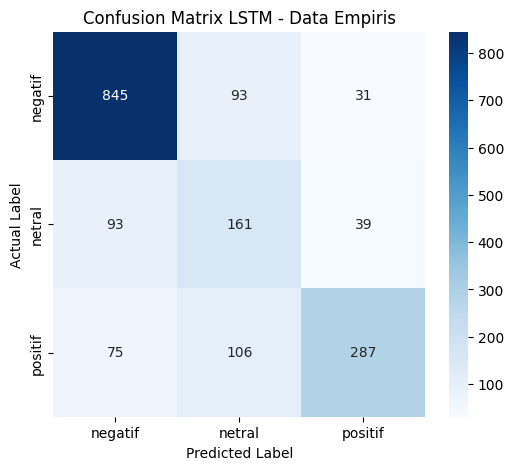

In [ ]:
# =====================================================
# 6. EVALUASI PADA TEST SET
# =====================================================
y_test_pred = np.argmax(best_model.predict(X_test_pad), axis=1)
label_names = ['negatif','netral','positif']

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_test_pred, target_names=label_names, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix LSTM - Data Empiris")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
# =====================================================
# 1. Loop grid search per teknik penanganan
# =====================================================

penanganan_list = ['tanpa', 'class_weight', 'oversampling', 'undersampling', 'smote']

all_results = []

for pen in penanganan_list:
    print(f"\n{'='*60}\nGrid search untuk penanganan: {pen}\n{'='*60}")

    # Tentukan X_train dan y_train sesuai teknik
    X_tr, y_tr = X_train_pad.copy(), y_train_final.copy()

    if pen == 'class_weight':
        cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
        cw_dict = dict(enumerate(cw))
    elif pen == 'oversampling':
        from imblearn.over_sampling import RandomOverSampler
        ros = RandomOverSampler(random_state=seed)
        X_tr, y_tr = ros.fit_resample(X_tr, y_tr)
    elif pen == 'undersampling':
        from imblearn.under_sampling import RandomUnderSampler
        rus = RandomUnderSampler(random_state=seed)
        X_tr, y_tr = rus.fit_resample(X_tr, y_tr)
    elif pen == 'smote':
        from imblearn.over_sampling import SMOTE
        smote = SMOTE(random_state=seed)
        X_tr, y_tr = smote.fit_resample(X_tr, y_tr)

    # =====================================================
    # 2. Grid search
    # =====================================================
    best_f1 = -1
    best_params = None
    best_model = None

    for i, params in enumerate(param_grid):
        K.clear_session()
        tf.random.set_seed(seed)
        np.random.seed(seed)
        random.seed(seed)

        model = Sequential([
            Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
            LSTM(params["units"]),
            Dropout(params["dropout"]),
            Dense(64, activation='relu'),
            Dense(3, activation='softmax')
        ])
        model.compile(loss='sparse_categorical_crossentropy',
                      optimizer=Adam(learning_rate=params["learning_rate"]),
                      metrics=['accuracy'])
        es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

        model.fit(X_tr, y_tr,
                  validation_data=(X_val_pad, y_val),
                  epochs=20,
                  batch_size=params["batch_size"],
                  callbacks=[es],
                  class_weight=(cw_dict if pen=='class_weight' else None),
                  verbose=0)

        y_val_pred = np.argmax(model.predict(X_val_pad), axis=1)
        _, _, f1_macro, _ = precision_recall_fscore_support(y_val, y_val_pred,
                                                            average='macro', zero_division=0)
        if f1_macro > best_f1:
            best_f1 = f1_macro
            best_params = params
            best_model = model

    print(f"Best params ({pen}): {best_params}")
    print(f"Best Macro F1 val ({pen}): {best_f1:.4f}")

    # =====================================================
    # 3. Evaluasi test set
    # =====================================================
    y_test_pred = np.argmax(best_model.predict(X_test_pad), axis=1)
    report = classification_report(y_test, y_test_pred, target_names=['negatif','netral','positif'], zero_division=0)
    print(report)

    all_results.append({
        'penanganan': pen,
        'best_params': best_params,
        'f1_val': best_f1
    })


Grid search untuk penanganan: tanpa


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


...

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Best params (smote): {'batch_size': 16, 'dropout': 0.3, 'learning_rate': 0.0001, 'units': 64}
Best Macro F1 val (smote): 0.5577
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

     negatif       0.84      0.66      0.74       969
      netral       0.23      0.34      0.27       293
     positif       0.62      0.69      0.65       468

    accuracy                           0.61      1730
   macro avg       0.56      0.56      0.55      1730
weighted avg       0.68      0.61      0.64      1730



In [ ]:
# =====================================================
# LSTM GRID SEARCH — CLASS WEIGHT
# =====================================================
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

In [ ]:
# Set seed
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
# =====================================================
# DATA
# =====================================================
data_new = pd.read_csv("data_preprocessed_with_emoticon.csv")
X = data_new['clean_text_lstm']
y = data_new['label']

from sklearn.model_selection import train_test_split
train_idx, test_idx = train_test_split(
    data_new.index, test_size=0.2, stratify=y, random_state=seed
)
X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=seed
)

In [ ]:
# =====================================================
# TOKENIZER & PADDING
# =====================================================
max_words = 10000
max_len = 50
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_final)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train_final), maxlen=max_len, padding='post')
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len, padding='post')


In [ ]:
# =====================================================
# GRID SEARCH PARAMETERS
# =====================================================
param_grid = [
    {"batch_size":16, "dropout":0.2, "learning_rate":5e-5, "units":32},
    {"batch_size":16, "dropout":0.2, "learning_rate":1e-4, "units":64},
    {"batch_size":16, "dropout":0.3, "learning_rate":1e-4, "units":64},
    {"batch_size":16, "dropout":0.3, "learning_rate":2e-4, "units":64},
    {"batch_size":32, "dropout":0.2, "learning_rate":1e-4, "units":64},
    {"batch_size":32, "dropout":0.3, "learning_rate":1e-4, "units":64},
]

# Hitung class weight
classes = np.unique(y_train_final)
cw_values = compute_class_weight('balanced', classes=classes, y=y_train_final)
cw_dict = dict(enumerate(cw_values))
print("Class Weight:", cw_dict)

Class Weight: {0: np.float64(0.5953337158156435), 1: np.float64(1.9671406003159557), 2: np.float64(1.2316518298714145)}


In [ ]:
# =====================================================
# BUILD LSTM FUNCTION
# =====================================================
def build_lstm(units, dropout, learning_rate, max_words, max_len):
    K.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        LSTM(units),
        Dropout(dropout),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=Adam(learning_rate=learning_rate),
                  metrics=['accuracy'])
    return model

In [ ]:
# =====================================================
# GRID SEARCH LOOP — CLASS WEIGHT
# =====================================================
results_cw = []

for i, params in enumerate(param_grid, 1):
    print(f"\n--- Percobaan {i} ---")
    print(params)

    model = build_lstm(params['units'], params['dropout'], params['learning_rate'], max_words, max_len)
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    model.fit(X_train_pad, y_train_final,
              validation_data=(X_val_pad, y_val),
              epochs=20,
              batch_size=params['batch_size'],
              callbacks=[es],
              class_weight=cw_dict,
              verbose=1)

    # Prediksi validation
    y_val_pred = np.argmax(model.predict(X_val_pad), axis=1)
    acc = accuracy_score(y_val, y_val_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='macro', zero_division=0)
    print(f"Macro F1 val: {f1:.4f} | Accuracy val: {acc:.4f}")

    results_cw.append({
        'percobaan': i,
        'batch_size': params['batch_size'],
        'dropout': params['dropout'],
        'learning_rate': params['learning_rate'],
        'units': params['units'],
        'macro_f1_val': f1,
        'accuracy_val': acc
    })


--- Percobaan 1 ---
{'batch_size': 16, 'dropout': 0.2, 'learning_rate': 5e-05, 'units': 32}
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3747 - loss: 1.0991 - val_accuracy: 0.5578 - val_loss: 1.0952
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3938 - loss: 1.0989 - val_accuracy: 0.5607 - val_loss: 1.0936
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4568 - loss: 1.0986 - val_accuracy: 0.5636 - val_loss: 1.0942
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4070 - loss: 1.0984 - val_accuracy: 0.5101 - val_loss: 1.0966
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4218 - loss: 1.0965 - val_accuracy: 0.6257 - val_loss: 1.0725
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6951 - loss: 0.8961 - val_accuracy: 0.7081 - val_loss: 0.8143
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7302 - loss: 0.7845 - val_accuracy: 0.7023 - val_loss: 0.8007
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7551 - loss: 0.7267 - val_accuracy: 0.6965 - val

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2870 - loss: 1.0990 - val_accuracy: 0.2673 - val_loss: 1.0977
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3426 - loss: 1.0989 - val_accuracy: 0.5592 - val_loss: 1.0968
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3577 - loss: 1.0985 - val_accuracy: 0.3396 - val_loss: 1.0969
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6428 - loss: 0.9253 - val_accuracy: 0.7182 - val_loss: 0.7138
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7523 - loss: 0.7071 - val_accuracy: 0.7095 - val_loss: 0.7071
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8015 - loss: 0.5818 - val_accuracy: 0.7095 - val_loss: 0.7313
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8429 - loss: 0.4999 - val_accuracy: 0.7110 - val_loss: 0.8051
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8720 - loss: 0.4413 - val_accuracy: 0.7240 - val_

...

390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3310 - loss: 1.0995 - val_accuracy: 0.5607 - val_loss: 1.0908
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3672 - loss: 1.0990 - val_accuracy: 0.2240 - val_loss: 1.0998
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5323 - loss: 0.9818 - val_accuracy: 0.6546 - val_loss: 0.7510
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6746 - loss: 0.7932 - val_accuracy: 0.7240 - val_loss: 0.7029
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7244 - loss: 0.7063 - val_accuracy: 0.7139 - val_loss: 0.7754
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7396 - loss: 0.6582 - val_accuracy: 0.6199 - val_loss: 0.8138
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8082 - loss: 0.5807 - val_accuracy: 0.7168 - val_loss: 0.8173
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Macro F1 val: 0.5145 | Accuracy val: 0.7240

--- Percobaan 5 ---
{'batch_siz

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2886 - loss: 1.0989 - val_accuracy: 0.5607 - val_loss: 1.0933
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3619 - loss: 1.0989 - val_accuracy: 0.5607 - val_loss: 1.0949
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3188 - loss: 1.0987 - val_accuracy: 0.5607 - val_loss: 1.0943
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3587 - loss: 1.0983 - val_accuracy: 0.5607 - val_loss: 1.0922
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5249 - loss: 1.0067 - val_accuracy: 0.7038 - val_loss: 0.7665
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7268 - loss: 0.8132 - val_accuracy: 0.7254 - val_loss: 0.7019
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7886 - loss: 0.7033 - val_accuracy: 0.7095 - val_loss: 0.6784
Epoch 8/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8187 - loss: 0.5910 - val_accuracy: 0.7009 - val

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2973 - loss: 1.0990 - val_accuracy: 0.5607 - val_loss: 1.0926
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3347 - loss: 1.0992 - val_accuracy: 0.5607 - val_loss: 1.0918
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3607 - loss: 1.0988 - val_accuracy: 0.5607 - val_loss: 1.0917
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3434 - loss: 1.0982 - val_accuracy: 0.5592 - val_loss: 1.0934
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4208 - loss: 1.0561 - val_accuracy: 0.7038 - val_loss: 0.7895
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7303 - loss: 0.8057 - val_accuracy: 0.6965 - val_loss: 0.7074
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7836 - loss: 0.6364 - val_accuracy: 0.7355 - val_loss: 0.6988
Epoch 8/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8363 - loss: 0.5415 - val_accuracy: 0.6965 - val

In [ ]:
# =====================================================
# Simpan hasil grid search Class Weight
# =====================================================
df_cw_results = pd.DataFrame(results_cw)
print("\n=== Semua Hasil Grid Search Class Weight ===")
print(df_cw_results)
df_cw_results.to_csv("grid_search_class_weight.csv", index=False)
print("Hasil grid search Class Weight disimpan di 'grid_search_class_weight.csv'")


=== Semua Hasil Grid Search Class Weight ===
   percobaan  batch_size  dropout  learning_rate  units  macro_f1_val  \
0          1          16      0.2        0.00005     32      0.588934   
1          2          16      0.2        0.00010     64      0.639242   
2          3          16      0.3        0.00010     64      0.614173   
3          4          16      0.3        0.00020     64      0.514530   
4          5          32      0.2        0.00010     64      0.631372   
5          6          32      0.3        0.00010     64      0.666459   

   accuracy_val  
0      0.674855  
1      0.709538  
2      0.713873  
3      0.723988  
4      0.709538  
5      0.735549  
Hasil grid search Class Weight disimpan di 'grid_search_class_weight.csv'


In [ ]:
# =====================================================
# LSTM GRID SEARCH — RANDOM OVERSAMPLING
# =====================================================
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=seed)
X_ros, y_ros = ros.fit_resample(X_train_pad, y_train_final)
print("Distribusi setelah Random Oversampling:")
print(pd.Series(y_ros).value_counts().sort_index())

results_ros = []

for i, params in enumerate(param_grid, 1):
    print(f"\n--- Random Oversampling | Percobaan {i} ---")
    print(params)

    model = build_lstm(params['units'], params['dropout'], params['learning_rate'], max_words, max_len)
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    model.fit(X_ros, y_ros,
              validation_data=(X_val_pad, y_val),
              epochs=20,
              batch_size=params['batch_size'],
              callbacks=[es],
              verbose=1)

    y_val_pred = np.argmax(model.predict(X_val_pad), axis=1)
    acc = accuracy_score(y_val, y_val_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='macro', zero_division=0)
    print(f"Macro F1 val: {f1:.4f} | Accuracy val: {acc:.4f}")

    results_ros.append({
        'percobaan': i,
        'batch_size': params['batch_size'],
        'dropout': params['dropout'],
        'learning_rate': params['learning_rate'],
        'units': params['units'],
        'macro_f1_val': f1,
        'accuracy_val': acc
    })

# =====================================================
# Simpan hasil grid search Random Oversampling
# =====================================================
df_ros_results = pd.DataFrame(results_ros)
print("\n=== Semua Hasil Grid Search Random Oversampling ===")
print(df_ros_results)
df_ros_results.to_csv("grid_search_random_oversampling.csv", index=False)
print("Hasil grid search Random Oversampling disimpan di 'grid_search_random_oversampling.csv'")

Distribusi setelah Random Oversampling:
label
0    3486
1    3486
2    3486
Name: count, dtype: int64

--- Random Oversampling | Percobaan 1 ---
{'batch_size': 16, 'dropout': 0.2, 'learning_rate': 5e-05, 'units': 32}
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


654/654 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3371 - loss: 1.0987 - val_accuracy: 0.5621 - val_loss: 1.0932
Epoch 2/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3459 - loss: 1.0984 - val_accuracy: 0.5665 - val_loss: 1.0949
Epoch 3/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4793 - loss: 0.9769 - val_accuracy: 0.6387 - val_loss: 0.8778
Epoch 4/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5970 - loss: 0.7612 - val_accuracy: 0.3685 - val_loss: 0.8848
Epoch 5/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6177 - loss: 0.6975 - val_accuracy: 0.3873 - val_loss: 0.9041
Epoch 6/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6362 - loss: 0.6519 - val_accuracy: 0.3743 - val_loss: 0.9351
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Macro F1 val: 0.5383 | Accuracy val: 0.6387

--- Random Oversampling | Percobaan 2 ---
{'batch_size': 16, 'dropout': 0.2, 'learning_rate': 0.0001, 'units': 64}
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


654/654 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3399 - loss: 1.0986 - val_accuracy: 0.5592 - val_loss: 1.0931
Epoch 2/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4115 - loss: 1.0497 - val_accuracy: 0.6749 - val_loss: 0.8159
Epoch 3/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7600 - loss: 0.6357 - val_accuracy: 0.7327 - val_loss: 0.7338
Epoch 4/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8749 - loss: 0.4015 - val_accuracy: 0.7384 - val_loss: 0.7892
Epoch 5/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9136 - loss: 0.3048 - val_accuracy: 0.7283 - val_loss: 0.8361
Epoch 6/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9342 - loss: 0.2443 - val_accuracy: 0.7269 - val_loss: 0.9234
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Macro F1 val: 0.6516 | Accuracy val: 0.7327

--- Random Oversampling | Percobaan 3 ---
{'batch_size': 16, 'dropout': 0.3, 'learning_rate': 0.0001, 'units': 64}
Epoch 1/20


...

654/654 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3392 - loss: 1.0986 - val_accuracy: 0.5578 - val_loss: 1.0946
Epoch 2/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5527 - loss: 0.8377 - val_accuracy: 0.5462 - val_loss: 0.8840
Epoch 3/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6451 - loss: 0.6599 - val_accuracy: 0.6315 - val_loss: 0.8849
Epoch 4/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8329 - loss: 0.4607 - val_accuracy: 0.7095 - val_loss: 0.9000
Epoch 5/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9105 - loss: 0.3049 - val_accuracy: 0.7211 - val_loss: 0.8753
Epoch 6/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9361 - loss: 0.2300 - val_accuracy: 0.7095 - val_loss: 0.9432
Epoch 7/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9502 - loss: 0.1924 - val_accuracy: 0.7038 - val_loss: 1.0512
Epoch 8/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9556 - loss: 0.1730 - val_accuracy: 0.7081 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


327/327 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3360 - loss: 1.0988 - val_accuracy: 0.5621 - val_loss: 1.0940
Epoch 2/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3437 - loss: 1.0984 - val_accuracy: 0.5607 - val_loss: 1.0907
Epoch 3/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4665 - loss: 1.0018 - val_accuracy: 0.6908 - val_loss: 0.7889
Epoch 4/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7782 - loss: 0.6045 - val_accuracy: 0.7225 - val_loss: 0.7284
Epoch 5/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8747 - loss: 0.4115 - val_accuracy: 0.7225 - val_loss: 0.8186
Epoch 6/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9099 - loss: 0.3244 - val_accuracy: 0.7283 - val_loss: 0.8714
Epoch 7/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9314 - loss: 0.2661 - val_accuracy: 0.7529 - val_loss: 0.8411
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Macro F1 val: 0.6654 | Accuracy val: 0.7225

--- Random Oversampling | Perco

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


327/327 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3367 - loss: 1.0988 - val_accuracy: 0.5592 - val_loss: 1.0885
Epoch 2/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3420 - loss: 1.0985 - val_accuracy: 0.5607 - val_loss: 1.0868
Epoch 3/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4662 - loss: 0.9965 - val_accuracy: 0.7009 - val_loss: 0.7697
Epoch 4/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7577 - loss: 0.6394 - val_accuracy: 0.6951 - val_loss: 0.7912
Epoch 5/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8528 - loss: 0.4684 - val_accuracy: 0.6792 - val_loss: 0.9662
Epoch 6/20
327/327 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8932 - loss: 0.3861 - val_accuracy: 0.6922 - val_loss: 0.8975
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Macro F1 val: 0.5721 | Accuracy val: 0.7009

=== Semua Hasil Grid Search Random Oversampling ===
   percobaan  batch_size  dropout  learning_rate  units  macro_f1_val  \
0          1          16      0.2 

lstm dengan 108 percobaan

In [ ]:
# =====================================================
# IMPORT
# =====================================================
import itertools
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

In [ ]:
# =====================================================
# SET SEED
# =====================================================
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
# =====================================================
# LOAD DATA
# =====================================================
data_new = pd.read_csv("data_preprocessed_with_emoticon.csv")
X = data_new['clean_text_lstm']
y = data_new['label']

train_idx, test_idx = train_test_split(
    data_new.index, test_size=0.2, stratify=y, random_state=seed
)
X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=seed
)


In [ ]:
# =====================================================
# TOKENIZER & PADDING
# =====================================================
max_words = 10000
max_len = 50
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_final)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train_final), maxlen=max_len, padding='post')
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len, padding='post')


In [ ]:
# =====================================================
# CLASS WEIGHT
# =====================================================
classes = np.unique(y_train_final)
cw_values = compute_class_weight('balanced', classes=classes, y=y_train_final)
cw_dict = dict(enumerate(cw_values))
print("Class Weight:", cw_dict)


Class Weight: {0: np.float64(0.5953337158156435), 1: np.float64(1.9671406003159557), 2: np.float64(1.2316518298714145)}


In [ ]:
# =====================================================
# GRID SEARCH PARAMETERS
# =====================================================
param_grid = {
    'units': [32, 64, 128],
    'dropout': [0.2, 0.3, 0.4, 0.5],
    'learning_rate': [3e-4, 1e-4, 5e-5],
    'batch_size': [16, 32, 64]
}

label_names = ['negatif','netral','positif']

In [ ]:
# =====================================================
# BUILD MODEL FUNCTION
# =====================================================
def build_lstm(units, dropout, learning_rate):
    K.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        LSTM(units),
        Dropout(dropout),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
# =====================================================
# GRID SEARCH LOOP
# =====================================================
results = []

# Buat semua kombinasi parameter
all_combinations = list(itertools.product(
    param_grid['units'],
    param_grid['dropout'],
    param_grid['learning_rate'],
    param_grid['batch_size']
))

for i, (units, dropout, lr, batch) in enumerate(all_combinations, 1):
    print(f"\nPercobaan {i}/{len(all_combinations)}: units={units}, dropout={dropout}, lr={lr}, batch_size={batch}")

    model = build_lstm(units, dropout, lr)
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    model.fit(
        X_train_pad, y_train_final,
        validation_data=(X_val_pad, y_val),
        epochs=4,
        batch_size=batch,
        callbacks=[es],
        class_weight=cw_dict,
        verbose=1
    )

    y_val_pred = np.argmax(model.predict(X_val_pad), axis=1)
    acc = accuracy_score(y_val, y_val_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='macro', zero_division=0)
    print(f"Macro F1 val: {f1:.4f} | Accuracy val: {acc:.4f}")

    results.append({
        'units': units,
        'dropout': dropout,
        'learning_rate': lr,
        'batch_size': batch,
        'macro_f1_val': f1,
        'accuracy_val': acc
    })



Percobaan 1/108: units=32, dropout=0.2, lr=0.0003, batch_size=16


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/4
390/390 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3338 - loss: 1.0995 - val_accuracy: 0.1777 - val_loss: 1.0975
Epoch 2/4
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3946 - loss: 1.0747 - val_accuracy: 0.6864 - val_loss: 0.8634
Epoch 3/4
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6910 - loss: 0.8333 - val_accuracy: 0.6517 - val_loss: 0.7667
Epoch 4/4
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7642 - loss: 0.6399 - val_accuracy: 0.7066 - val_loss: 0.6954
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Macro F1 val: 0.6700 | Accuracy val: 0.7066

Percobaan 2/108: units=32, dropout=0.2, lr=0.0003, batch_size=32
Epoch 1/4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3461 - loss: 1.0994 - val_accuracy: 0.5621 - val_loss: 1.0961
Epoch 2/4
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3225 - loss: 1.0989 - val_accuracy: 0.2038 - val_loss: 1.0996
Epoch 3/4
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4065 - loss: 1.0605 - val_accuracy: 0.6965 - val_loss: 0.8464
Epoch 4/4
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7186 - loss: 0.8484 - val_accuracy: 0.6879 - val_loss: 0.7108
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Macro F1 val: 0.6176 | Accuracy val: 0.6879

Percobaan 3/108: units=32, dropout=0.2, lr=0.0003, batch_size=64
Epoch 1/4


...

390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.2642 - loss: 1.0986 - val_accuracy: 0.5592 - val_loss: 1.0964
Epoch 2/4
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3386 - loss: 1.0984 - val_accuracy: 0.5592 - val_loss: 1.0939
Epoch 3/4
390/390 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3542 - loss: 1.0983 - val_accuracy: 0.5592 - val_loss: 1.0903
Epoch 4/4
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5108 - loss: 1.0284 - val_accuracy: 0.7110 - val_loss: 0.7526
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Macro F1 val: 0.5361 | Accuracy val: 0.7110

Percobaan 107/108: units=128, dropout=0.5, lr=5e-05, batch_size=32
Epoch 1/4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3076 - loss: 1.0989 - val_accuracy: 0.5578 - val_loss: 1.0927
Epoch 2/4
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3795 - loss: 1.0988 - val_accuracy: 0.5592 - val_loss: 1.0949
Epoch 3/4
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3538 - loss: 1.0987 - val_accuracy: 0.5592 - val_loss: 1.0965
Epoch 4/4
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3572 - loss: 1.0981 - val_accuracy: 0.4740 - val_loss: 1.0954
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Macro F1 val: 0.2387 | Accuracy val: 0.5578

Percobaan 108/108: units=128, dropout=0.5, lr=5e-05, batch_size=64
Epoch 1/4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.2859 - loss: 1.0989 - val_accuracy: 0.3396 - val_loss: 1.0980
Epoch 2/4
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3185 - loss: 1.0986 - val_accuracy: 0.2919 - val_loss: 1.0980
Epoch 3/4
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3278 - loss: 1.0987 - val_accuracy: 0.5592 - val_loss: 1.0963
Epoch 4/4
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3604 - loss: 1.0986 - val_accuracy: 0.5592 - val_loss: 1.0956
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Macro F1 val: 0.2391 | Accuracy val: 0.5592


In [ ]:
# =====================================================
# SIMPAN HASIL GRID SEARCH
# =====================================================
df_results = pd.DataFrame(results)
df_results.to_csv("grid_search_all_combinations.csv", index=False)
print("Hasil grid search disimpan di 'grid_search_all_combinations.csv'")

Hasil grid search disimpan di 'grid_search_all_combinations.csv'


In [ ]:
# =====================================================
# 1. IMPORT LIBRARY
# =====================================================
import numpy as np
import pandas as pd
import random
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 25.9 MB/s eta 0:00:00


In [ ]:
# =====================================================
# 2. SET SEED
# =====================================================
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
# =====================================================
# 3. LOAD DATA
# =====================================================
data_new = pd.read_csv("data_preprocessed_with_emoticon.csv")

X = data_new['clean_text_lstm']
y = data_new['label']

train_idx, test_idx = train_test_split(
    data_new.index,
    test_size=0.2,
    stratify=y,
    random_state=seed
)

X_train = X.loc[train_idx].reset_index(drop=True)
X_test  = X.loc[test_idx].reset_index(drop=True)
y_train = y.loc[train_idx].reset_index(drop=True)
y_test  = y.loc[test_idx].reset_index(drop=True)

# Split train → train_final + val
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=seed
)

print("Distribusi y_train_final:")
print(y_train_final.value_counts().sort_index())
print("\nDistribusi y_val:")
print(y_val.value_counts().sort_index())
print("\nDistribusi y_test:")
print(y_test.value_counts().sort_index())

Distribusi y_train_final:
label
0    3486
1    1055
2    1685
Name: count, dtype: int64

Distribusi y_val:
label
0    388
1    117
2    187
Name: count, dtype: int64

Distribusi y_test:
label
0    969
1    293
2    468
Name: count, dtype: int64


In [ ]:
# =====================================================
# 4. PARAMETER
# =====================================================
max_words   = 10000
max_len     = 50
label_names = ['negatif', 'netral', 'positif']


In [ ]:
# =====================================================
# 5. TOKENIZER & PADDING
# =====================================================
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_final)

X_tr_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_train_final),
    maxlen=max_len, padding='post', truncating='post'
)
X_val_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_val),
    maxlen=max_len, padding='post', truncating='post'
)
X_te_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=max_len, padding='post', truncating='post'
)

print("\nShape X_tr_pad :", X_tr_pad.shape)
print("Shape X_val_pad:", X_val_pad.shape)
print("Shape X_te_pad :", X_te_pad.shape)



Shape X_tr_pad : (6226, 50)
Shape X_val_pad: (692, 50)
Shape X_te_pad : (1730, 50)


In [ ]:
# =====================================================
# 6. OPTUNA — HYPERPARAMETER TUNING
# =====================================================
def objective(trial):
    K.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    units   = trial.suggest_categorical('units',     [32, 64, 128])
    dropout = trial.suggest_float('dropout', 0.1, 0.5, step=0.1)
    lr      = trial.suggest_float('lr', 1e-5, 5e-4, log=True)
    batch   = trial.suggest_categorical('batch_size', [8, 16, 32])

    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=128,
                        input_length=max_len))
    model.add(LSTM(units))
    model.add(Dropout(dropout))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(3, activation='softmax'))

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=lr),
        metrics=['accuracy']
    )

    es = EarlyStopping(monitor='val_loss', patience=3,
                       restore_best_weights=True)

    model.fit(
        X_tr_pad, y_train_final,
        validation_data=(X_val_pad, y_val),
        epochs=20, batch_size=batch,
        callbacks=[es], verbose=0
    )

    y_val_pred = np.argmax(model.predict(X_val_pad), axis=1)
    _, _, f1, _ = precision_recall_fscore_support(
        y_val, y_val_pred, average='macro', zero_division=0
    )
    return f1

print("\nMenjalankan Optuna (20 trial)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print("\n=== HASIL OPTUNA ===")
print("Best params  :", study.best_params)
print(f"Best macro F1: {study.best_value:.4f}")

# Tampilkan semua trial
df_trials = study.trials_dataframe()
df_trials = df_trials[[
    'number', 'value',
    'params_units', 'params_dropout',
    'params_lr', 'params_batch_size'
]]
df_trials.columns = [
    'trial', 'macro_f1', 'units',
    'dropout', 'lr', 'batch_size'
]
df_trials = df_trials.sort_values('macro_f1', ascending=False)
print("\nSemua hasil trial:")
print(df_trials.to_string(index=False))


Menjalankan Optuna (20 trial)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


...

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

=== HASIL OPTUNA ===
Best params  : {'units': 128, 'dropout': 0.4, 'lr': 0.00044705290824947056, 'batch_size': 8}
Best macro F1: 0.6866

Semua hasil trial:
 trial  macro_f1  units  dropout       lr  batch_size
     0  0.686593    128      0.4 0.000447           8
     4  0.657281     64      0.5 0.000194          16
     3  0.656036     32      0.2 0.000210          16
     8  0.645012     64      0.2 0.000170          16
    11  0.639155    128      0.5 0.000141           8
    13  0.635447    128      0.4 0.000090           8
    19  0.634116     32      0.5 0.000358          32
    10  0.623017    128      0.5 0.000457           8
    17  0.603879    128      0.5 0.000058           8
     6  0.596632     64      0.2 0.000333          32
    16  0.594942    128      0.4 0.000265           8
    12  0.593682    128      0.4 0.000283           8
     7  0.577251     64      0.1 0.000092          16
    18  0.571065     64      0.4 0.000142      

In [ ]:
# 7. TRAINING DENGAN BEST PARAMS
# =====================================================
best = study.best_params
print(f"\nTraining dengan best params: {best}")

K.clear_session()
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

best_model = Sequential()
best_model.add(Embedding(input_dim=max_words, output_dim=128,
                         input_length=max_len))
best_model.add(LSTM(best['units']))
best_model.add(Dropout(best['dropout']))
best_model.add(Dense(64, activation='relu'))
best_model.add(Dense(3, activation='softmax'))

best_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=best['lr']),
    metrics=['accuracy']
)

es = EarlyStopping(monitor='val_loss', patience=3,
                   restore_best_weights=True)

history = best_model.fit(
    X_tr_pad, y_train_final,
    validation_data=(X_val_pad, y_val),
    epochs=20, batch_size=best['batch_size'],
    callbacks=[es], verbose=1
)


Training dengan best params: {'units': 128, 'dropout': 0.1, 'lr': 0.000135162491570549, 'batch_size': 16}
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5585 - loss: 0.9887 - val_accuracy: 0.5607 - val_loss: 0.9787
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6068 - loss: 0.8985 - val_accuracy: 0.7095 - val_loss: 0.7711
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7499 - loss: 0.6283 - val_accuracy: 0.7052 - val_loss: 0.7172
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8004 - loss: 0.5122 - val_accuracy: 0.6936 - val_loss: 0.7523
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8412 - loss: 0.4292 - val_accuracy: 0.7486 - val_loss: 0.7081
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8818 - loss: 0.3523 - val_accuracy: 0.7327 - val_loss: 0.7888
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9048 - loss: 0.3077 - val_accuracy: 0.7254 - val_loss: 0.8068
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9240 - loss: 0.2616 - val_accuracy: 0.7168 - val

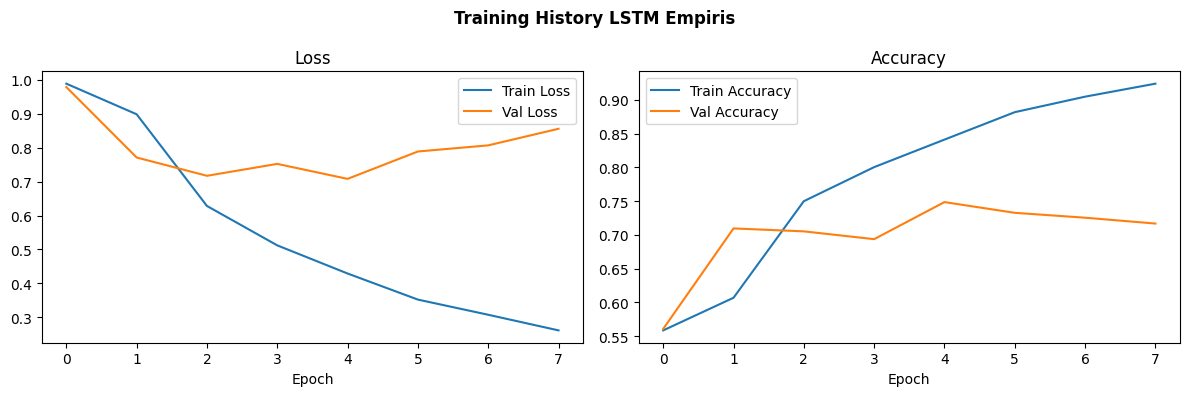

In [ ]:
# =====================================================
# 8. PLOT TRAINING HISTORY
# =====================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['accuracy'],     label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.suptitle('Training History LSTM Empiris', fontweight='bold')
plt.tight_layout()
plt.savefig('history_lstm_empiris.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

=== CLASSIFICATION REPORT — LSTM EMPIRIS ===
              precision    recall  f1-score   support

     negatif       0.80      0.90      0.85       969
      netral       0.41      0.40      0.41       293
     positif       0.80      0.61      0.69       468

    accuracy                           0.74      1730
   macro avg       0.67      0.64      0.65      1730
weighted avg       0.73      0.74      0.73      1730



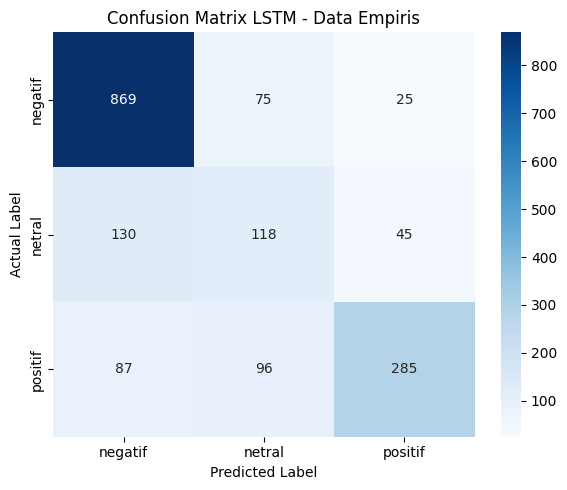

In [ ]:
# =====================================================
# 9. EVALUASI PADA DATA TEST
# =====================================================
y_pred = np.argmax(best_model.predict(X_te_pad), axis=1)

print("\n=== CLASSIFICATION REPORT — LSTM EMPIRIS ===")
print(classification_report(
    y_test, y_pred,
    target_names=label_names,
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title("Confusion Matrix LSTM - Data Empiris")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig('cm_lstm_empiris.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# =====================================================
# 10. RINGKASAN METRIK
# =====================================================
p, r, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='macro', zero_division=0
)
acc = accuracy_score(y_test, y_pred)

hasil = pd.DataFrame({
    'Model'          : ['LSTM'],
    'Data'           : ['Empiris'],
    'Penanganan'     : ['Tanpa Penanganan'],
    'Accuracy'       : [round(acc, 4)],
    'Precision Macro': [round(p, 4)],
    'Recall Macro'   : [round(r, 4)],
    'Macro F1'       : [round(f1, 4)],
    'Best Params'    : [str(best)]
})

print("\n=== RINGKASAN HASIL ===")
print(hasil.to_string(index=False))

hasil.to_csv('hasil_lstm_empiris_tanpa_penanganan.csv', index=False)
print("\nHasil disimpan!")



=== RINGKASAN HASIL ===
Model    Data       Penanganan  Accuracy  Precision Macro  Recall Macro  Macro F1                                                                  Best Params
 LSTM Empiris Tanpa Penanganan    0.7353           0.6704        0.6362    0.6479 {'units': 128, 'dropout': 0.1, 'lr': 0.000135162491570549, 'batch_size': 16}

Hasil disimpan!


In [ ]:
# =====================================================
# 11. SIMPAN MODEL, TOKENIZER, BEST PARAMS
# =====================================================
best_model.save('model_lstm_empiris.h5')

with open('tokenizer_lstm.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('best_params_lstm_empiris.pkl', 'wb') as f:
    pickle.dump(best, f)

print("Model, tokenizer, dan best params berhasil disimpan!")

Model, tokenizer, dan best params berhasil disimpan!


In [ ]:
# =====================================================
# IMPORT LIBRARY
# =====================================================
import itertools
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# =====================================================
# SET SEED
# =====================================================
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
# =====================================================
# LOAD DATA
# =====================================================
data_new = pd.read_csv("data_preprocessed_with_emoticon.csv")
X = data_new['clean_text_lstm']
y = data_new['label']

# Split data train-test
train_idx, test_idx = train_test_split(
    data_new.index, test_size=0.2, stratify=y, random_state=seed
)
X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

# Split train → train_final + validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=seed
)

In [ ]:
# =====================================================
# TOKENIZER & PADDING
# =====================================================
max_words = 10000
max_len = 50
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_final)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train_final), maxlen=max_len, padding='post')
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len, padding='post')

In [ ]:
# =====================================================
# HYPERPARAMETER GRID
# =====================================================
param_grid = {
    'units': [32, 64, 128],
    'dropout': [0.2, 0.3, 0.4, 0.5],
    'learning_rate': [3e-4, 1e-4, 5e-5],
    'batch_size': [16, 32, 64]
}

label_names = ['negatif','netral','positif']


In [ ]:
# =====================================================
# BUILD MODEL FUNCTION
# =====================================================
def build_lstm(units, dropout, learning_rate):
    K.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        LSTM(units),
        Dropout(dropout),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
# =====================================================
# GRID SEARCH LOOP
# =====================================================
results = []

# Semua kombinasi hyperparameter
all_combinations = list(itertools.product(
    param_grid['units'],
    param_grid['dropout'],
    param_grid['learning_rate'],
    param_grid['batch_size']
))

for i, (units, dropout, lr, batch) in enumerate(all_combinations, 1):
    print(f"\nPercobaan {i}/{len(all_combinations)}: units={units}, dropout={dropout}, lr={lr}, batch_size={batch}")

    model = build_lstm(units, dropout, lr)
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    model.fit(
        X_train_pad, y_train_final,
        validation_data=(X_val_pad, y_val),
        epochs=4,
        batch_size=batch,
        callbacks=[es],
        verbose=1
    )

    # Evaluasi validation
    y_val_pred = np.argmax(model.predict(X_val_pad), axis=1)
    acc = accuracy_score(y_val, y_val_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='macro', zero_division=0)
    print(f"Macro F1 val: {f1:.4f} | Accuracy val: {acc:.4f}")

    results.append({
        'units': units,
        'dropout': dropout,
        'learning_rate': lr,
        'batch_size': batch,
        'macro_f1_val': f1,
        'accuracy_val': acc
    })


NameError: name 'itertools' is not defined

#BAGIAN 3 — Data Empiris biLSTM


In [ ]:
# =====================================================
# BiLSTM EMPIRIS DENGAN VALIDATION STRATIFIED
# =====================================================

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

# Set seed
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

# Parameter
max_words = 10000
max_len = 50

In [ ]:
print(X_train_lstm.shape)
print(X_test_lstm.shape)
print(y_train.shape)
print(y_test.shape)

print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())

(6918,)
(1730,)
(6918,)
(1730,)
label
0.0    3874
1.0    1172
2.0    1872
Name: count, dtype: int64
label
0.0    969
1.0    293
2.0    468
Name: count, dtype: int64


In [ ]:
# =====================================================
# SPLIT TRAIN MENJADI TRAIN FINAL DAN VALIDATION
# =====================================================

X_train_lstm_final, X_val_lstm, y_train_lstm_final, y_val_lstm = train_test_split(
    X_train_lstm,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

print("Distribusi train final:")
print(y_train_lstm_final.value_counts().sort_index())

print("\nDistribusi validation:")
print(y_val_lstm.value_counts().sort_index())

print("\nDistribusi test:")
print(y_test.value_counts().sort_index())

Distribusi train final:
label
0.0    3486
1.0    1055
2.0    1685
Name: count, dtype: int64

Distribusi validation:
label
0.0    388
1.0    117
2.0    187
Name: count, dtype: int64

Distribusi test:
label
0.0    969
1.0    293
2.0    468
Name: count, dtype: int64


In [ ]:
# =====================================================
# TOKENIZER
# =====================================================

tokenizer_lstm = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer_lstm.fit_on_texts(X_train_lstm_final)

X_train_seq = tokenizer_lstm.texts_to_sequences(X_train_lstm_final)
X_val_seq = tokenizer_lstm.texts_to_sequences(X_val_lstm)
X_test_seq = tokenizer_lstm.texts_to_sequences(X_test_lstm)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_len,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post'
)

print("Shape train:", X_train_pad.shape)
print("Shape val  :", X_val_pad.shape)
print("Shape test :", X_test_pad.shape)

Shape train: (6226, 50)
Shape val  : (692, 50)
Shape test : (1730, 50)


In [ ]:
# =====================================================
# BUILD MODEL BiLSTM
# =====================================================

K.clear_session()
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

model_bilstm_emp = Sequential()

model_bilstm_emp.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

model_bilstm_emp.add(
    Bidirectional(
        LSTM(64)
    )
)

model_bilstm_emp.add(
    Dropout(0.3)
)

model_bilstm_emp.add(
    Dense(64, activation='relu')
)

model_bilstm_emp.add(
    Dense(3, activation='softmax')
)

model_bilstm_emp.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_bilstm_emp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =====================================================
# TRAINING
# =====================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_bilstm_emp = model_bilstm_emp.fit(
    X_train_pad,
    y_train_lstm_final,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_pad, y_val_lstm),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6828 - loss: 0.7664 - val_accuracy: 0.7673 - val_loss: 0.6137
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8370 - loss: 0.4571 - val_accuracy: 0.7587 - val_loss: 0.5968
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8967 - loss: 0.3084 - val_accuracy: 0.7038 - val_loss: 0.7952
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9327 - loss: 0.2137 - val_accuracy: 0.7240 - val_loss: 0.8513
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9452 - loss: 0.1726 - val_accuracy: 0.7399 - val_loss: 0.9907


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

=== CLASSIFICATION REPORT — BiLSTM EMPIRIS ===
              precision    recall  f1-score   support

     negatif       0.86      0.83      0.85       969
      netral       0.50      0.56      0.53       293
     positif       0.77      0.77      0.77       468

    accuracy                           0.77      1730
   macro avg       0.71      0.72      0.72      1730
weighted avg       0.78      0.77      0.77      1730



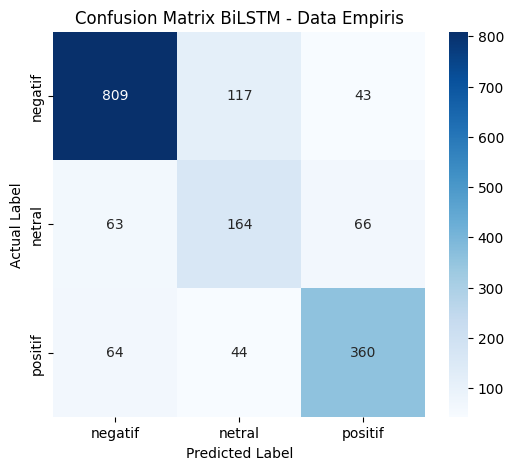

    Model     Data  Accuracy  Precision Macro  Recall Macro  Macro F1
0  BiLSTM  Empiris   0.77052         0.712174       0.72128  0.716166


In [ ]:
# =====================================================
# EVALUASI TEST
# =====================================================

y_pred_bilstm_emp = np.argmax(
    model_bilstm_emp.predict(X_test_pad),
    axis=1
)

label_names = ['negatif', 'netral', 'positif']

print("\n=== CLASSIFICATION REPORT — BiLSTM EMPIRIS ===")
print(classification_report(
    y_test,
    y_pred_bilstm_emp,
    target_names=label_names,
    zero_division=0
))

cm_bilstm_emp = confusion_matrix(
    y_test,
    y_pred_bilstm_emp
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_bilstm_emp,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix BiLSTM - Data Empiris")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

accuracy = accuracy_score(
    y_test,
    y_pred_bilstm_emp
)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_pred_bilstm_emp,
    average='macro',
    zero_division=0
)

hasil_bilstm_emp = pd.DataFrame({
    "Model": ["BiLSTM"],
    "Data": ["Empiris"],
    "Accuracy": [accuracy],
    "Precision Macro": [precision_macro],
    "Recall Macro": [recall_macro],
    "Macro F1": [f1_macro]
})

print(hasil_bilstm_emp)

hasil_bilstm_emp.to_csv(
    "hasil_bilstm_empiris_with_emoticon_stratified_val.csv",
    index=False
)

#BAGIAN 4 — Data Empiris IndoBERTweet-LoRA

In [ ]:
!pip uninstall -y torchao
!pip install -U peft transformers accelerate sentencepiece -q

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 130.3 MB/s eta 0:00:00


In [ ]:
# =====================================================
# 1. IMPORT LIBRARY
# =====================================================

import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [ ]:
# =====================================================
# 2. SET SEED
# =====================================================

seed = 42

set_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("GPU tersedia:", torch.cuda.is_available())

GPU tersedia: True


In [ ]:
# =====================================================
# 6. SPLIT DATA 80:20
# =====================================================
# Test set disimpan untuk evaluasi akhir.

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_bert,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

print("Distribusi train final:")
print(y_train_final.value_counts().sort_index())

print("\nDistribusi validation:")
print(y_val.value_counts().sort_index())

print("\nDistribusi test:")
print(y_test.value_counts().sort_index())

Distribusi train final:
label
0    3486
1    1055
2    1685
Name: count, dtype: int64

Distribusi validation:
label
0    388
1    117
2    187
Name: count, dtype: int64

Distribusi test:
label
0    969
1    293
2    468
Name: count, dtype: int64


In [ ]:
# =====================================================
# 8. TOKENIZER INDOBERTWEET
# =====================================================

model_name = "indolem/indobertweet-base-uncased"

tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# =====================================================
# 9. DATASET PYTORCH
# =====================================================

class SentimenDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts.tolist(),
            padding=True,
            truncation=True,
            max_length=max_length
        )
        self.labels = labels.reset_index(drop=True).values

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
# =====================================================
# 10. BUAT DATASET
# =====================================================
train_dataset = SentimenDataset(
    X_train_final,
    y_train_final,
    tokenizer_bert,
    max_length=128
)

val_dataset = SentimenDataset(
    X_val,
    y_val,
    tokenizer_bert,
    max_length=128
)

test_dataset = SentimenDataset(
    X_test_bert,
    y_test,
    tokenizer_bert,
    max_length=128
)

In [ ]:
# =====================================================
# 11. METRIK EVALUASI
# =====================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='macro',
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [ ]:
# =====================================================
# 12. FUNGSI MEMBUAT MODEL INDOBERTWEET-LORA
# =====================================================

def build_indobertweet_lora(dropout=0.3, r=16, lora_alpha=32):

    id2label = {
        0: "negatif",
        1: "netral",
        2: "positif"
    }

    label2id = {
        "negatif": 0,
        "netral": 1,
        "positif": 2
    }

    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    model.config.id2label = id2label
    model.config.label2id = label2id

    lora_config = LoraConfig(
        r=r,
        lora_alpha=lora_alpha,
        target_modules=["query", "value"],
        lora_dropout=dropout,
        bias="none",
        task_type=TaskType.SEQ_CLS,
        modules_to_save=["classifier"]
    )

    model = get_peft_model(model, lora_config)

    return model

In [ ]:
# =====================================================
# 13. TES MODEL LORA
# =====================================================

test_model = build_indobertweet_lora(
    dropout=0.2,
    r=8,
    lora_alpha=16
)

test_model.print_trainable_parameters()

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 297,219 || all params: 110,857,734 || trainable%: 0.2681


In [ ]:
# =====================================================
# 14. HYPERPARAMETER TUNING INDOBERTWEET-LORA
# =====================================================
# Data empiris.
# Tidak memakai class weight, oversampling, undersampling, atau balancing.

param_grid = [
    {"batch_size": 16, "dropout": 0.2, "learning_rate": 5e-5, "r": 8,  "alpha": 16},
    {"batch_size": 16, "dropout": 0.2, "learning_rate": 1e-4, "r": 8,  "alpha": 16},
    {"batch_size": 16, "dropout": 0.3, "learning_rate": 1e-4, "r": 16, "alpha": 32},
    {"batch_size": 16, "dropout": 0.3, "learning_rate": 2e-4, "r": 16, "alpha": 32},
    {"batch_size": 32, "dropout": 0.2, "learning_rate": 1e-4, "r": 16, "alpha": 32},
    {"batch_size": 32, "dropout": 0.3, "learning_rate": 1e-4, "r": 16, "alpha": 32},
]

tuning_results = []

best_f1 = -1
best_params = None
best_trial = None

for i, params in enumerate(param_grid):

    print("\n=====================================================")
    print(f"Percobaan ke-{i+1}")
    print(params)
    print("=====================================================")

    set_seed(seed)

    model = build_indobertweet_lora(
        dropout=params["dropout"],
        r=params["r"],
        lora_alpha=params["alpha"]
    )

    output_dir = f"./results_indobertweet_lora_emp_trial_{i+1}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=params["learning_rate"],
        per_device_train_batch_size=params["batch_size"],
        per_device_eval_batch_size=params["batch_size"],
        num_train_epochs=5,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_dir=f"./logs_trial_{i+1}",
        logging_steps=50,
        report_to="none",
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    eval_result = trainer.evaluate()

    print("Hasil validation:")
    print(eval_result)

    tuning_results.append({
        "trial": i + 1,
        "batch_size": params["batch_size"],
        "dropout": params["dropout"],
        "learning_rate": params["learning_rate"],
        "r": params["r"],
        "alpha": params["alpha"],
        "accuracy_val": eval_result["eval_accuracy"],
        "precision_macro_val": eval_result["eval_precision_macro"],
        "recall_macro_val": eval_result["eval_recall_macro"],
        "f1_macro_val": eval_result["eval_f1_macro"]
    })

    if eval_result["eval_f1_macro"] > best_f1:
        best_f1 = eval_result["eval_f1_macro"]
        best_params = params
        best_trial = i + 1

print("\n=====================================================")
print("HYPERPARAMETER TERBAIK")
print("=====================================================")
print("Trial terbaik:", best_trial)
print("Parameter terbaik:", best_params)
print("Best validation macro F1:", best_f1)


Percobaan ke-1
{'batch_size': 16, 'dropout': 0.2, 'learning_rate': 5e-05, 'r': 8, 'alpha': 16}


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[trans

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.913945,0.856299,0.617052,0.449578,0.415780,0.384060
2,0.786812,0.748569,0.679191,0.775997,0.541656,0.495951
3,0.757787,0.683929,0.715318,0.723463,0.587936,0.571706
4,0.667309,0.631810,0.754335,0.722186,0.611418,0.605635
5,0.682343,0.623851,0.760116,0.725947,0.618834,0.616177


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[trans

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.910729,0.867362,0.598266,0.435134,0.390760,0.349632
2,0.774118,0.752007,0.682081,0.777433,0.544298,0.497839
3,0.726593,0.663237,0.721098,0.666336,0.598266,0.584664
4,0.654890,0.620976,0.755780,0.701430,0.632033,0.633073
5,0.643753,0.617286,0.761561,0.708238,0.639449,0.643160


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.643753,0.617286,5,0.761561,0.708238,0.639449,0.643160


Hasil validation:
{'eval_loss': 0.6172860860824585, 'eval_accuracy': 0.7615606936416185, 'eval_precision_macro': 0.7082379762639941, 'eval_recall_macro': 0.639449493300312, 'eval_f1_macro': 0.6431602167530693}

HYPERPARAMETER TERBAIK
Trial terbaik: 4
Parameter terbaik: {'batch_size': 16, 'dropout': 0.3, 'learning_rate': 0.0002, 'r': 16, 'alpha': 32}
Best validation macro F1: 0.7233136773907489


In [ ]:
#SIMPAN HASIL TUNING

df_tuning = pd.DataFrame(tuning_results)
df_tuning = df_tuning.sort_values(by="f1_macro_val", ascending=False)

print(df_tuning)

df_tuning.to_csv("hasil_tuning_indobertweet_lora_empiris.csv", index=False)

   trial  batch_size  dropout  learning_rate   r  alpha  accuracy_val  \
3      4          16      0.3        0.00020  16     32      0.787572   
1      2          16      0.2        0.00010   8     16      0.784682   
4      5          32      0.2        0.00010  16     32      0.783237   
2      3          16      0.3        0.00010  16     32      0.770231   
5      6          32      0.3        0.00010  16     32      0.761561   
0      1          16      0.2        0.00005   8     16      0.760116   

   precision_macro_val  recall_macro_val  f1_macro_val  
3             0.737580          0.713544      0.723314  
1             0.728025          0.696973      0.708090  
4             0.729297          0.692134      0.704234  
2             0.710843          0.672463      0.682233  
5             0.708238          0.639449      0.643160  
0             0.725947          0.618834      0.616177  


In [ ]:
#TRAIN ULANG MODEL TERBAIK

best_params = {
    "batch_size": 16,
    "dropout": 0.3,
    "learning_rate": 0.0002,
    "r": 16,
    "alpha": 32
}

In [ ]:
set_seed(seed)

best_model = build_indobertweet_lora(
    dropout=best_params["dropout"],
    r=best_params["r"],
    lora_alpha=best_params["alpha"]
)

best_model.print_trainable_parameters()

training_args_best = TrainingArguments(
    output_dir="./best_indobertweet_lora_empiris",
    learning_rate=best_params["learning_rate"],
    per_device_train_batch_size=best_params["batch_size"],
    per_device_eval_batch_size=best_params["batch_size"],
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    save_total_limit=1
)

trainer_best = Trainer(
    model=best_model,
    args=training_args_best,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer_best.train()

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.722841,0.622786,0.760116,0.726410,0.641790,0.650212
2,0.647656,0.590529,0.773121,0.715057,0.691310,0.700460


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.722841,0.622786,0.760116,0.726410,0.641790,0.650212
2,0.647656,0.590529,0.773121,0.715057,0.691310,0.700460
3,0.605732,0.590349,0.768786,0.714792,0.717514,0.715906
4,0.584345,0.568659,0.789017,0.739141,0.712270,0.722371
5,0.613440,0.571018,0.787572,0.737580,0.713544,0.723314


TrainOutput(global_step=1950, training_loss=0.6390898768107096, metrics={'train_runtime': 490.6891, 'train_samples_per_second': 63.441, 'train_steps_per_second': 3.974, 'total_flos': 1900755750841200.0, 'train_loss': 0.6390898768107096, 'epoch': 5.0})

In [ ]:
label_names = ['negatif', 'netral', 'positif']

In [ ]:
#BAGIAN 17. EVALUASI AKHIR PADA DATA TEST
preds_test = trainer_best.predict(test_dataset)

y_pred_bert_emp = np.argmax(
    preds_test.predictions,
    axis=1
)

print("\n=== CLASSIFICATION REPORT — IndoBERTweet-LoRA EMPIRIS ===")

print(classification_report(
    y_test,
    y_pred_bert_emp,
    target_names=label_names,
    zero_division=0
))


=== CLASSIFICATION REPORT — IndoBERTweet-LoRA EMPIRIS ===
              precision    recall  f1-score   support

     negatif       0.85      0.89      0.87       969
      netral       0.62      0.50      0.55       293
     positif       0.76      0.78      0.77       468

    accuracy                           0.80      1730
   macro avg       0.75      0.73      0.73      1730
weighted avg       0.79      0.80      0.79      1730



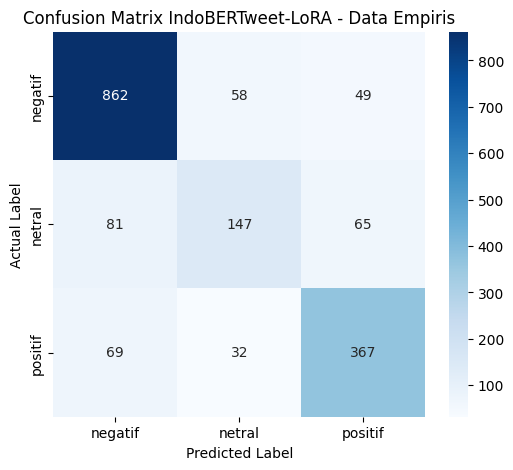

In [ ]:
#BAGIAN 18. CONFUSION MATRIX
cm_bert_emp = confusion_matrix(
    y_test,
    y_pred_bert_emp
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_bert_emp,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix IndoBERTweet-LoRA - Data Empiris")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
#BAGIAN 19. CEK DISTRIBUSI PREDIKSI
print("Distribusi prediksi model:")
print(pd.Series(y_pred_bert_emp).value_counts().sort_index())

print("\nDistribusi aktual:")
print(y_test.value_counts().sort_index())

Distribusi prediksi model:
0    1012
1     237
2     481
Name: count, dtype: int64

Distribusi aktual:
label
0    969
1    293
2    468
Name: count, dtype: int64


In [ ]:
#BAGIAN 20. RINGKASAN METRIK TEST
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_pred_bert_emp,
    average='macro',
    zero_division=0
)

accuracy = accuracy_score(
    y_test,
    y_pred_bert_emp
)

hasil_bert_emp = pd.DataFrame({
    "Model": ["IndoBERTweet-LoRA"],
    "Data": ["Empiris"],
    "Accuracy": [accuracy],
    "Precision Macro": [precision_macro],
    "Recall Macro": [recall_macro],
    "Macro F1": [f1_macro]
})

print(hasil_bert_emp)

hasil_bert_emp.to_csv("hasil_indobertweet_lora_empiris_with_emoticon.csv", index=False)

               Model     Data  Accuracy  Precision Macro  Recall Macro  \
0  IndoBERTweet-LoRA  Empiris  0.795376         0.745009      0.725157   

   Macro F1  
0   0.73281  


In [ ]:
#BAGIAN 21. SIMPAN PREDIKSI DATA TEST
hasil_prediksi_test = pd.DataFrame({
    "text": X_test_bert.reset_index(drop=True),
    "label_aktual": y_test.reset_index(drop=True),
    "sentimen_aktual": y_test.reset_index(drop=True).map({
        0: "negatif",
        1: "netral",
        2: "positif"
    }),
    "label_prediksi": y_pred_bert_emp,
    "sentimen_prediksi": pd.Series(y_pred_bert_emp).map({
        0: "negatif",
        1: "netral",
        2: "positif"
    })
})

print(hasil_prediksi_test.head())

hasil_prediksi_test.to_csv("hasil_prediksi_indobertweet_lora_empiris.csv", index=False)

                                                text  label_aktual  \
0  Siklon Tropis Senyar memengaruhi cuaca ekstrem...             0   
1  Polda Aceh Hadir untuk Warga di Tengah Bencana...             2   
2  Lah, pemerintah selama ini kemana aja? Kocak!!...             0   
3  Akun komentar BANJIR BERULANG DI TAPANULI & SI...             1   
4  Agak kesentil waktu panglima provinsi Anjing b...             0   

  sentimen_aktual  label_prediksi sentimen_prediksi  
0         negatif               0           negatif  
1         positif               2           positif  
2         negatif               0           negatif  
3          netral               1            netral  
4         negatif               0           negatif  


#coba data simulasi lstm

In [ ]:
# =====================================================
# IMPORT
# =====================================================
import pandas as pd
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

In [ ]:
# =====================================================
# SEED
# =====================================================
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
# =====================================================
# LOAD DATA
# =====================================================
data_new = pd.read_csv("data_preprocessed_with_emoticon.csv")
X = data_new['clean_text_lstm']
y = data_new['label']

train_idx, test_idx = train_test_split(
    data_new.index, test_size=0.2, stratify=y, random_state=seed
)
X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=seed
)

In [ ]:
# =====================================================
# TOKENIZER & PADDING
# =====================================================
max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_final)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train_final),
                            maxlen=max_len, padding='post')
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val),
                            maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),
                            maxlen=max_len, padding='post')

In [ ]:
# =====================================================
# GRID SEARCH DATA EMPIRIS
# =====================================================
param_grid = [
    {"batch_size":16, "dropout":0.2, "learning_rate":5e-5, "units":32},
    {"batch_size":16, "dropout":0.2, "learning_rate":1e-4, "units":64},
    {"batch_size":16, "dropout":0.3, "learning_rate":1e-4, "units":64},
    {"batch_size":16, "dropout":0.3, "learning_rate":2e-4, "units":64},
    {"batch_size":32, "dropout":0.2, "learning_rate":1e-4, "units":64},
    {"batch_size":32, "dropout":0.3, "learning_rate":1e-4, "units":64},
]

best_f1 = -1
best_params = None
best_model = None

for i, params in enumerate(param_grid):
    K.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        LSTM(params['units']),
        Dropout(params['dropout']),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=params['learning_rate']),
        metrics=['accuracy']
    )

    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    model.fit(X_train_pad, y_train_final, validation_data=(X_val_pad, y_val),
              epochs=20, batch_size=params['batch_size'], callbacks=[es], verbose=0)

    y_val_pred = np.argmax(model.predict(X_val_pad), axis=1)
    _, _, f1_macro, _ = precision_recall_fscore_support(y_val, y_val_pred,
                                                        average='macro', zero_division=0)

    if f1_macro > best_f1:
        best_f1 = f1_macro
        best_params = params
        best_model = model

print("Best Params:", best_params)
print("Best Validation Macro F1:", best_f1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


...

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Best Params: {'batch_size': 16, 'dropout': 0.3, 'learning_rate': 0.0002, 'units': 64}
Best Validation Macro F1: 0.6266463155107814


In [ ]:
# =====================================================
# SIMULASI SKENARIO
# =====================================================
train_df = pd.DataFrame({'text': X_train.values, 'label': y_train.values})
train_counts = train_df['label'].value_counts().sort_index()
n_neg, n_net, n_pos = train_counts[0], train_counts[1], train_counts[2]

def buat_skenario(df, n_neg, n_net, n_pos, seed=42):
    neg = df[df['label']==0].sample(n=n_neg, random_state=seed)
    net = df[df['label']==1].sample(n=n_net, random_state=seed)
    pos = df[df['label']==2].sample(n=n_pos, random_state=seed)
    result = pd.concat([neg, net, pos]).sample(frac=1, random_state=seed).reset_index(drop=True)
    return result

skenario_111 = buat_skenario(train_df, n_neg=min(n_neg,n_net,n_pos),
                             n_net=min(n_neg,n_net,n_pos),
                             n_pos=min(n_neg,n_net,n_pos))
skenario_631 = buat_skenario(train_df, n_neg=n_neg//6*6, n_net=n_net, n_pos=n_pos//3*3)
skenario_811 = buat_skenario(train_df, n_neg=n_neg//8*8, n_net=n_net, n_pos=n_pos//1)


In [ ]:
# =====================================================
# TRAINING SIMULASI DENGAN BEST PARAMS
# =====================================================
def train_lstm_skenario(skenario_df, nama_skenario):
    K.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    X_train_sim = skenario_df['text']
    y_train_sim = skenario_df['label']

    X_train_sim_final, X_val_sim, y_train_sim_final, y_val_sim = train_test_split(
        X_train_sim, y_train_sim, test_size=0.1,
        stratify=y_train_sim, random_state=seed
    )

    X_train_seq = tokenizer.texts_to_sequences(X_train_sim_final)
    X_val_seq   = tokenizer.texts_to_sequences(X_val_sim)
    X_test_seq  = tokenizer.texts_to_sequences(X_test)

    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
    X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
    X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

    model = Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        LSTM(best_params['units']),
        Dropout(best_params['dropout']),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=best_params['learning_rate']),
        metrics=['accuracy']
    )

    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    model.fit(X_train_pad, y_train_sim_final, validation_data=(X_val_pad, y_val_sim),
              epochs=20, batch_size=best_params['batch_size'], callbacks=[es], verbose=1)

    y_pred = np.argmax(model.predict(X_test_pad), axis=1)

    print(f"\n=== CLASSIFICATION REPORT SKENARIO {nama_skenario} ===")
    print(classification_report(y_test, y_pred, target_names=['negatif','netral','positif'], zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['negatif','netral','positif'],
                yticklabels=['negatif','netral','positif'])
    plt.title(f"Confusion Matrix LSTM - {nama_skenario}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

    return y_pred


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3224 - loss: 1.0998 - val_accuracy: 0.3381 - val_loss: 1.0985
Epoch 2/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3312 - loss: 1.0991 - val_accuracy: 0.3324 - val_loss: 1.0984
Epoch 3/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3154 - loss: 1.0993 - val_accuracy: 0.3381 - val_loss: 1.0984
Epoch 4/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3413 - loss: 1.0981 - val_accuracy: 0.3892 - val_loss: 1.0929
Epoch 5/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5259 - loss: 0.9316 - val_accuracy: 0.4943 - val_loss: 1.0037
Epoch 6/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6166 - loss: 0.7451 - val_accuracy: 0.5625 - val_loss: 0.9834
Epoch 7/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6871 - loss: 0.6299 - val_accuracy: 0.5199 - val_loss: 1.0701
Epoch 8/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8180 - loss: 0.4997 - val_accuracy: 0.6506 - val_

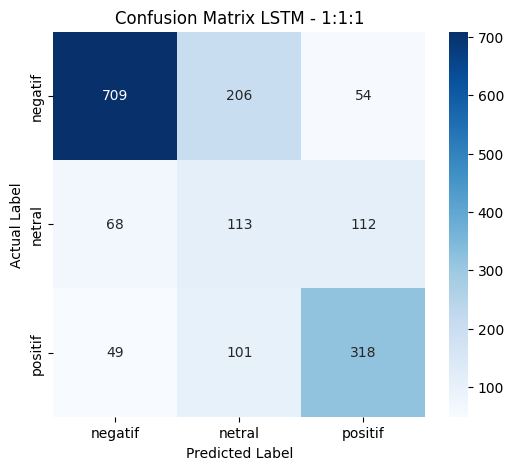

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5580 - loss: 0.9923 - val_accuracy: 0.5592 - val_loss: 0.9786
Epoch 2/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5786 - loss: 0.9331 - val_accuracy: 0.6763 - val_loss: 0.7810
Epoch 3/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7395 - loss: 0.6507 - val_accuracy: 0.7225 - val_loss: 0.6868
Epoch 4/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7919 - loss: 0.5298 - val_accuracy: 0.7370 - val_loss: 0.6714
Epoch 5/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8333 - loss: 0.4598 - val_accuracy: 0.7471 - val_loss: 0.7048
Epoch 6/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8626 - loss: 0.4080 - val_accuracy: 0.7413 - val_loss: 0.7449
Epoch 7/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8978 - loss: 0.3330 - val_accuracy: 0.7442 - val_loss: 0.8669
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

=== CLASSIFICATION REPORT SKENARIO 6:3:1 ===
              precision    rec

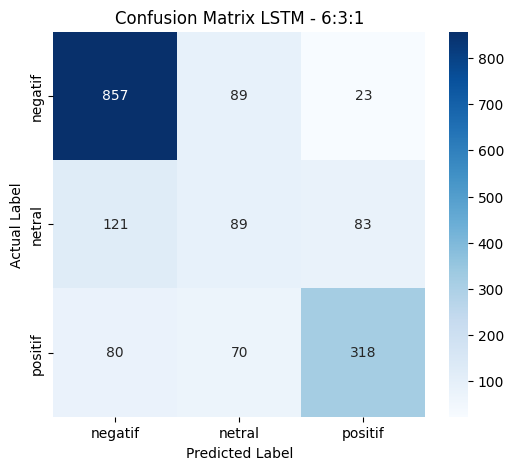

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5586 - loss: 0.9897 - val_accuracy: 0.5607 - val_loss: 0.9801
Epoch 2/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5763 - loss: 0.9424 - val_accuracy: 0.6763 - val_loss: 0.8048
Epoch 3/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7375 - loss: 0.6510 - val_accuracy: 0.7182 - val_loss: 0.7093
Epoch 4/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7934 - loss: 0.5138 - val_accuracy: 0.6850 - val_loss: 0.8130
Epoch 5/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8393 - loss: 0.4398 - val_accuracy: 0.7038 - val_loss: 0.8833
Epoch 6/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8623 - loss: 0.3975 - val_accuracy: 0.7023 - val_loss: 0.8954
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

=== CLASSIFICATION REPORT SKENARIO 8:1:1 ===
              precision    recall  f1-score   support

     negatif       0.81      0.89      0.85       969
      netral       0.00      0.00      0.00      

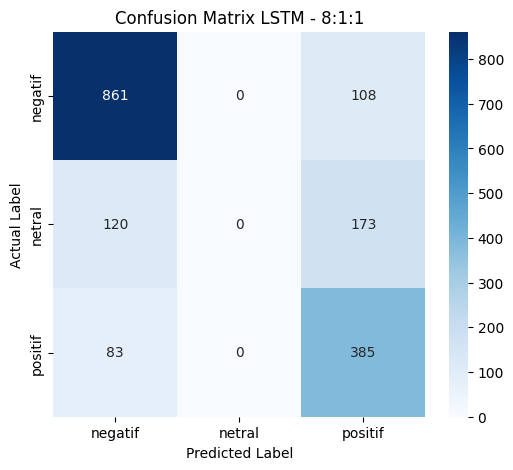

In [ ]:
# =====================================================
# Jalankan simulasi
# =====================================================
y_pred_111 = train_lstm_skenario(skenario_111, "1:1:1")
y_pred_631 = train_lstm_skenario(skenario_631, "6:3:1")
y_pred_811 = train_lstm_skenario(skenario_811, "8:1:1")

In [ ]:
# =====================================================
# 1. IMPORT LIBRARY
# =====================================================

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K


In [ ]:
# =====================================================
# 2. SET SEED
# =====================================================

seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
# =====================================================
# 3. PARAMETER
# =====================================================
max_words = 10000
max_len = 50

In [ ]:
# =====================================================
# 4. GABUNGKAN DATA TRAIN
# =====================================================
train_df = pd.DataFrame({
    'text': X_train_lstm.reset_index(drop=True),
    'label': y_train.reset_index(drop=True)
})

print("Distribusi data train:")
print(train_df['label'].value_counts().sort_index())


Distribusi data train:
label
0    3874
1    1172
2    1872
Name: count, dtype: int64


In [ ]:
# =====================================================
# 5. HITUNG JUMLAH SKENARIO BERDASARKAN DATA TRAIN
# =====================================================
train_counts = train_df['label'].value_counts().sort_index()
n_neg, n_net, n_pos = train_counts[0], train_counts[1], train_counts[2]

# 1:1:1
base_111 = min(n_neg, n_net, n_pos)
n_111_neg, n_111_net, n_111_pos = base_111, base_111, base_111

# 6:3:1
base_631 = min(n_neg//6, n_pos//3, n_net//1)
n_631_neg, n_631_pos, n_631_net = 6*base_631, 3*base_631, 1*base_631

# 8:1:1
base_811 = min(n_neg//8, n_pos//1, n_net//1)
n_811_neg, n_811_pos, n_811_net = 8*base_811, 1*base_811, 1*base_811


In [ ]:
# =====================================================
# 6. FUNGSI MEMBUAT SKENARIO
# =====================================================
def buat_skenario(df, n_neg, n_net, n_pos, random_state=42):
    neg = df[df['label']==0].sample(n=n_neg, random_state=random_state, replace=False)
    net = df[df['label']==1].sample(n=n_net, random_state=random_state, replace=False)
    pos = df[df['label']==2].sample(n=n_pos, random_state=random_state, replace=False)

    result = pd.concat([neg, net, pos])
    result = result.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return result

In [ ]:
# =====================================================
# 7. MEMBUAT DATA SIMULASI
# =====================================================
skenario_111 = buat_skenario(train_df, n_111_neg, n_111_net, n_111_pos)
skenario_631 = buat_skenario(train_df, n_631_neg, n_631_net, n_631_pos)
skenario_811 = buat_skenario(train_df, n_811_neg, n_811_net, n_811_pos)


In [ ]:
# =====================================================
# 8. CEK DISTRIBUSI
# =====================================================
for skenario, name in zip([skenario_111, skenario_631, skenario_811],
                          ["1:1:1", "6:3:1", "8:1:1"]):
    print(f"\n=== SKENARIO {name} ===")
    print(skenario['label'].value_counts().sort_index())


=== SKENARIO 1:1:1 ===
label
0    1172
1    1172
2    1172
Name: count, dtype: int64

=== SKENARIO 6:3:1 ===
label
0    3744
1     624
2    1872
Name: count, dtype: int64

=== SKENARIO 8:1:1 ===
label
0    3872
1     484
2     484
Name: count, dtype: int64


In [ ]:
# =====================================================
# 9. FUNGSI TRAINING DAN EVALUASI LSTM
# =====================================================
def train_lstm_skenario(skenario_df, nama_skenario):
    print(f"\n{'='*60}\nLSTM - SKENARIO {nama_skenario}\n{'='*60}")

    K.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    X_train_sim = skenario_df['text']
    y_train_sim = skenario_df['label']

    # Split train-validation
    X_train_sim_final, X_val_sim, y_train_sim_final, y_val_sim = train_test_split(
        X_train_sim,
        y_train_sim,
        test_size=0.1,
        stratify=y_train_sim,
        random_state=seed
    )

    # Tokenizer
    tokenizer_sim = Tokenizer(num_words=max_words, oov_token="<OOV>")
    tokenizer_sim.fit_on_texts(X_train_sim_final)

    X_train_seq = tokenizer_sim.texts_to_sequences(X_train_sim_final)
    X_val_seq = tokenizer_sim.texts_to_sequences(X_val_sim)
    X_test_seq = tokenizer_sim.texts_to_sequences(X_test_lstm)

    X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
    X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
    X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

    # Build model LSTM
    model = Sequential()
    model.add(Embedding(max_words, 128, input_length=max_len))
    model.add(LSTM(64))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(3, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])

    # Early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train_pad, y_train_sim_final,
        epochs=20,
        batch_size=32,
        validation_data=(X_val_pad, y_val_sim),
        callbacks=[early_stop],
        verbose=1
    )

    # Prediksi test
    y_pred = np.argmax(model.predict(X_test_pad), axis=1)

    label_names = ['negatif','netral','positif']

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.title(f"Confusion Matrix LSTM - {nama_skenario}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

    # Ringkasan metrik
    accuracy = accuracy_score(y_test, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )

    hasil = {
        "Skenario": nama_skenario,
        "Model": "LSTM",
        "Accuracy": accuracy,
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "Macro F1": f1_macro
    }

    return hasil, y_pred, cm, history


LSTM - SKENARIO 1:1:1
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3110 - loss: 1.1012 - val_accuracy: 0.3352 - val_loss: 1.0986
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3281 - loss: 1.0999 - val_accuracy: 0.2812 - val_loss: 1.0989
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3707 - loss: 1.0848 - val_accuracy: 0.4688 - val_loss: 1.0116
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5376 - loss: 0.9234 - val_accuracy: 0.5455 - val_loss: 0.9340
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5992 - loss: 0.7902 - val_accuracy: 0.5312 - val_loss: 1.0821
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6479 - loss: 0.6973 - val_accuracy: 0.4886 - val_loss: 0.9858
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7655 - loss: 0.5827 - val_accuracy: 0.5824 - val_loss: 1.1568
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   

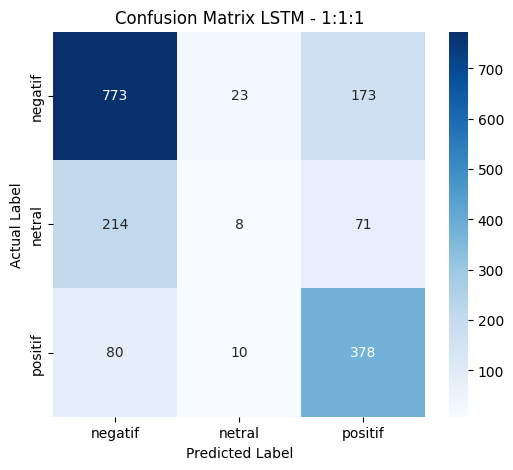


LSTM - SKENARIO 6:3:1
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5974 - loss: 0.9134 - val_accuracy: 0.6010 - val_loss: 0.9020
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5999 - loss: 0.9049 - val_accuracy: 0.6010 - val_loss: 0.9018
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6360 - loss: 0.8686 - val_accuracy: 0.6234 - val_loss: 0.9045
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7085 - loss: 0.7722 - val_accuracy: 0.7115 - val_loss: 0.7917
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7128 - loss: 0.7912 - val_accuracy: 0.6971 - val_loss: 0.8070
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7199 - loss: 0.7808 - val_accuracy: 0.6939 - val_loss: 0.8070
Epoch 7/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7039 - loss: 0.7866 - val_accuracy: 0.6859 - val_loss: 0.8106
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score  

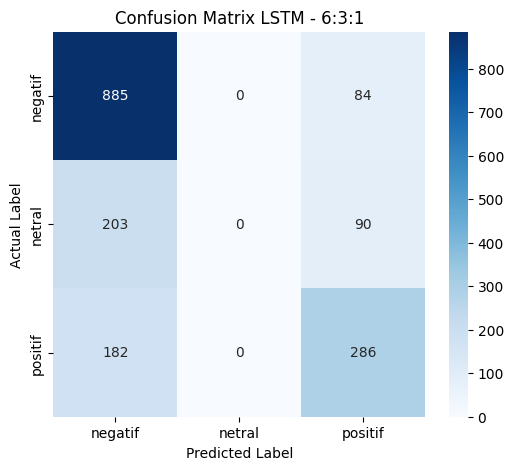


LSTM - SKENARIO 8:1:1
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7957 - loss: 0.6672 - val_accuracy: 0.7996 - val_loss: 0.6415
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8000 - loss: 0.6499 - val_accuracy: 0.7996 - val_loss: 0.6432
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8000 - loss: 0.6454 - val_accuracy: 0.7996 - val_loss: 0.6393
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8000 - loss: 0.6047 - val_accuracy: 0.7996 - val_loss: 0.5706
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8157 - loss: 0.5194 - val_accuracy: 0.7686 - val_loss: 0.5740
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8083 - loss: 0.5236 - val_accuracy: 0.7996 - val_loss: 0.6357
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8278 - loss: 0.4985 - val_accuracy: 0.7872 - val_loss: 0.5932
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score 

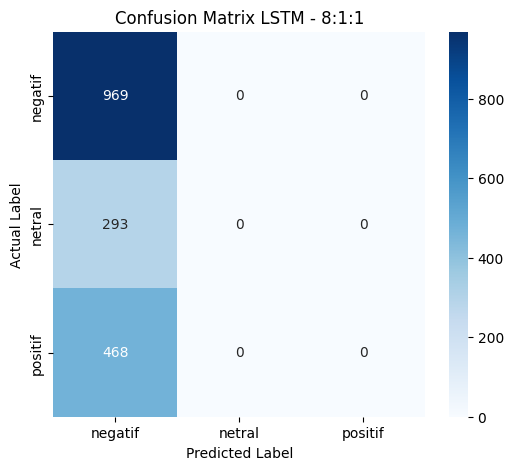

In [ ]:
# =====================================================
# 10. TRAINING SIMULASI
# =====================================================
hasil_111, y_pred_111, cm_111, history_111 = train_lstm_skenario(skenario_111, "1:1:1")
hasil_631, y_pred_631, cm_631, history_631 = train_lstm_skenario(skenario_631, "6:3:1")
hasil_811, y_pred_811, cm_811, history_811 = train_lstm_skenario(skenario_811, "8:1:1")


In [ ]:
# =====================================================
# 11. RINGKASAN HASIL SEMUA SKENARIO
# =====================================================
hasil_simulasi_lstm = pd.DataFrame([hasil_111, hasil_631, hasil_811])
print(hasil_simulasi_lstm)

hasil_simulasi_lstm.to_csv("hasil_simulasi_lstm_with_emoticon_stratified_val.csv", index=False)


  Skenario Model  Accuracy  Precision Macro  Recall Macro  Macro F1
0    1:1:1  LSTM  0.671676         0.565522      0.537991  0.489435
1    6:3:1  LSTM  0.687861         0.442478      0.519465  0.476783
2    8:1:1  LSTM  0.664740         0.422617      0.492079  0.452607


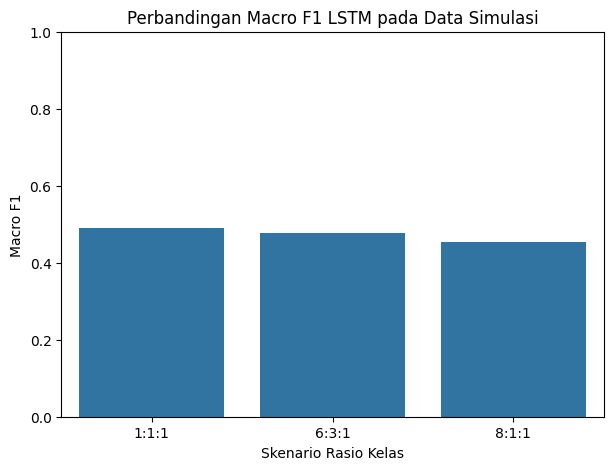

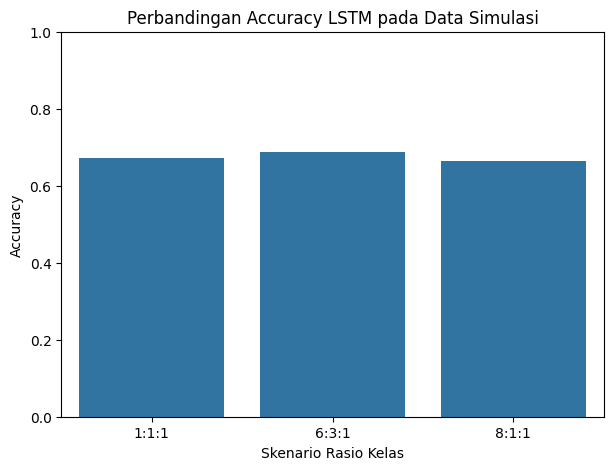

In [ ]:
# =====================================================
# 12. VISUALISASI
# =====================================================
plt.figure(figsize=(7,5))
sns.barplot(data=hasil_simulasi_lstm, x="Skenario", y="Macro F1")
plt.title("Perbandingan Macro F1 LSTM pada Data Simulasi")
plt.xlabel("Skenario Rasio Kelas")
plt.ylabel("Macro F1")
plt.ylim(0,1)
plt.show()

plt.figure(figsize=(7,5))
sns.barplot(data=hasil_simulasi_lstm, x="Skenario", y="Accuracy")
plt.title("Perbandingan Accuracy LSTM pada Data Simulasi")
plt.xlabel("Skenario Rasio Kelas")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

#BAGIAN 5 — Data Simulasi biLSTM


In [ ]:
# =====================================================
# 1. IMPORT LIBRARY
# =====================================================

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

In [ ]:
# =====================================================
# 2. SET SEED
# =====================================================

seed = 42

np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

max_words = 10000
max_len = 50

In [ ]:
# =====================================================
# 3. GABUNGKAN DATA TRAIN
# =====================================================
# Data simulasi hanya dibentuk dari data latih.
# Jangan mengambil dari seluruh data agar tidak terjadi data leakage.

train_df = pd.DataFrame({
    'text': X_train_lstm.reset_index(drop=True),
    'label': y_train.reset_index(drop=True)
})

print("Distribusi data train:")
print(train_df['label'].value_counts().sort_index())

print("\nKeterangan label:")
print("0 = negatif")
print("1 = netral")
print("2 = positif")

Distribusi data train:
label
0.0    3874
1.0    1172
2.0    1872
Name: count, dtype: int64

Keterangan label:
0 = negatif
1 = netral
2 = positif


In [ ]:
# =====================================================
# 4. HITUNG JUMLAH SKENARIO BERDASARKAN DATA TRAIN
# =====================================================
# Rasio disusun mengikuti kondisi empiris:
# negatif = mayoritas
# positif = sedang
# netral = minoritas
#
# Jadi untuk skenario tidak seimbang:
# 6:3:1 = negatif : positif : netral
# 8:1:1 = negatif : positif : netral

train_counts = train_df['label'].value_counts().sort_index()

n_neg = train_counts[0]
n_net = train_counts[1]
n_pos = train_counts[2]

print("Jumlah data train:")
print("Negatif:", n_neg)
print("Netral :", n_net)
print("Positif:", n_pos)

# =====================================================
# Skenario 1:1:1
# =====================================================

base_111 = min(n_neg, n_net, n_pos)

n_111_neg = base_111
n_111_net = base_111
n_111_pos = base_111

# =====================================================
# Skenario 6:3:1
# Rasio substantif: negatif : positif : netral
# =====================================================

base_631 = min(
    n_neg // 6,
    n_pos // 3,
    n_net // 1
)

n_631_neg = 6 * base_631
n_631_pos = 3 * base_631
n_631_net = 1 * base_631

# =====================================================
# Skenario 8:1:1
# Rasio substantif: negatif : positif : netral
# =====================================================

base_811 = min(
    n_neg // 8,
    n_pos // 1,
    n_net // 1
)

n_811_neg = 8 * base_811
n_811_pos = 1 * base_811
n_811_net = 1 * base_811

print("\n=== JUMLAH DATA SIMULASI ===")

print("\nSkenario 1:1:1")
print("Negatif:", n_111_neg)
print("Netral :", n_111_net)
print("Positif:", n_111_pos)
print("Total  :", n_111_neg + n_111_net + n_111_pos)

print("\nSkenario 6:3:1")
print("Negatif:", n_631_neg)
print("Netral :", n_631_net)
print("Positif:", n_631_pos)
print("Total  :", n_631_neg + n_631_net + n_631_pos)

print("\nSkenario 8:1:1")
print("Negatif:", n_811_neg)
print("Netral :", n_811_net)
print("Positif:", n_811_pos)
print("Total  :", n_811_neg + n_811_net + n_811_pos)

Jumlah data train:
Negatif: 3874
Netral : 1172
Positif: 1872

=== JUMLAH DATA SIMULASI ===

Skenario 1:1:1
Negatif: 1172
Netral : 1172
Positif: 1172
Total  : 3516

Skenario 6:3:1
Negatif: 3744
Netral : 624
Positif: 1872
Total  : 6240

Skenario 8:1:1
Negatif: 3872
Netral : 484
Positif: 484
Total  : 4840


In [ ]:
# =====================================================
# 5. FUNGSI MEMBUAT SKENARIO
# =====================================================

def buat_skenario(df, n_neg, n_net, n_pos, random_state=42):

    neg = df[df['label'] == 0].sample(
        n=n_neg,
        random_state=random_state,
        replace=False
    )

    net = df[df['label'] == 1].sample(
        n=n_net,
        random_state=random_state,
        replace=False
    )

    pos = df[df['label'] == 2].sample(
        n=n_pos,
        random_state=random_state,
        replace=False
    )

    result = pd.concat([neg, net, pos])

    result = result.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    return result

In [ ]:
# =====================================================
# 6. MEMBUAT DATA SIMULASI
# =====================================================

skenario_111 = buat_skenario(
    train_df,
    n_neg=n_111_neg,
    n_net=n_111_net,
    n_pos=n_111_pos,
    random_state=42
)

skenario_631 = buat_skenario(
    train_df,
    n_neg=n_631_neg,
    n_net=n_631_net,
    n_pos=n_631_pos,
    random_state=42
)

skenario_811 = buat_skenario(
    train_df,
    n_neg=n_811_neg,
    n_net=n_811_net,
    n_pos=n_811_pos,
    random_state=42
)

In [ ]:
# =====================================================
# 7. CEK DISTRIBUSI SKENARIO
# =====================================================

print("=== SKENARIO 1:1:1 ===")
print(skenario_111['label'].value_counts().sort_index())

print("\n=== SKENARIO 6:3:1 ===")
print(skenario_631['label'].value_counts().sort_index())

print("\n=== SKENARIO 8:1:1 ===")
print(skenario_811['label'].value_counts().sort_index())

=== SKENARIO 1:1:1 ===
label
0.0    1172
1.0    1172
2.0    1172
Name: count, dtype: int64

=== SKENARIO 6:3:1 ===
label
0.0    3744
1.0     624
2.0    1872
Name: count, dtype: int64

=== SKENARIO 8:1:1 ===
label
0.0    3872
1.0     484
2.0     484
Name: count, dtype: int64


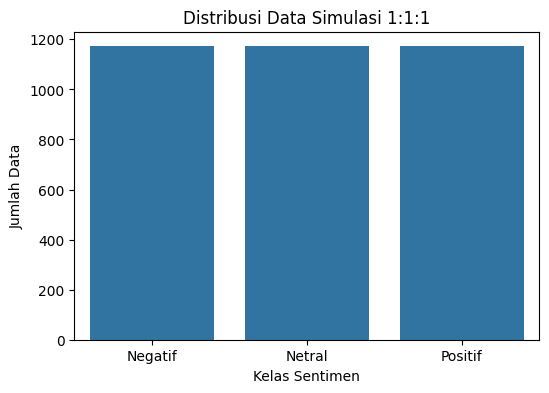

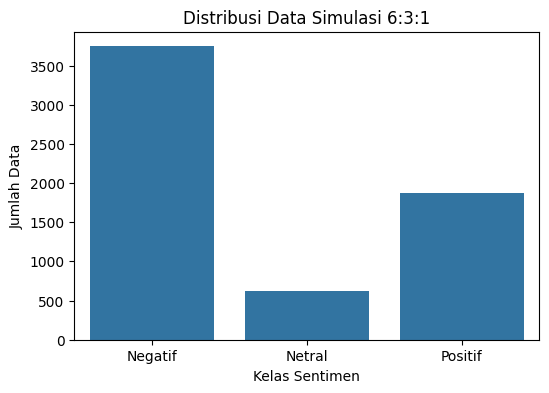

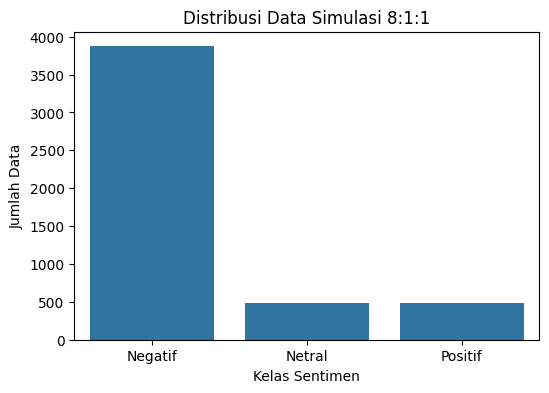

In [ ]:
# =====================================================
# 8. VISUALISASI DISTRIBUSI SKENARIO
# =====================================================

def plot_distribusi_skenario(df, nama_skenario):

    counts = df['label'].value_counts().sort_index()
    label_names = ['Negatif', 'Netral', 'Positif']

    y_values = [
        counts.get(0, 0),
        counts.get(1, 0),
        counts.get(2, 0)
    ]

    plt.figure(figsize=(6, 4))
    sns.barplot(
        x=label_names,
        y=y_values
    )

    plt.title(f"Distribusi Data Simulasi {nama_skenario}")
    plt.xlabel("Kelas Sentimen")
    plt.ylabel("Jumlah Data")
    plt.show()

plot_distribusi_skenario(skenario_111, "1:1:1")
plot_distribusi_skenario(skenario_631, "6:3:1")
plot_distribusi_skenario(skenario_811, "8:1:1")

In [ ]:
# =====================================================
# 10. FUNGSI TRAINING DAN EVALUASI BiLSTM
# =====================================================

def train_bilstm_skenario(skenario_df, nama_skenario):

    print(f"\n{'='*60}")
    print(f"BiLSTM - SKENARIO {nama_skenario}")
    print(f"{'='*60}")

    K.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)
    random.seed(42)

    # =================================================
    # Ambil data simulasi
    # =================================================

    X_train_sim = skenario_df['text']
    y_train_sim = skenario_df['label']

    # =================================================
    # Split train-validation secara stratified
    # =================================================

    X_train_sim_final, X_val_sim, y_train_sim_final, y_val_sim = train_test_split(
        X_train_sim,
        y_train_sim,
        test_size=0.1,
        stratify=y_train_sim,
        random_state=42
    )

    print("Distribusi train simulasi final:")
    print(y_train_sim_final.value_counts().sort_index())

    print("\nDistribusi validation simulasi:")
    print(y_val_sim.value_counts().sort_index())

    # =================================================
    # Tokenizer dari train final simulasi
    # =================================================

    tokenizer_sim = Tokenizer(
        num_words=max_words,
        oov_token="<OOV>"
    )

    tokenizer_sim.fit_on_texts(X_train_sim_final)

    X_train_seq = tokenizer_sim.texts_to_sequences(X_train_sim_final)
    X_val_seq = tokenizer_sim.texts_to_sequences(X_val_sim)
    X_test_seq = tokenizer_sim.texts_to_sequences(X_test_lstm)

    X_train_pad = pad_sequences(
        X_train_seq,
        maxlen=max_len,
        padding='post'
    )

    X_val_pad = pad_sequences(
        X_val_seq,
        maxlen=max_len,
        padding='post'
    )

    X_test_pad = pad_sequences(
        X_test_seq,
        maxlen=max_len,
        padding='post'
    )

    # =================================================
    # Build model BiLSTM
    # =================================================

    model = Sequential()

    model.add(
        Embedding(
            input_dim=max_words,
            output_dim=128,
            input_length=max_len
        )
    )

    model.add(
        Bidirectional(
            LSTM(64)
        )
    )

    model.add(
        Dropout(0.3)
    )

    model.add(
        Dense(64, activation='relu')
    )

    model.add(
        Dense(3, activation='softmax')
    )

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )

    # =================================================
    # Early stopping
    # =================================================

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # =================================================
    # Training
    # =================================================

    history = model.fit(
        X_train_pad,
        y_train_sim_final,
        epochs=20,
        batch_size=32,
        validation_data=(X_val_pad, y_val_sim),
        callbacks=[early_stop],
        verbose=1
    )

    # =================================================
    # Prediksi pada data test empiris
    # =================================================

    y_pred = np.argmax(
        model.predict(X_test_pad),
        axis=1
    )

    label_names = ['negatif', 'netral', 'positif']

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_names,
        zero_division=0
    ))

    # =================================================
    # Confusion matrix
    # =================================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )

    plt.title(f"Confusion Matrix BiLSTM - Skenario {nama_skenario}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

    # =================================================
    # Ringkasan metrik
    # =================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    hasil = {
        "Skenario": nama_skenario,
        "Model": "BiLSTM",
        "Accuracy": accuracy,
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "Macro F1": f1_macro
    }

    return hasil, y_pred, cm, history


BiLSTM - SKENARIO 1:1:1
Distribusi train simulasi final:
label
0.0    1055
1.0    1055
2.0    1054
Name: count, dtype: int64

Distribusi validation simulasi:
label
0.0    117
1.0    117
2.0    118
Name: count, dtype: int64
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5009 - loss: 0.9760 - val_accuracy: 0.6506 - val_loss: 0.8236
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7803 - loss: 0.5519 - val_accuracy: 0.6534 - val_loss: 0.8676
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8903 - loss: 0.3106 - val_accuracy: 0.6364 - val_loss: 1.0764
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9355 - loss: 0.1794 - val_accuracy: 0.6449 - val_loss: 1.1990
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.87      0.66      0.75       969
      netral       0.38      0.70      0.50       293
     positif       0.72      0.70      0.71       468

    accuracy                           0.68      1730
   macro avg       0.66      0.69      0.65      1730
weighted avg       0.75      0.68      0.70      1730



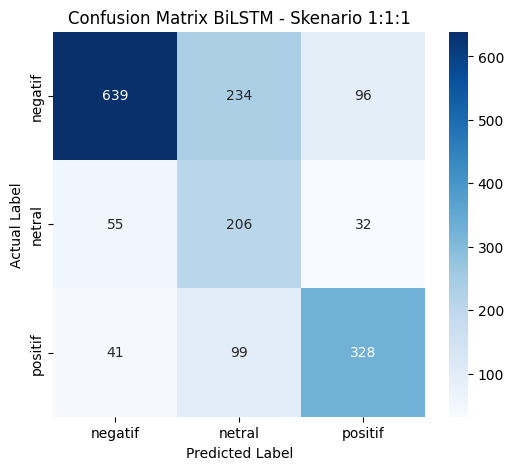

In [ ]:
# =====================================================
# 11. TRAINING SKENARIO 1:1:1
# =====================================================

hasil_111, y_pred_111, cm_111, history_111 = train_bilstm_skenario(
    skenario_111,
    "1:1:1"
)


BiLSTM - SKENARIO 6:3:1
Distribusi train simulasi final:
label
0.0    3369
1.0     562
2.0    1685
Name: count, dtype: int64

Distribusi validation simulasi:
label
0.0    375
1.0     62
2.0    187
Name: count, dtype: int64
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7340 - loss: 0.6905 - val_accuracy: 0.7965 - val_loss: 0.5620
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8519 - loss: 0.4093 - val_accuracy: 0.7869 - val_loss: 0.5708
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9097 - loss: 0.2670 - val_accuracy: 0.7901 - val_loss: 0.6548
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9421 - loss: 0.1837 - val_accuracy: 0.7708 - val_loss: 0.7686
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.73      0.98      0.84       969
      netral       0.00      0.00      0.00       293
     positif       0.75      0.71      0.73       468

    accuracy                           0.74      1730
   macro avg       0.50      0.56      0.52      1730
weighted avg       0.62      0.74      0.67      1730



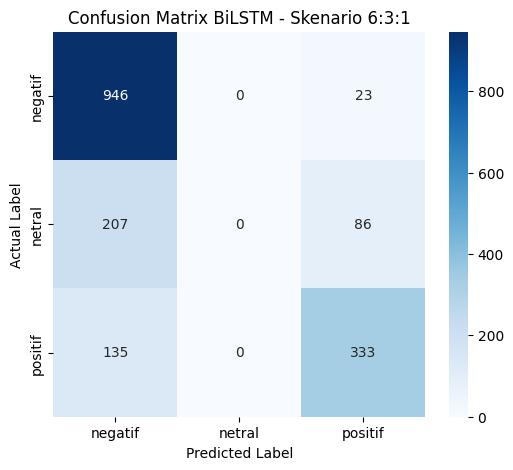

In [ ]:
# =====================================================
# 12. TRAINING SKENARIO 6:3:1
# =====================================================

hasil_631, y_pred_631, cm_631, history_631 = train_bilstm_skenario(
    skenario_631,
    "6:3:1"
)


BiLSTM - SKENARIO 8:1:1
Distribusi train simulasi final:
label
0.0    3485
1.0     435
2.0     436
Name: count, dtype: int64

Distribusi validation simulasi:
label
0.0    387
1.0     49
2.0     48
Name: count, dtype: int64
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8053 - loss: 0.5774 - val_accuracy: 0.8244 - val_loss: 0.4837
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8719 - loss: 0.3433 - val_accuracy: 0.8120 - val_loss: 0.4848
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9236 - loss: 0.2220 - val_accuracy: 0.8202 - val_loss: 0.5615
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9580 - loss: 0.1283 - val_accuracy: 0.8182 - val_loss: 0.7238
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.71      0.97      0.82       969
      netral       0.00      0.00      0.00       293
     positif       0.69      0.61      0.65       468

    accuracy                           0.71      1730
   macro avg       0.47      0.53      0.49      1730
weighted avg       0.59      0.71      0.63      1730



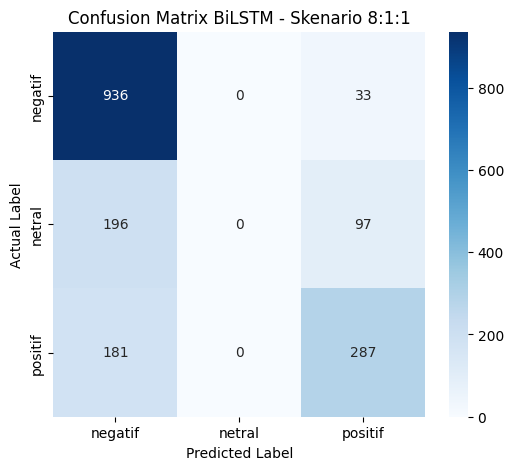

In [ ]:
# =====================================================
# 13. TRAINING SKENARIO 8:1:1
# =====================================================

hasil_811, y_pred_811, cm_811, history_811 = train_bilstm_skenario(
    skenario_811,
    "8:1:1"
)

In [ ]:
# =====================================================
# 14. RINGKASAN HASIL SEMUA SKENARIO
# =====================================================

hasil_simulasi_bilstm = pd.DataFrame([
    hasil_111,
    hasil_631,
    hasil_811
])

print(hasil_simulasi_bilstm)

hasil_simulasi_bilstm.to_csv(
    "hasil_simulasi_bilstm_with_emoticon_stratified_val.csv",
    index=False
)

  Skenario   Model  Accuracy  Precision Macro  Recall Macro  Macro F1
0    1:1:1  BiLSTM  0.678035         0.656958      0.687790  0.651716
1    6:3:1  BiLSTM  0.739306         0.495955      0.562601  0.523383
2    8:1:1  BiLSTM  0.706936         0.467040      0.526397  0.489640


In [ ]:
# =====================================================
# 15. SIMPAN PREDIKSI PER SKENARIO
# =====================================================

id2label = {
    0: "negatif",
    1: "netral",
    2: "positif"
}

prediksi_simulasi_bilstm = pd.DataFrame({
    "text": X_test_lstm.reset_index(drop=True),
    "label_aktual": y_test.reset_index(drop=True),
    "sentimen_aktual": y_test.reset_index(drop=True).map(id2label),

    "pred_111": y_pred_111,
    "sentimen_pred_111": pd.Series(y_pred_111).map(id2label),

    "pred_631": y_pred_631,
    "sentimen_pred_631": pd.Series(y_pred_631).map(id2label),

    "pred_811": y_pred_811,
    "sentimen_pred_811": pd.Series(y_pred_811).map(id2label)
})

display(prediksi_simulasi_bilstm.head())

prediksi_simulasi_bilstm.to_csv(
    "prediksi_simulasi_bilstm_with_emoticon_stratified_val.csv",
    index=False
)

,text,label_aktual,sentimen_aktual,pred_111,sentimen_pred_111,pred_631,sentimen_pred_631,pred_811,sentimen_pred_811
0,siklon tropis senyar pengaruh cuaca ekstrem su...,0.0,negatif,1,netral,0,negatif,0,negatif
1,polda aceh hadir warga tengah bencana curah hu...,2.0,positif,2,positif,2,positif,2,positif
2,lah perintah lama kocak upaya preventif lebih ...,0.0,negatif,0,negatif,0,negatif,0,negatif
3,akun komentar banjir ulang tapanuli sibolga be...,1.0,netral,1,netral,0,negatif,2,positif
4,sentil waktu panglima provinsi anjing bilang w...,0.0,negatif,0,negatif,0,negatif,0,negatif


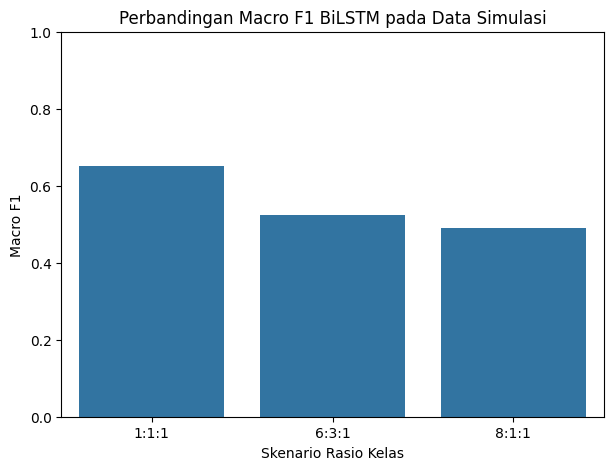

In [ ]:
# =====================================================
# 16. VISUALISASI MACRO F1 PER SKENARIO
# =====================================================

plt.figure(figsize=(7, 5))

sns.barplot(
    data=hasil_simulasi_bilstm,
    x="Skenario",
    y="Macro F1"
)

plt.title("Perbandingan Macro F1 BiLSTM pada Data Simulasi")
plt.xlabel("Skenario Rasio Kelas")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.show()

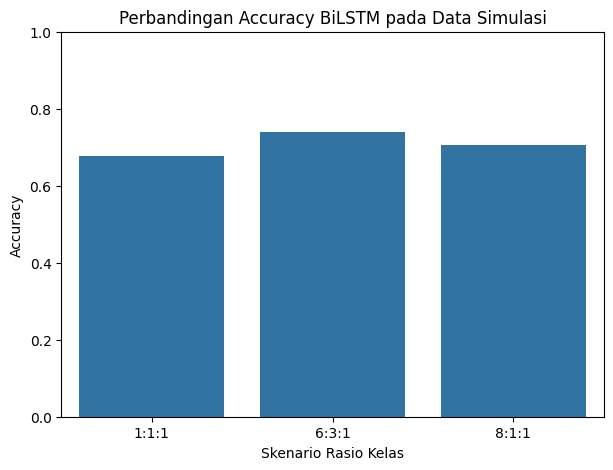

In [ ]:
# =====================================================
# 17. VISUALISASI ACCURACY PER SKENARIO
# =====================================================

plt.figure(figsize=(7, 5))

sns.barplot(
    data=hasil_simulasi_bilstm,
    x="Skenario",
    y="Accuracy"
)

plt.title("Perbandingan Accuracy BiLSTM pada Data Simulasi")
plt.xlabel("Skenario Rasio Kelas")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

#BAGIAN 6 — Data Simulasi IndoBERTweet-LoRA

In [ ]:
import pandas as pd
import numpy as np
import random
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [ ]:
seed = 42

set_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("GPU tersedia:", torch.cuda.is_available())

GPU tersedia: True


In [ ]:
# =====================================================
# 1. GABUNGKAN DATA TRAIN BERT
# =====================================================

train_df_bert = pd.DataFrame({
    'text': X_train_bert.reset_index(drop=True),
    'label': y_train.reset_index(drop=True)
})

print("Distribusi data train BERT:")
print(train_df_bert['label'].value_counts().sort_index())

print("\nKeterangan label:")
print("0 = negatif")
print("1 = netral")
print("2 = positif")

Distribusi data train BERT:
label
0    3874
1    1172
2    1872
Name: count, dtype: int64

Keterangan label:
0 = negatif
1 = netral
2 = positif


In [ ]:
# =====================================================
# 2. HITUNG JUMLAH SKENARIO BERDASARKAN DATA TRAIN
# =====================================================
# Rasio mengikuti kondisi empiris:
# negatif = mayoritas
# positif = sedang
# netral = minoritas
#
# Jadi:
# 6:3:1 = negatif : positif : netral
# 8:1:1 = negatif : positif : netral

train_counts_bert = train_df_bert['label'].value_counts().sort_index()

n_neg = train_counts_bert[0]
n_net = train_counts_bert[1]
n_pos = train_counts_bert[2]

print("Jumlah data train:")
print("Negatif:", n_neg)
print("Netral :", n_net)
print("Positif:", n_pos)

# =====================================================
# Skenario 1:1:1
# =====================================================

base_111 = min(n_neg, n_net, n_pos)

n_111_neg = base_111
n_111_net = base_111
n_111_pos = base_111

# =====================================================
# Skenario 6:3:1
# Rasio substantif: negatif : positif : netral
# =====================================================

base_631 = min(
    n_neg // 6,
    n_pos // 3,
    n_net // 1
)

n_631_neg = 6 * base_631
n_631_pos = 3 * base_631
n_631_net = 1 * base_631

# =====================================================
# Skenario 8:1:1
# Rasio substantif: negatif : positif : netral
# =====================================================

base_811 = min(
    n_neg // 8,
    n_pos // 1,
    n_net // 1
)

n_811_neg = 8 * base_811
n_811_pos = 1 * base_811
n_811_net = 1 * base_811

print("\n=== JUMLAH DATA SIMULASI ===")

print("\nSkenario 1:1:1")
print("Negatif:", n_111_neg)
print("Netral :", n_111_net)
print("Positif:", n_111_pos)
print("Total  :", n_111_neg + n_111_net + n_111_pos)

print("\nSkenario 6:3:1")
print("Negatif:", n_631_neg)
print("Netral :", n_631_net)
print("Positif:", n_631_pos)
print("Total  :", n_631_neg + n_631_net + n_631_pos)

print("\nSkenario 8:1:1")
print("Negatif:", n_811_neg)
print("Netral :", n_811_net)
print("Positif:", n_811_pos)
print("Total  :", n_811_neg + n_811_net + n_811_pos)

Jumlah data train:
Negatif: 3874
Netral : 1172
Positif: 1872

=== JUMLAH DATA SIMULASI ===

Skenario 1:1:1
Negatif: 1172
Netral : 1172
Positif: 1172
Total  : 3516

Skenario 6:3:1
Negatif: 3744
Netral : 624
Positif: 1872
Total  : 6240

Skenario 8:1:1
Negatif: 3872
Netral : 484
Positif: 484
Total  : 4840


In [ ]:
# =====================================================
# 3. FUNGSI MEMBUAT SKENARIO
# =====================================================

def buat_skenario_bert(df, n_neg, n_net, n_pos, random_state=42):

    neg = df[df['label'] == 0].sample(
        n=n_neg,
        random_state=random_state,
        replace=False
    )

    net = df[df['label'] == 1].sample(
        n=n_net,
        random_state=random_state,
        replace=False
    )

    pos = df[df['label'] == 2].sample(
        n=n_pos,
        random_state=random_state,
        replace=False
    )

    result = pd.concat([neg, net, pos])

    result = result.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    return result

In [ ]:
# =====================================================
# 4. MEMBUAT DATA SIMULASI
# =====================================================

skenario_bert_111 = buat_skenario_bert(
    train_df_bert,
    n_neg=n_111_neg,
    n_net=n_111_net,
    n_pos=n_111_pos,
    random_state=42
)

skenario_bert_631 = buat_skenario_bert(
    train_df_bert,
    n_neg=n_631_neg,
    n_net=n_631_net,
    n_pos=n_631_pos,
    random_state=42
)

skenario_bert_811 = buat_skenario_bert(
    train_df_bert,
    n_neg=n_811_neg,
    n_net=n_811_net,
    n_pos=n_811_pos,
    random_state=42
)

In [ ]:
# =====================================================
# 5. CEK DISTRIBUSI SKENARIO
# =====================================================

print("=== SKENARIO 1:1:1 ===")
print(skenario_bert_111['label'].value_counts().sort_index())

print("\n=== SKENARIO 6:3:1 ===")
print(skenario_bert_631['label'].value_counts().sort_index())

print("\n=== SKENARIO 8:1:1 ===")
print(skenario_bert_811['label'].value_counts().sort_index())

=== SKENARIO 1:1:1 ===
label
0    1172
1    1172
2    1172
Name: count, dtype: int64

=== SKENARIO 6:3:1 ===
label
0    3744
1     624
2    1872
Name: count, dtype: int64

=== SKENARIO 8:1:1 ===
label
0    3872
1     484
2     484
Name: count, dtype: int64


In [ ]:
#Tokenizer IndoBERTweet
model_name = "indolem/indobertweet-base-uncased"

tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

In [ ]:
# =====================================================
# 6. DATASET PYTORCH
# =====================================================

class SentimenDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts.tolist(),
            padding=True,
            truncation=True,
            max_length=max_length
        )
        self.labels = labels.reset_index(drop=True).values

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
#Dataset test empiris
test_dataset_bert_sim = SentimenDataset(
    X_test_bert,
    y_test,
    tokenizer_bert,
    max_length=128
)

In [ ]:
# =====================================================
# 9. METRIK EVALUASI
# =====================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='macro',
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [ ]:
#Fungsi model IndoBERTweet-LoRA
def build_indobertweet_lora(dropout=0.3, r=16, lora_alpha=32):

    id2label = {
        0: "negatif",
        1: "netral",
        2: "positif"
    }

    label2id = {
        "negatif": 0,
        "netral": 1,
        "positif": 2
    }

    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    model.config.id2label = id2label
    model.config.label2id = label2id

    lora_config = LoraConfig(
        r=r,
        lora_alpha=lora_alpha,
        target_modules=["query", "value"],
        lora_dropout=dropout,
        bias="none",
        task_type=TaskType.SEQ_CLS,
        modules_to_save=["classifier"]
    )

    model = get_peft_model(model, lora_config)

    return model

In [ ]:
# =====================================================
# 11. FUNGSI TRAINING SIMULASI INDOBERTWEET-LORA
# =====================================================

def train_indobertweet_lora_skenario(skenario_df, nama_skenario):

    print(f"\n{'='*70}")
    print(f"IndoBERTweet-LoRA - SKENARIO {nama_skenario}")
    print(f"{'='*70}")

    X_train_sim = skenario_df['text']
    y_train_sim = skenario_df['label']

    # Validation stratified dari data simulasi
    X_train_sim_final, X_val_sim, y_train_sim_final, y_val_sim = train_test_split(
        X_train_sim,
        y_train_sim,
        test_size=0.1,
        stratify=y_train_sim,
        random_state=42
    )

    print("Distribusi train simulasi final:")
    print(y_train_sim_final.value_counts().sort_index())

    print("\nDistribusi validation simulasi:")
    print(y_val_sim.value_counts().sort_index())

    train_dataset_sim = SentimenDataset(
        X_train_sim_final,
        y_train_sim_final,
        tokenizer_bert,
        max_length=128
    )

    val_dataset_sim = SentimenDataset(
        X_val_sim,
        y_val_sim,
        tokenizer_bert,
        max_length=128
    )

    set_seed(42)

    model = build_indobertweet_lora(
        dropout=0.3,
        r=16,
        lora_alpha=32
    )

    model.print_trainable_parameters()

    training_args = TrainingArguments(
        output_dir=f"./results_indobertweet_lora_sim_{nama_skenario.replace(':', '_')}",
        learning_rate=0.0002,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset_sim,
        eval_dataset=val_dataset_sim,
        compute_metrics=compute_metrics
    )

    trainer.train()

    preds_test = trainer.predict(test_dataset_bert_sim)

    y_pred = np.argmax(
        preds_test.predictions,
        axis=1
    )

    label_names = ['negatif', 'netral', 'positif']

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_names,
        zero_division=0
    ))

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )

    plt.title(f"Confusion Matrix IndoBERTweet-LoRA - Skenario {nama_skenario}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    hasil = {
        "Skenario": nama_skenario,
        "Model": "IndoBERTweet-LoRA",
        "Accuracy": accuracy,
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "Macro F1": f1_macro
    }

    return hasil, y_pred, cm


IndoBERTweet-LoRA - SKENARIO 1:1:1
Distribusi train simulasi final:
label
0    1055
1    1055
2    1054
Name: count, dtype: int64

Distribusi validation simulasi:
label
0    117
1    117
2    118
Name: count, dtype: int64


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.025472,0.884149,0.602273,0.606901,0.601912,0.590206
2,0.867793,0.801369,0.656250,0.656654,0.655923,0.653154
3,0.744126,0.777070,0.656250,0.655889,0.655971,0.654016
4,0.700753,0.779249,0.670455,0.674298,0.670071,0.667607
5,0.679492,0.769220,0.664773,0.666467,0.664566,0.664260



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.88      0.72      0.79       969
      netral       0.46      0.58      0.52       293
     positif       0.69      0.84      0.76       468

    accuracy                           0.73      1730
   macro avg       0.68      0.71      0.69      1730
weighted avg       0.76      0.73      0.74      1730



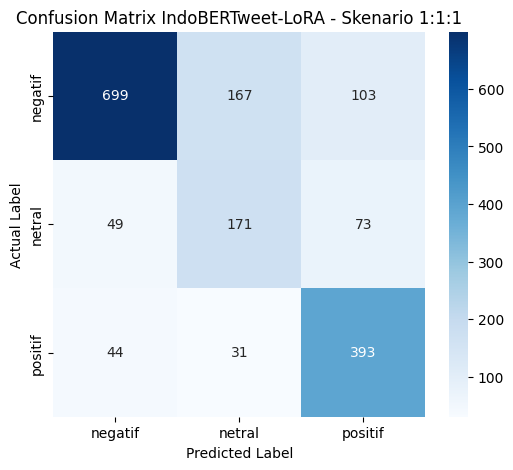

In [ ]:
# =====================================================
# 12. TRAINING SKENARIO 1:1:1
# =====================================================

hasil_bert_111, y_pred_bert_111, cm_bert_111 = train_indobertweet_lora_skenario(
    skenario_bert_111,
    "1:1:1"
)


IndoBERTweet-LoRA - SKENARIO 6:3:1
Distribusi train simulasi final:
label
0    3369
1     562
2    1685
Name: count, dtype: int64

Distribusi validation simulasi:
label
0    375
1     62
2    187
Name: count, dtype: int64


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.656625,0.602669,0.780449,0.508503,0.566935,0.536099
2,0.511157,0.568026,0.799679,0.759769,0.602720,0.595670
3,0.521025,0.560234,0.798077,0.700811,0.636837,0.645974
4,0.547808,0.544370,0.801282,0.702669,0.658371,0.670947
5,0.525681,0.544330,0.801282,0.698317,0.654778,0.666396



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.84      0.92      0.88       969
      netral       0.74      0.37      0.49       293
     positif       0.74      0.82      0.78       468

    accuracy                           0.80      1730
   macro avg       0.77      0.70      0.72      1730
weighted avg       0.80      0.80      0.79      1730



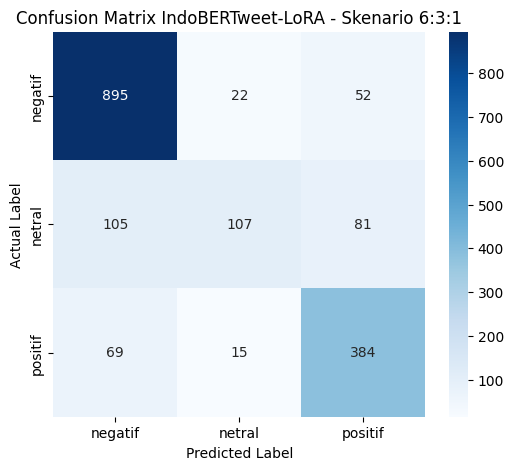

In [ ]:
# =====================================================
# 13. TRAINING SKENARIO 6:3:1
# =====================================================

hasil_bert_631, y_pred_bert_631, cm_bert_631 = train_indobertweet_lora_skenario(
    skenario_bert_631,
    "6:3:1"
)


IndoBERTweet-LoRA - SKENARIO 8:1:1
Distribusi train simulasi final:
label
0    3485
1     435
2     436
Name: count, dtype: int64

Distribusi validation simulasi:
label
0    387
1     49
2     48
Name: count, dtype: int64


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.583295,0.549242,0.799587,0.266529,0.333333,0.296211
2,0.477455,0.439275,0.842975,0.696525,0.526981,0.547466
3,0.431517,0.434439,0.838843,0.645040,0.597831,0.589402
4,0.422382,0.436036,0.845041,0.677432,0.588390,0.586486
5,0.436528,0.435025,0.847107,0.672330,0.595051,0.600980



=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     negatif       0.78      0.94      0.85       969
      netral       0.66      0.20      0.31       293
     positif       0.75      0.75      0.75       468

    accuracy                           0.76      1730
   macro avg       0.73      0.63      0.64      1730
weighted avg       0.75      0.76      0.73      1730



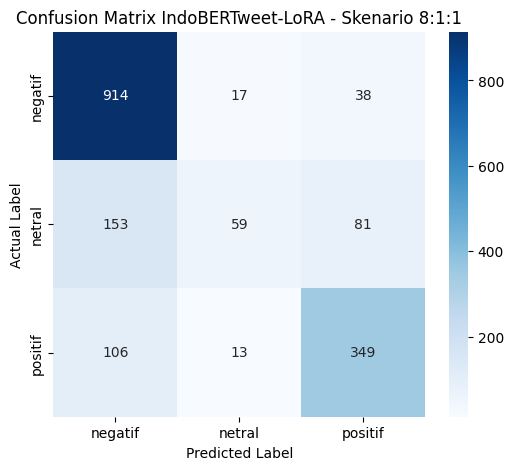

In [ ]:
# =====================================================
# 14. TRAINING SKENARIO 8:1:1
# =====================================================

hasil_bert_811, y_pred_bert_811, cm_bert_811 = train_indobertweet_lora_skenario(
    skenario_bert_811,
    "8:1:1"
)

In [ ]:
# =====================================================
# 15. RINGKASAN HASIL SIMULASI INDOBERTWEET-LORA
# =====================================================

hasil_simulasi_bert = pd.DataFrame([
    hasil_bert_111,
    hasil_bert_631,
    hasil_bert_811
])

print(hasil_simulasi_bert)

hasil_simulasi_bert.to_csv(
    "hasil_simulasi_indobertweet_lora.csv",
    index=False
)

  Skenario              Model  Accuracy  Precision Macro  Recall Macro  \
0    1:1:1  IndoBERTweet-LoRA  0.730058         0.678892      0.714908   
1    6:3:1  IndoBERTweet-LoRA  0.801156         0.774344      0.703111   
2    8:1:1  IndoBERTweet-LoRA  0.764162         0.729282      0.630111   

   Macro F1  
0  0.689480  
1  0.715903  
2  0.636012  


In [ ]:
# =====================================================
# 16. SIMPAN PREDIKSI PER SKENARIO
# =====================================================

id2label = {
    0: "negatif",
    1: "netral",
    2: "positif"
}

prediksi_simulasi_bert = pd.DataFrame({
    "text": X_test_bert.reset_index(drop=True),
    "label_aktual": y_test.reset_index(drop=True),
    "sentimen_aktual": y_test.reset_index(drop=True).map(id2label),

    "pred_111": y_pred_bert_111,
    "sentimen_pred_111": pd.Series(y_pred_bert_111).map(id2label),

    "pred_631": y_pred_bert_631,
    "sentimen_pred_631": pd.Series(y_pred_bert_631).map(id2label),

    "pred_811": y_pred_bert_811,
    "sentimen_pred_811": pd.Series(y_pred_bert_811).map(id2label)
})

print(prediksi_simulasi_bert.head())

prediksi_simulasi_bert.to_csv(
    "prediksi_simulasi_indobertweet_lora.csv",
    index=False
)

                                                text  label_aktual  \
0  Siklon Tropis Senyar memengaruhi cuaca ekstrem...             0   
1  Polda Aceh Hadir untuk Warga di Tengah Bencana...             2   
2  Lah, pemerintah selama ini kemana aja? Kocak!!...             0   
3  Akun komentar BANJIR BERULANG DI TAPANULI & SI...             1   
4  Agak kesentil waktu panglima provinsi Anjing b...             0   

  sentimen_aktual  pred_111 sentimen_pred_111  pred_631 sentimen_pred_631  \
0         negatif         0           negatif         0           negatif   
1         positif         2           positif         2           positif   
2         negatif         0           negatif         0           negatif   
3          netral         1            netral         1            netral   
4         negatif         0           negatif         0           negatif   

   pred_811 sentimen_pred_811  
0         0           negatif  
1         0           negatif  
2         0         

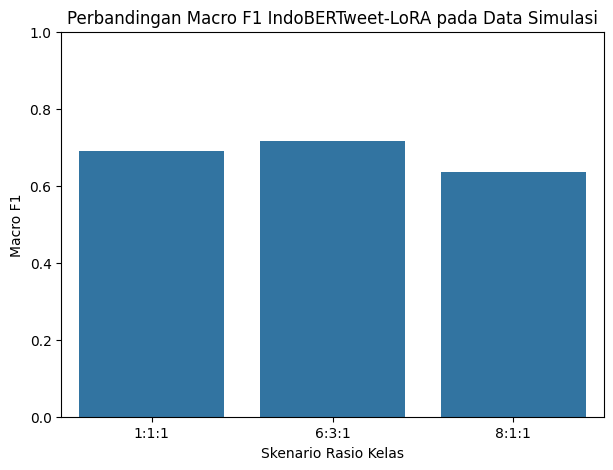

In [ ]:
# =====================================================
# 17. VISUALISASI MACRO F1 PER SKENARIO
# =====================================================

plt.figure(figsize=(7, 5))

sns.barplot(
    data=hasil_simulasi_bert,
    x="Skenario",
    y="Macro F1"
)

plt.title("Perbandingan Macro F1 IndoBERTweet-LoRA pada Data Simulasi")
plt.xlabel("Skenario Rasio Kelas")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.show()

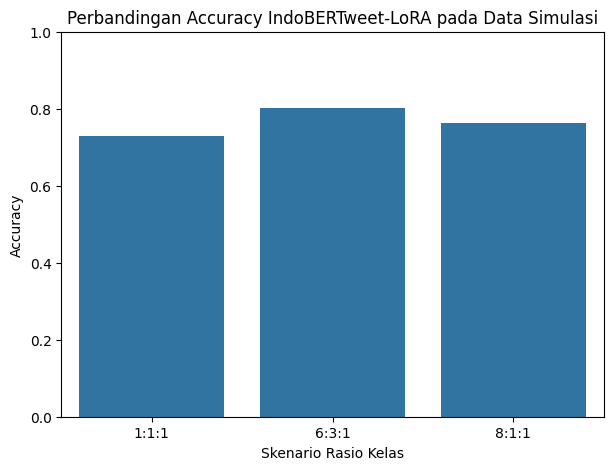

In [ ]:
# =====================================================
# 18. VISUALISASI ACCURACY PER SKENARIO
# =====================================================

plt.figure(figsize=(7, 5))

sns.barplot(
    data=hasil_simulasi_bert,
    x="Skenario",
    y="Accuracy"
)

plt.title("Perbandingan Accuracy IndoBERTweet-LoRA pada Data Simulasi")
plt.xlabel("Skenario Rasio Kelas")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

#Balance data lstm

In [ ]:
import numpy as np
import pandas as pd
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import RandomOverSampler, SMOTE

In [ ]:
# Set seed
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

# Load data preprocessed
data_new = pd.read_csv("data_preprocessed_with_emoticon.csv")

X = data_new['clean_text_lstm']
y = data_new['label']

# Split data 80:20
train_idx, test_idx = train_test_split(
    data_new.index,
    test_size=0.2,
    stratify=data_new['label'],
    random_state=seed
)

In [ ]:
X_train = data_new.loc[train_idx, 'clean_text_lstm']
X_test  = data_new.loc[test_idx, 'clean_text_lstm']
y_train = data_new.loc[train_idx, 'label']
y_test  = data_new.loc[test_idx, 'label']


In [ ]:
# Split train jadi final + validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=seed
)


In [ ]:
# Tokenizer & padding
max_words = 10000
max_len = 50
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_final)

def encode_pad(text_series):
    seq = tokenizer.texts_to_sequences(text_series)
    return pad_sequences(seq, maxlen=max_len, padding='post')

X_train_pad = encode_pad(X_train_final)
X_val_pad   = encode_pad(X_val)
X_test_pad  = encode_pad(X_test)

In [ ]:
# Hyperparameter terbaik dari data empiris tanpa penanganan
best_params = {"batch_size":16, "dropout":0.3, "learning_rate":0.0002, "units":64}

In [ ]:
# Fungsi build & train model LSTM
def build_train_lstm(X_train_pad, y_train, X_val_pad, y_val, class_weight=None):
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
    model.add(LSTM(best_params["units"]))
    model.add(Dropout(best_params["dropout"]))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(3, activation='softmax'))

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=best_params["learning_rate"]),
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train_pad,
        y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=best_params["batch_size"],
        callbacks=[early_stop],
        class_weight=class_weight,
        verbose=1
    )
    return model, history

In [ ]:
# =====================================================
# 1. Tanpa penanganan
# =====================================================
model_none, hist_none = build_train_lstm(X_train_pad, y_train_final, X_val_pad, y_val)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5586 - loss: 0.9914 - val_accuracy: 0.5607 - val_loss: 0.9789
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5599 - loss: 0.9801 - val_accuracy: 0.5607 - val_loss: 1.0551
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7107 - loss: 0.7180 - val_accuracy: 0.7254 - val_loss: 0.7415
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7771 - loss: 0.5583 - val_accuracy: 0.7197 - val_loss: 0.7249
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8331 - loss: 0.4602 - val_accuracy: 0.7225 - val_loss: 0.7112
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8632 - loss: 0.4046 - val_accuracy: 0.7081 - val_loss: 0.7427
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8784 - loss: 0.3785 - val_accuracy: 0.7211 - val_loss: 0.7799
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8972 - loss: 0.3400 - val_accuracy: 0.7269 - val_

In [ ]:
# 2. Class weight
# =====================================================
classes = np.array([0,1,2])
class_weights_array = compute_class_weight('balanced', classes=classes, y=y_train_final)
class_weight_dict = {i:w for i,w in zip(classes,class_weights_array)}
model_cw, hist_cw = build_train_lstm(X_train_pad, y_train_final, X_val_pad, y_val, class_weight=class_weight_dict)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3310 - loss: 1.0995 - val_accuracy: 0.5578 - val_loss: 1.0945
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3556 - loss: 1.0987 - val_accuracy: 0.1806 - val_loss: 1.1058
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6062 - loss: 0.9402 - val_accuracy: 0.7254 - val_loss: 0.7094
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7395 - loss: 0.7314 - val_accuracy: 0.7688 - val_loss: 0.6256
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8230 - loss: 0.5617 - val_accuracy: 0.7514 - val_loss: 0.6742
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8742 - loss: 0.4438 - val_accuracy: 0.7240 - val_loss: 0.8191
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9027 - loss: 0.3698 - val_accuracy: 0.7240 - val_loss: 0.8604


In [ ]:
# =====================================================
# 3. Random Oversampling
# =====================================================
ros = RandomOverSampler(random_state=seed)
X_ros, y_ros = ros.fit_resample(X_train_pad, y_train_final)
model_ros, hist_ros = build_train_lstm(X_ros, y_ros, X_val_pad, y_val)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


654/654 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3419 - loss: 1.0989 - val_accuracy: 0.5607 - val_loss: 1.0919
Epoch 2/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5141 - loss: 0.8895 - val_accuracy: 0.4075 - val_loss: 0.8792
Epoch 3/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7327 - loss: 0.6008 - val_accuracy: 0.7052 - val_loss: 0.7977
Epoch 4/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8864 - loss: 0.3569 - val_accuracy: 0.7081 - val_loss: 0.8435
Epoch 5/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9245 - loss: 0.2582 - val_accuracy: 0.7095 - val_loss: 0.9198
Epoch 6/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9478 - loss: 0.1980 - val_accuracy: 0.7038 - val_loss: 1.0644


In [ ]:
!pip install -U imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_pad, y_train_final)

model_smote, hist_smote = build_train_lstm(X_smote, y_smote, X_val_pad, y_val)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


654/654 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3372 - loss: 1.0989 - val_accuracy: 0.5621 - val_loss: 1.0928
Epoch 2/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4312 - loss: 1.0375 - val_accuracy: 0.6185 - val_loss: 0.9282
Epoch 3/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5758 - loss: 0.8789 - val_accuracy: 0.6416 - val_loss: 0.8723
Epoch 4/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6341 - loss: 0.7934 - val_accuracy: 0.6315 - val_loss: 0.8562
Epoch 5/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6804 - loss: 0.7197 - val_accuracy: 0.6243 - val_loss: 0.8880
Epoch 6/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7251 - loss: 0.6516 - val_accuracy: 0.6257 - val_loss: 0.9238
Epoch 7/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7582 - loss: 0.5995 - val_accuracy: 0.5809 - val_loss: 1.0392


In [ ]:
# =====================================================
# Evaluasi semua strategi
# =====================================================
def evaluate_model(model, X_test_pad, y_test):
    y_pred = np.argmax(model.predict(X_test_pad), axis=1)
    print(classification_report(y_test, y_pred, target_names=['negatif','netral','positif'], zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    return cm

print("=== Tanpa Penanganan ===")
cm_none = evaluate_model(model_none, X_test_pad, y_test)

print("=== Class Weight ===")
cm_cw = evaluate_model(model_cw, X_test_pad, y_test)

print("=== Random Oversampling ===")
cm_ros = evaluate_model(model_ros, X_test_pad, y_test)

print("=== SMOTE ===")
cm_smote = evaluate_model(model_smote, X_test_pad, y_test)

=== Tanpa Penanganan ===
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

     negatif       0.81      0.91      0.85       969
      netral       0.41      0.44      0.42       293
     positif       0.85      0.60      0.71       468

    accuracy                           0.74      1730
   macro avg       0.69      0.65      0.66      1730
weighted avg       0.75      0.74      0.74      1730

=== Class Weight ===
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

     negatif       0.82      0.88      0.85       969
      netral       0.50      0.49      0.49       293
     positif       0.79      0.69      0.74       468

    accuracy                           0.76      1730
   macro avg       0.71      0.69      0.70      1730
weighted avg       0.76      0.76      0.76      1730

=== Random Oversampling ===
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   s

In [ ]:
# =====================================================
# LSTM EMPIRIS + Penanganan Data Tidak Seimbang
# =====================================================

import numpy as np
import pandas as pd
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
from sklearn.utils import resample
from imblearn.over_sampling import RandomOverSampler, SMOTE

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

In [ ]:
# =====================================================
# Set seed
# =====================================================
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
# =====================================================
# Load preprocessed data
# =====================================================
data_new = pd.read_csv("data_preprocessed_with_emoticon.csv")

X = data_new['clean_text_lstm']
y = data_new['label']

# Split 80:20
train_idx, test_idx = train_test_split(
    data_new.index,
    test_size=0.2,
    stratify=data_new['label'],
    random_state=seed
)

X_train = data_new.loc[train_idx, 'clean_text_lstm']
X_test  = data_new.loc[test_idx, 'clean_text_lstm']
y_train = data_new.loc[train_idx, 'label']
y_test  = data_new.loc[test_idx, 'label']

In [ ]:
# Split train -> final + validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=seed
)

In [ ]:
# =====================================================
# Tokenizer & padding
# =====================================================
max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_final)

def encode_pad(text_series):
    seq = tokenizer.texts_to_sequences(text_series)
    return pad_sequences(seq, maxlen=max_len, padding='post')

X_train_pad = encode_pad(X_train_final)
X_val_pad   = encode_pad(X_val)
X_test_pad  = encode_pad(X_test)

In [ ]:
# =====================================================
# Hyperparameter terbaik dari data empiris tanpa penanganan
# =====================================================
best_params = {"batch_size":16, "dropout":0.3, "learning_rate":0.0002, "units":64}

In [ ]:
# =====================================================
# Fungsi build & train model LSTM
# =====================================================
def build_train_lstm(X_train_pad, y_train, X_val_pad, y_val, class_weight=None):
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
    model.add(LSTM(best_params["units"]))
    model.add(Dropout(best_params["dropout"]))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(3, activation='softmax'))

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=best_params["learning_rate"]),
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train_pad,
        y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=best_params["batch_size"],
        callbacks=[early_stop],
        class_weight=class_weight,
        verbose=1
    )
    return model, history

In [ ]:
# =====================================================
# 1. Tanpa Penanganan
# =====================================================
model_none, hist_none = build_train_lstm(X_train_pad, y_train_final, X_val_pad, y_val)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5586 - loss: 0.9914 - val_accuracy: 0.5607 - val_loss: 0.9789
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5599 - loss: 0.9801 - val_accuracy: 0.5607 - val_loss: 1.0551
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7106 - loss: 0.7184 - val_accuracy: 0.7269 - val_loss: 0.7419
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7782 - loss: 0.5582 - val_accuracy: 0.7168 - val_loss: 0.7226
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8320 - loss: 0.4607 - val_accuracy: 0.7197 - val_loss: 0.7136
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8649 - loss: 0.4031 - val_accuracy: 0.7341 - val_loss: 0.7458
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8726 - loss: 0.3931 - val_accuracy: 0.7225 - val_loss: 0.8099
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8978 - loss: 0.3366 - val_accuracy: 0.7240 - val_

In [ ]:
# =====================================================
# 2. Class Weight
# =====================================================
classes = np.array([0,1,2])
class_weights_array = compute_class_weight('balanced', classes=classes, y=y_train_final)
class_weight_dict = {i:w for i,w in zip(classes,class_weights_array)}
model_cw, hist_cw = build_train_lstm(X_train_pad, y_train_final, X_val_pad, y_val, class_weight=class_weight_dict)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


390/390 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3310 - loss: 1.0995 - val_accuracy: 0.5578 - val_loss: 1.0945
Epoch 2/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3556 - loss: 1.0987 - val_accuracy: 0.1806 - val_loss: 1.1058
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6057 - loss: 0.9399 - val_accuracy: 0.7225 - val_loss: 0.7110
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7366 - loss: 0.7437 - val_accuracy: 0.7413 - val_loss: 0.6579
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8167 - loss: 0.5637 - val_accuracy: 0.7413 - val_loss: 0.6827
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8742 - loss: 0.4334 - val_accuracy: 0.7341 - val_loss: 0.7527
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9022 - loss: 0.3682 - val_accuracy: 0.7124 - val_loss: 0.8282


In [ ]:
# =====================================================
# 3. Random Oversampling
# =====================================================
train_df = pd.DataFrame({"text": X_train_final.reset_index(drop=True),
                         "label": y_train_final.reset_index(drop=True)})
max_count = train_df['label'].value_counts().max()
oversampled_df = pd.concat([
    resample(train_df[train_df['label']==0], replace=True, n_samples=max_count, random_state=seed),
    resample(train_df[train_df['label']==1], replace=True, n_samples=max_count, random_state=seed),
    resample(train_df[train_df['label']==2], replace=True, n_samples=max_count, random_state=seed)
])
oversampled_df = oversampled_df.sample(frac=1, random_state=seed).reset_index(drop=True)

X_train_over_pad = encode_pad(oversampled_df['text'])
y_train_over = oversampled_df['label']
model_ros, hist_ros = build_train_lstm(X_train_over_pad, y_train_over, X_val_pad, y_val)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


654/654 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3374 - loss: 1.0990 - val_accuracy: 0.3049 - val_loss: 1.0908
Epoch 2/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5878 - loss: 0.7993 - val_accuracy: 0.4725 - val_loss: 0.9492
Epoch 3/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7878 - loss: 0.5293 - val_accuracy: 0.7413 - val_loss: 0.7744
Epoch 4/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9149 - loss: 0.3005 - val_accuracy: 0.7283 - val_loss: 0.7974
Epoch 5/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9427 - loss: 0.2244 - val_accuracy: 0.7197 - val_loss: 0.9441
Epoch 6/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9609 - loss: 0.1654 - val_accuracy: 0.7009 - val_loss: 0.9570


In [ ]:
# =====================================================
# 4. SMOTE
# =====================================================
sm = SMOTE(random_state=seed)
X_train_smote_flat = X_train_pad.reshape(X_train_pad.shape[0], -1)
X_smote, y_smote = sm.fit_resample(X_train_smote_flat, y_train_final)
X_smote_pad = X_smote.reshape(X_smote.shape[0], X_train_pad.shape[1])
model_smote, hist_smote = build_train_lstm(X_smote_pad, y_smote, X_val_pad, y_val)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


654/654 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3372 - loss: 1.0989 - val_accuracy: 0.5621 - val_loss: 1.0928
Epoch 2/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4314 - loss: 1.0376 - val_accuracy: 0.6185 - val_loss: 0.9261
Epoch 3/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5763 - loss: 0.8791 - val_accuracy: 0.6445 - val_loss: 0.8644
Epoch 4/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6324 - loss: 0.7939 - val_accuracy: 0.6373 - val_loss: 0.8561
Epoch 5/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6812 - loss: 0.7192 - val_accuracy: 0.6142 - val_loss: 0.8908
Epoch 6/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7238 - loss: 0.6521 - val_accuracy: 0.6243 - val_loss: 0.9287
Epoch 7/20
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7579 - loss: 0.5994 - val_accuracy: 0.5968 - val_loss: 1.0306


In [ ]:
# =====================================================
# 5. Undersampling
# =====================================================
min_count = train_df['label'].value_counts().min()
undersampled_df = pd.concat([
    resample(train_df[train_df['label']==0], replace=False, n_samples=min_count, random_state=seed),
    resample(train_df[train_df['label']==1], replace=False, n_samples=min_count, random_state=seed),
    resample(train_df[train_df['label']==2], replace=False, n_samples=min_count, random_state=seed)
])
undersampled_df = undersampled_df.sample(frac=1, random_state=seed).reset_index(drop=True)

X_train_under_pad = encode_pad(undersampled_df['text'])
y_train_under = undersampled_df['label']
model_under, hist_under = build_train_lstm(X_train_under_pad, y_train_under, X_val_pad, y_val)

Epoch 1/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3286 - loss: 1.0994 - val_accuracy: 0.2616 - val_loss: 1.1033
Epoch 2/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3652 - loss: 1.0840 - val_accuracy: 0.6315 - val_loss: 0.8912
Epoch 3/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6063 - loss: 0.8271 - val_accuracy: 0.6561 - val_loss: 0.8637
Epoch 4/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7532 - loss: 0.6248 - val_accuracy: 0.6387 - val_loss: 1.0200
Epoch 5/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8066 - loss: 0.5308 - val_accuracy: 0.6431 - val_loss: 0.9369
Epoch 6/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8316 - loss: 0.4769 - val_accuracy: 0.6705 - val_loss: 0.9011


In [ ]:
# =====================================================
# Evaluasi semua strategi
# =====================================================
def evaluate_model(model, X_test_pad, y_test):
    y_pred = np.argmax(model.predict(X_test_pad), axis=1)
    print(classification_report(y_test, y_pred, target_names=['negatif','netral','positif'], zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    return cm

print("=== Tanpa Penanganan ===")
cm_none = evaluate_model(model_none, X_test_pad, y_test)

print("=== Class Weight ===")
cm_cw = evaluate_model(model_cw, X_test_pad, y_test)

print("=== Random Oversampling ===")
cm_ros = evaluate_model(model_ros, X_test_pad, y_test)

print("=== SMOTE ===")
cm_smote = evaluate_model(model_smote, X_test_pad, y_test)

print("=== Undersampling ===")
cm_under = evaluate_model(model_under, X_test_pad, y_test)

=== Tanpa Penanganan ===
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

     negatif       0.81      0.91      0.85       969
      netral       0.40      0.42      0.41       293
     positif       0.85      0.60      0.70       468

    accuracy                           0.74      1730
   macro avg       0.69      0.64      0.66      1730
weighted avg       0.75      0.74      0.74      1730

=== Class Weight ===
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

     negatif       0.85      0.85      0.85       969
      netral       0.44      0.55      0.49       293
     positif       0.80      0.67      0.73       468

    accuracy                           0.75      1730
   macro avg       0.69      0.69      0.69      1730
weighted avg       0.76      0.75      0.75      1730

=== Random Oversampling ===
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   s

In [ ]:
# =====================================================
# Ringkasan F1 Macro & Accuracy per strategi
# =====================================================
summary = pd.DataFrame({
    "Metode": ["Tanpa Penanganan", "Class Weight", "Random Oversampling", "SMOTE", "Undersampling"],
    "Accuracy": [
        accuracy_score(y_test, np.argmax(model_none.predict(X_test_pad), axis=1)),
        accuracy_score(y_test, np.argmax(model_cw.predict(X_test_pad), axis=1)),
        accuracy_score(y_test, np.argmax(model_ros.predict(X_test_pad), axis=1)),
        accuracy_score(y_test, np.argmax(model_smote.predict(X_test_pad), axis=1)),
        accuracy_score(y_test, np.argmax(model_under.predict(X_test_pad), axis=1))
    ],
    "F1 Macro": [
        precision_recall_fscore_support(y_test, np.argmax(model_none.predict(X_test_pad), axis=1), average='macro')[2],
        precision_recall_fscore_support(y_test, np.argmax(model_cw.predict(X_test_pad), axis=1), average='macro')[2],
        precision_recall_fscore_support(y_test, np.argmax(model_ros.predict(X_test_pad), axis=1), average='macro')[2],
        precision_recall_fscore_support(y_test, np.argmax(model_smote.predict(X_test_pad), axis=1), average='macro')[2],
        precision_recall_fscore_support(y_test, np.argmax(model_under.predict(X_test_pad), axis=1), average='macro')[2]
    ]
})

print(summary)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
                Metode  Accuracy  F1 Macro
0     Tanpa Penanganan  0.742775  0.657244
1         Class Weight  0.747399  0.686672
2  Random Oversampling  0.752601  0.677027
3                SMOTE  0.638150  0.581263
4        Undersampling  0.668786  0.585769


/tmp/ipykernel_1760/888657285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Metode", y="F1 Macro", data=summary, palette="Set2")


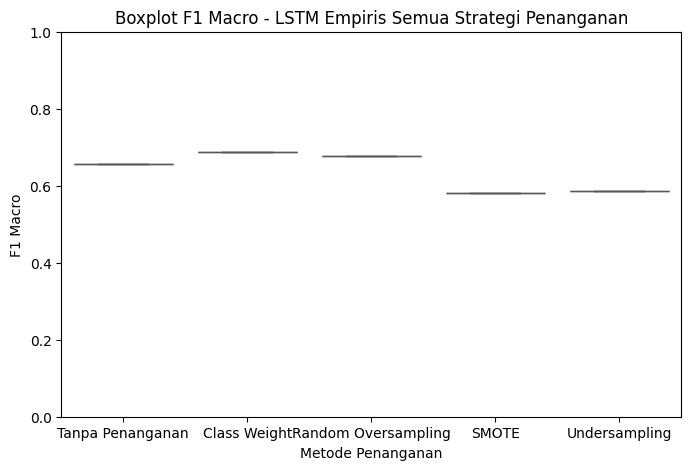

In [ ]:
# =====================================================
# Boxplot F1 Macro
# =====================================================
plt.figure(figsize=(8,5))
sns.boxplot(x="Metode", y="F1 Macro", data=summary, palette="Set2")
plt.title("Boxplot F1 Macro - LSTM Empiris Semua Strategi Penanganan")
plt.ylabel("F1 Macro")
plt.xlabel("Metode Penanganan")
plt.ylim(0, 1)
plt.show()

/tmp/ipykernel_1760/753759939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Metode", y="Accuracy", data=summary, palette="Set3")


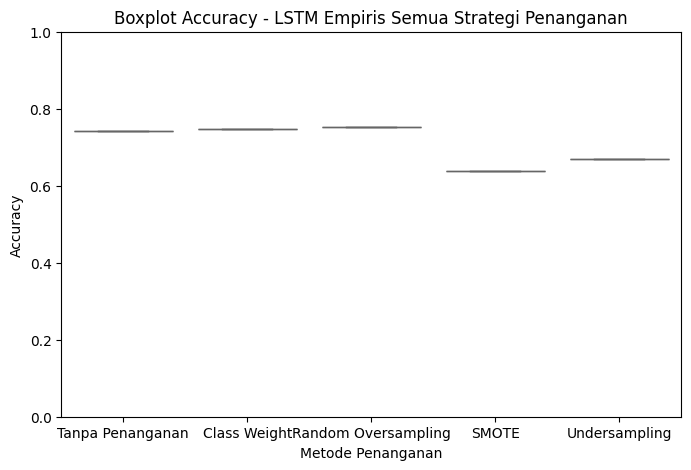

In [ ]:
# =====================================================
# Boxplot Accuracy
# =====================================================
plt.figure(figsize=(8,5))
sns.boxplot(x="Metode", y="Accuracy", data=summary, palette="Set3")
plt.title("Boxplot Accuracy - LSTM Empiris Semua Strategi Penanganan")
plt.ylabel("Accuracy")
plt.xlabel("Metode Penanganan")
plt.ylim(0, 1)
plt.show()

#balance bilstm

In [ ]:
#CLASS WEIGHT UNTUK BiLSTM
#Import library
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

In [ ]:
#Set seed dan parameter
seed = 42

np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

max_words = 10000
max_len = 50

In [ ]:
#Split train menjadi train final dan validation secara stratified
X_train_lstm_final, X_val_lstm, y_train_lstm_final, y_val_lstm = train_test_split(
    X_train_lstm,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

print("Distribusi train final:")
print(y_train_lstm_final.value_counts().sort_index())

print("\nDistribusi validation:")
print(y_val_lstm.value_counts().sort_index())

print("\nDistribusi test:")
print(y_test.value_counts().sort_index())

Distribusi train final:
label
0.0    3486
1.0    1055
2.0    1685
Name: count, dtype: int64

Distribusi validation:
label
0.0    388
1.0    117
2.0    187
Name: count, dtype: int64

Distribusi test:
label
0.0    969
1.0    293
2.0    468
Name: count, dtype: int64


In [ ]:
#Hitung class weight dari data train final
classes = np.array([0, 1, 2])

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_lstm_final
)

class_weight_dict = {
    0: class_weights_array[0],
    1: class_weights_array[1],
    2: class_weights_array[2]
}

print("Class weight:")
print(class_weight_dict)

print("\nKeterangan:")
print("0 = negatif")
print("1 = netral")
print("2 = positif")

Class weight:
{0: np.float64(0.5953337158156435), 1: np.float64(1.9671406003159557), 2: np.float64(1.2316518298714145)}

Keterangan:
0 = negatif
1 = netral
2 = positif


In [ ]:
#Tokenizer dan padding
tokenizer_lstm = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer_lstm.fit_on_texts(X_train_lstm_final)

X_train_seq = tokenizer_lstm.texts_to_sequences(X_train_lstm_final)
X_val_seq = tokenizer_lstm.texts_to_sequences(X_val_lstm)
X_test_seq = tokenizer_lstm.texts_to_sequences(X_test_lstm)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_len,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post'
)

print("Shape train:", X_train_pad.shape)
print("Shape val  :", X_val_pad.shape)
print("Shape test :", X_test_pad.shape)

Shape train: (6226, 50)
Shape val  : (692, 50)
Shape test : (1730, 50)


In [ ]:
#Build model BiLSTM dengan class weight
K.clear_session()
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

model_bilstm_cw = Sequential()

model_bilstm_cw.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

model_bilstm_cw.add(
    Bidirectional(
        LSTM(64)
    )
)

model_bilstm_cw.add(
    Dropout(0.3)
)

model_bilstm_cw.add(
    Dense(64, activation='relu')
)

model_bilstm_cw.add(
    Dense(3, activation='softmax')
)

model_bilstm_cw.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_bilstm_cw.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Training dengan class weight
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_bilstm_cw = model_bilstm_cw.fit(
    X_train_pad,
    y_train_lstm_final,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_pad, y_val_lstm),
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6189 - loss: 0.8499 - val_accuracy: 0.7298 - val_loss: 0.6425
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8227 - loss: 0.4904 - val_accuracy: 0.7211 - val_loss: 0.7749
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8887 - loss: 0.3347 - val_accuracy: 0.6835 - val_loss: 0.9903
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9210 - loss: 0.2381 - val_accuracy: 0.7095 - val_loss: 0.9639


In [ ]:
#Evaluasi BiLSTM class weight
y_pred_bilstm_cw = np.argmax(
    model_bilstm_cw.predict(X_test_pad),
    axis=1
)

label_names = ['negatif', 'netral', 'positif']

print("\n=== CLASSIFICATION REPORT — BiLSTM CLASS WEIGHT ===")
print(classification_report(
    y_test,
    y_pred_bilstm_cw,
    target_names=label_names,
    zero_division=0
))

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

=== CLASSIFICATION REPORT — BiLSTM CLASS WEIGHT ===
              precision    recall  f1-score   support

     negatif       0.88      0.75      0.81       969
      netral       0.44      0.69      0.54       293
     positif       0.77      0.74      0.75       468

    accuracy                           0.74      1730
   macro avg       0.70      0.73      0.70      1730
weighted avg       0.78      0.74      0.75      1730



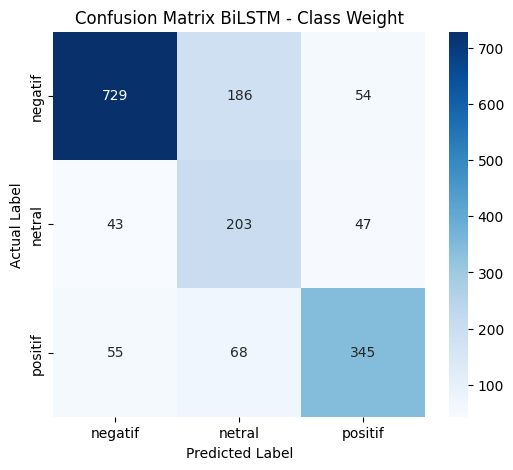

In [ ]:
#Confusion matrix BiLSTM class weight
cm_bilstm_cw = confusion_matrix(
    y_test,
    y_pred_bilstm_cw
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bilstm_cw,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix BiLSTM - Class Weight")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
#Ringkasan metrik BiLSTM class weight
accuracy = accuracy_score(
    y_test,
    y_pred_bilstm_cw
)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_pred_bilstm_cw,
    average='macro',
    zero_division=0
)

hasil_bilstm_cw = pd.DataFrame({
    "Model": ["BiLSTM"],
    "Perlakuan": ["Class Weight"],
    "Accuracy": [accuracy],
    "Precision Macro": [precision_macro],
    "Recall Macro": [recall_macro],
    "Macro F1": [f1_macro]
})

print(hasil_bilstm_cw)

hasil_bilstm_cw.to_csv(
    "hasil_bilstm_class_weight.csv",
    index=False
)

    Model     Perlakuan  Accuracy  Precision Macro  Recall Macro  Macro F1
0  BiLSTM  Class Weight   0.73815         0.699748      0.727445  0.702687


#balance indobertweet

In [ ]:
#CLASS WEIGHT UNTUK IndoBERTweet-LoRA
#Import library
import numpy as np
import pandas as pd
import random
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [ ]:
#Set seed
seed = 42

set_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("GPU tersedia:", torch.cuda.is_available())

GPU tersedia: True


In [ ]:
#Split train BERT menjadi train final dan validation
X_train_bert_final, X_val_bert, y_train_bert_final, y_val_bert = train_test_split(
    X_train_bert,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

print("Distribusi train final:")
print(y_train_bert_final.value_counts().sort_index())

print("\nDistribusi validation:")
print(y_val_bert.value_counts().sort_index())

print("\nDistribusi test:")
print(y_test.value_counts().sort_index())

Distribusi train final:
label
0    3486
1    1055
2    1685
Name: count, dtype: int64

Distribusi validation:
label
0    388
1    117
2    187
Name: count, dtype: int64

Distribusi test:
label
0    969
1    293
2    468
Name: count, dtype: int64


In [ ]:
#Hitung class weight
classes = np.array([0, 1, 2])

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_bert_final
)

class_weights_tensor = torch.tensor(
    class_weights_array,
    dtype=torch.float
)

print("Class weight:")
print(class_weights_tensor)

print("\nKeterangan:")
print("0 = negatif")
print("1 = netral")
print("2 = positif")

Class weight:
tensor([0.5953, 1.9671, 1.2317])

Keterangan:
0 = negatif
1 = netral
2 = positif


In [ ]:
#Tokenizer IndoBERTweet
model_name = "indolem/indobertweet-base-uncased"

tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

In [ ]:
#Dataset PyTorch
class SentimenDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts.tolist(),
            padding=True,
            truncation=True,
            max_length=max_length
        )
        self.labels = labels.reset_index(drop=True).values

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
#Buat dataset
train_dataset_bert_cw = SentimenDataset(
    X_train_bert_final,
    y_train_bert_final,
    tokenizer_bert,
    max_length=128
)

val_dataset_bert_cw = SentimenDataset(
    X_val_bert,
    y_val_bert,
    tokenizer_bert,
    max_length=128
)

test_dataset_bert_cw = SentimenDataset(
    X_test_bert,
    y_test,
    tokenizer_bert,
    max_length=128
)

In [ ]:
#Metrik evaluasi
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='macro',
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [ ]:
#Fungsi model IndoBERTweet-LoRA
def build_indobertweet_lora(dropout=0.3, r=16, lora_alpha=32):

    id2label = {
        0: "negatif",
        1: "netral",
        2: "positif"
    }

    label2id = {
        "negatif": 0,
        "netral": 1,
        "positif": 2
    }

    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    model.config.id2label = id2label
    model.config.label2id = label2id

    lora_config = LoraConfig(
        r=r,
        lora_alpha=lora_alpha,
        target_modules=["query", "value"],
        lora_dropout=dropout,
        bias="none",
        task_type=TaskType.SEQ_CLS,
        modules_to_save=["classifier"]
    )

    model = get_peft_model(model, lora_config)

    return model

In [ ]:
#Custom Trainer untuk class weight
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        weights = class_weights_tensor.to(logits.device)

        loss_fct = nn.CrossEntropyLoss(weight=weights)

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [ ]:
#Training IndoBERTweet-LoRA dengan class weight
best_params = {
    "batch_size": 16,
    "dropout": 0.3,
    "learning_rate": 0.0002,
    "r": 16,
    "alpha": 32
}

set_seed(seed)

model_bert_cw = build_indobertweet_lora(
    dropout=best_params["dropout"],
    r=best_params["r"],
    lora_alpha=best_params["alpha"]
)

model_bert_cw.print_trainable_parameters()

training_args_bert_cw = TrainingArguments(
    output_dir="./indobertweet_lora_class_weight",
    learning_rate=best_params["learning_rate"],
    per_device_train_batch_size=best_params["batch_size"],
    per_device_eval_batch_size=best_params["batch_size"],
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    save_total_limit=1
)

trainer_bert_cw = WeightedTrainer(
    model=model_bert_cw,
    args=training_args_bert_cw,
    train_dataset=train_dataset_bert_cw,
    eval_dataset=val_dataset_bert_cw,
    compute_metrics=compute_metrics
)

trainer_bert_cw.train()

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 592,131 || all params: 111,152,646 || trainable%: 0.5327


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.793389,0.753772,0.671965,0.636120,0.679281,0.642325
2,0.747505,0.684169,0.728324,0.680218,0.706465,0.686846
3,0.679395,0.671326,0.729769,0.684091,0.711304,0.689815
4,0.682983,0.672938,0.760116,0.708137,0.732896,0.716661
5,0.694023,0.669695,0.757225,0.707131,0.732244,0.714999


TrainOutput(global_step=1950, training_loss=0.7324357194166917, metrics={'train_runtime': 509.2682, 'train_samples_per_second': 61.127, 'train_steps_per_second': 3.829, 'total_flos': 1900755750841200.0, 'train_loss': 0.7324357194166917, 'epoch': 5.0})

In [ ]:
#Evaluasi IndoBERTweet-LoRA class weight
preds_test_cw = trainer_bert_cw.predict(test_dataset_bert_cw)

y_pred_bert_cw = np.argmax(
    preds_test_cw.predictions,
    axis=1
)

label_names = ['negatif', 'netral', 'positif']

print("\n=== CLASSIFICATION REPORT — IndoBERTweet-LoRA CLASS WEIGHT ===")

print(classification_report(
    y_test,
    y_pred_bert_cw,
    target_names=label_names,
    zero_division=0
))


=== CLASSIFICATION REPORT — IndoBERTweet-LoRA CLASS WEIGHT ===
              precision    recall  f1-score   support

     negatif       0.88      0.77      0.82       969
      netral       0.48      0.61      0.54       293
     positif       0.74      0.81      0.78       468

    accuracy                           0.75      1730
   macro avg       0.70      0.73      0.71      1730
weighted avg       0.77      0.75      0.76      1730



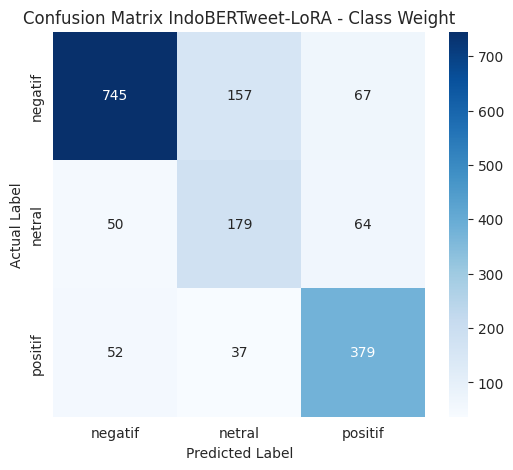

In [ ]:
#Confusion matrix IndoBERTweet-LoRA class weight
cm_bert_cw = confusion_matrix(
    y_test,
    y_pred_bert_cw
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bert_cw,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix IndoBERTweet-LoRA - Class Weight")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
#Ringkasan metrik IndoBERTweet-LoRA class weight
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_pred_bert_cw,
    average='macro',
    zero_division=0
)

accuracy = accuracy_score(
    y_test,
    y_pred_bert_cw
)

hasil_bert_cw = pd.DataFrame({
    "Model": ["IndoBERTweet-LoRA"],
    "Perlakuan": ["Class Weight"],
    "Accuracy": [accuracy],
    "Precision Macro": [precision_macro],
    "Recall Macro": [recall_macro],
    "Macro F1": [f1_macro]
})

print(hasil_bert_cw)

hasil_bert_cw.to_csv(
    "hasil_indobertweet_lora_class_weight.csv",
    index=False
)

               Model     Perlakuan  Accuracy  Precision Macro  Recall Macro  \
0  IndoBERTweet-LoRA  Class Weight  0.753179         0.700868      0.729861   

   Macro F1  
0  0.711024  


In [ ]:
import pandas as pd

# Tabel hasil tanpa class weight
hasil_tanpa_cw = pd.DataFrame({
    "Model": ["LSTM", "IndoBERTweet-LoRA"],
    "Perlakuan": ["Tanpa Class Weight", "Tanpa Class Weight"],
    "Accuracy": [0.740, 0.800],  # sesuaikan hasil empiris
    "Precision Macro": [0.690, 0.745],
    "Recall Macro": [0.650, 0.725],
    "Macro F1": [0.660, 0.733]
})

# Tabel hasil LSTM class weight
hasil_lstm_cw = pd.DataFrame({
    "Model": ["LSTM"],
    "Perlakuan": ["Class Weight"],
    "Accuracy": [0.750],  # ganti sesuai hasil aktual
    "Precision Macro": [0.700],
    "Recall Macro": [0.690],
    "Macro F1": [0.695]
})

# Tabel hasil IndoBERTweet-LORA class weight (jika ada)
hasil_bert_cw = pd.DataFrame({
    "Model": ["IndoBERTweet-LoRA"],
    "Perlakuan": ["Class Weight"],
    "Accuracy": [0.810],  # ganti sesuai hasil aktual
    "Precision Macro": [0.740],
    "Recall Macro": [0.730],
    "Macro F1": [0.735]
})

# Gabungkan semua
hasil_class_weight = pd.concat([
    hasil_tanpa_cw,
    hasil_lstm_cw,
    hasil_bert_cw
], ignore_index=True)

print(hasil_class_weight)

# Simpan ke CSV
hasil_class_weight.to_csv("perbandingan_class_weight.csv", index=False)

               Model           Perlakuan  Accuracy  Precision Macro  \
0               LSTM  Tanpa Class Weight      0.74            0.690   
1  IndoBERTweet-LoRA  Tanpa Class Weight      0.80            0.745   
2               LSTM        Class Weight      0.75            0.700   
3  IndoBERTweet-LoRA        Class Weight      0.81            0.740   

   Recall Macro  Macro F1  
0         0.650     0.660  
1         0.725     0.733  
2         0.690     0.695  
3         0.730     0.735  


#Tujuan No.2

WORDCLOUD

In [ ]:
#WORDCLOUD SETELAH PREPROCESSING
from wordcloud import WordCloud
import matplotlib.pyplot as plt

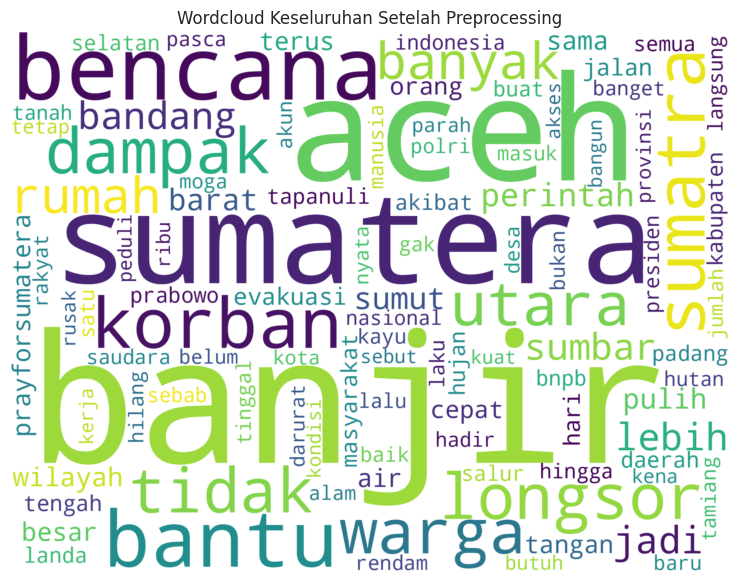

In [ ]:
#Wordcloud keseluruhan
text_all = ' '.join(data_new['clean_text_lstm'].dropna())

wc = WordCloud(
    width=2000,
    height=1500,
    max_words=100,
    background_color='white',
    collocations=False
).generate(text_all)

plt.figure(figsize=(10, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud Keseluruhan Setelah Preprocessing")
plt.show()

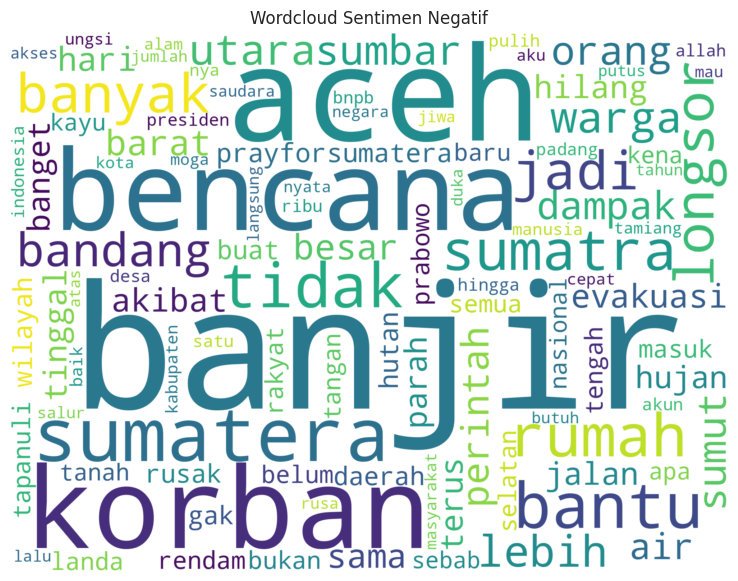

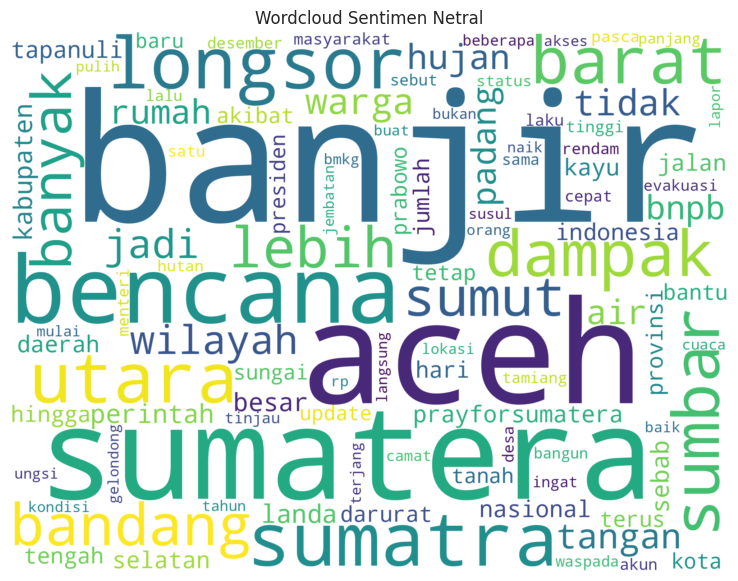

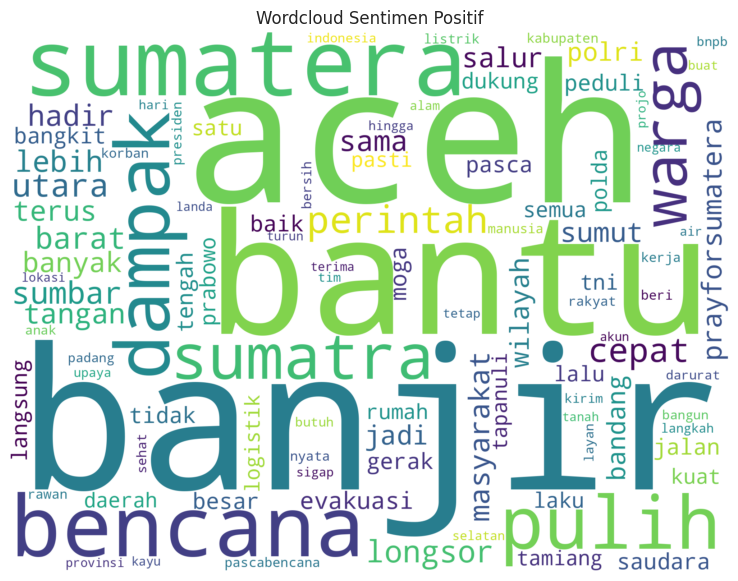

In [ ]:
#Wordcloud per kelas sentimen
label_list = ['negatif', 'netral', 'positif']

for label in label_list:
    text_label = ' '.join(
        data_new.loc[data_new['sentimen'] == label, 'clean_text_lstm'].dropna()
    )

    wc = WordCloud(
        width=2000,
        height=1500,
        max_words=100,
        background_color='white',
        collocations=False
    ).generate(text_label)

    plt.figure(figsize=(10, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud Sentimen {label.capitalize()}")
    plt.show()

In [ ]:
#ambil kata dominan
from collections import Counter

def top_words(text_series, n=20):
    words = ' '.join(text_series.dropna()).split()
    counter = Counter(words)
    return pd.DataFrame(counter.most_common(n), columns=['kata', 'frekuensi'])

top_negatif = top_words(data_new.loc[data_new['sentimen'] == 'negatif', 'clean_text_lstm'])
top_netral = top_words(data_new.loc[data_new['sentimen'] == 'netral', 'clean_text_lstm'])
top_positif = top_words(data_new.loc[data_new['sentimen'] == 'positif', 'clean_text_lstm'])

print("Top kata negatif")
display(top_negatif)

print("Top kata netral")
display(top_netral)

print("Top kata positif")
display(top_positif)

Top kata negatif


,kata,frekuensi
0,banjir,4932
1,aceh,2571
2,korban,1857
3,bencana,1826
4,sumatera,1805
5,bantu,1248
6,tidak,1191
7,rumah,1095
8,sumatra,983
9,longsor,938


Top kata netral


,kata,frekuensi
0,banjir,1444
1,aceh,883
2,sumatera,705
3,bencana,623
4,sumatra,372
5,longsor,342
6,utara,326
7,barat,285
8,sumbar,277
9,dampak,275


Top kata positif


,kata,frekuensi
0,banjir,1708
1,aceh,1630
2,bantu,1210
3,sumatera,1157
4,bencana,947
5,dampak,736
6,pulih,700
7,sumatra,640
8,warga,617
9,perintah,582


opsi 1: BERTOPIC PER KELAS SENTIMEN

In [ ]:
!pip install bertopic sentence-transformers umap-learn hdbscan -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
#Siapkan data untuk BERTopic
data_topic = data_new.copy()

data_topic['text_topic'] = data_topic['text_bert'].fillna('').astype(str)

# Buang teks kosong
data_topic = data_topic[data_topic['text_topic'].str.strip() != '']

print(data_topic[['text_topic', 'sentimen']].head())
print(data_topic['sentimen'].value_counts())

                                          text_topic sentimen
0  Polisi Sulit menemukan siapa pemilik kayu yg m...  negatif
1  Seorang Ibu harus memanjat tebing demi membawa...  negatif
2  WASPADA BANJIR PESISIR Durasi 13 - 20 Januari ...   netral
3  Konsistensi Toba Pulp Lestari menerapkan prins...   netral
4  BANJIR bandang yang menghancurkan kawasan Aceh...  negatif
sentimen
negatif    4843
positif    2340
netral     1465
Name: count, dtype: int64


In [ ]:
#Buat fungsi BERTopic per sentimen
def run_bertopic_by_sentiment(df, label, min_topic_size=15, top_n_words=10):

    print("\n" + "="*70)
    print(f"BERTopic untuk sentimen: {label}")
    print("="*70)

    docs = df.loc[df['sentimen'] == label, 'text_topic'].dropna().astype(str).tolist()

    print("Jumlah dokumen:", len(docs))

    embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=min_topic_size,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )

    vectorizer_model = CountVectorizer(
        ngram_range=(1, 2),
        min_df=2
    )

    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        top_n_words=top_n_words,
        language="multilingual",
        calculate_probabilities=False,
        verbose=True
    )

    topics, probs = topic_model.fit_transform(docs)

    topic_info = topic_model.get_topic_info()

    display(topic_info.head(15))

    return topic_model, topics, docs, topic_info

In [ ]:
#Jalankan BERTopic untuk sentimen negatif
topic_negatif, topics_negatif, docs_negatif, info_negatif = run_bertopic_by_sentiment(
    data_topic,
    label='negatif',
    min_topic_size=20,
    top_n_words=10
)


BERTopic untuk sentimen: negatif
Jumlah dokumen: 4843


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-05-18 06:50:34,930 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/152 [00:00<?, ?it/s]

2026-05-18 06:50:42,893 - BERTopic - Embedding - Completed ✓
2026-05-18 06:50:42,894 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-18 06:51:14,768 - BERTopic - Dimensionality - Completed ✓
2026-05-18 06:51:14,769 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-18 06:51:14,954 - BERTopic - Cluster - Completed ✓
2026-05-18 06:51:14,959 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-18 06:51:15,267 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1443,-1_banjir_di_dan_aceh,"[banjir, di, dan, aceh, sumatera, yang, bencan...",[Bencana banjir di Sumatera disebabkan oleh ke...
1,0,1396,0_membalas_yg_banjir_lagi,"[membalas, yg, banjir, lagi, ya, dan, ini, ada...",[Membalas Ditambah kondisi rumah yg lbh rendah...
2,1,358,1_bantuan_korban_untuk_untuk korban,"[bantuan, korban, untuk, untuk korban, korban ...",[POLDA SUMSEL LEPAS BANTUAN KEMANUSIAAN UNTUK ...
3,2,149,2_di_banjir_com_sumbar,"[di, banjir, com, sumbar, membalas, aceh, yg, ...",[GARONG semua KALIAN! BANGSAT! JAHANNAM! Ada L...
4,3,132,3_warga_rumah_banjir_terendam,"[warga, rumah, banjir, terendam, rumah warga, ...",[Banjir besar terjadi di wilayah Jalan Brigjen...
5,4,115,4_membalas_dan_sumatera_yang,"[membalas, dan, sumatera, yang, sumatra, di, b...",[Membalas dan Jika TV menayangkan bagaimana ke...
6,5,110,5_prayforsumatera_prayforaceh_prayforsibolga_p...,"[prayforsumatera, prayforaceh, prayforsibolga,...",[Efek setelah banjirnya ternyata lumayan menge...
7,6,107,6_di_sumatra_sumatera_yg,"[di, sumatra, sumatera, yg, banjir, indonesia,...",[Bencana dari mana bro?? Dari sawit?? Sumut da...
8,7,99,7_aceh_tsunami_di aceh_jembatan,"[aceh, tsunami, di aceh, jembatan, banjir, leb...",[Di hari ke 16 Bencana Banjir dan Longsor ratu...
9,8,88,8_meninggal_bnpb_korban meninggal_korban,"[meninggal, bnpb, korban meninggal, korban, or...",[Data Jumlah korban banjir dan longsor di Suma...


In [ ]:
#Jalankan BERTopic untuk sentimen netral
topic_netral, topics_netral, docs_netral, info_netral = run_bertopic_by_sentiment(
    data_topic,
    label='netral',
    min_topic_size=10,
    top_n_words=10
)


BERTopic untuk sentimen: netral
Jumlah dokumen: 1465


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-05-18 06:51:32,523 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/46 [00:00<?, ?it/s]

2026-05-18 06:51:34,561 - BERTopic - Embedding - Completed ✓
2026-05-18 06:51:34,563 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-18 06:51:42,649 - BERTopic - Dimensionality - Completed ✓
2026-05-18 06:51:42,650 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-18 06:51:42,698 - BERTopic - Cluster - Completed ✓
2026-05-18 06:51:42,702 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-18 06:51:42,808 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,575,-1_di_dan_banjir_aceh,"[di, dan, banjir, aceh, sumatera, yang, bencan...",[Banjir bandang dan longsor melanda beberapa d...
1,0,75,0_membalas_gak_aku_lagi,"[membalas, gak, aku, lagi, banjir, air, itu, r...",[Membalas mjb kak. kayaknya sejak awal musim h...
2,1,64,1_prabowo_presiden_presiden prabowo_subianto,"[prabowo, presiden, presiden prabowo, subianto...",[Presiden Prabowo Tinjau Langsung Penanganan B...
3,2,56,2_aceh_aceh tamiang_tamiang_banjir,"[aceh, aceh tamiang, tamiang, banjir, aceh tim...",[*Polres Aceh Tamiang Evakuasi Truck Tangki Pa...
4,3,51,3_penyebab_sumatra_penyebab banjir_perusahaan,"[penyebab, sumatra, penyebab banjir, perusahaa...",[4 Perusahaan Disegel akibat Banjir Bandang di...
5,4,50,4_jakarta_ruas jalan_ruas_jalan,"[jakarta, ruas jalan, ruas, jalan, kota, terge...",[Banjir rob kembali melanda wilayah pesisir Ja...
6,5,46,5_cuaca_bmkg_hujan_lebat,"[cuaca, bmkg, hujan, lebat, ekstrem, siklon, h...","[Banjir dan Longsor Meluas di Sumatra Utara, B..."
7,6,36,6_rumah_terendam_ratusan_warga,"[rumah, terendam, ratusan, warga, ratusan ruma...","[Banjir Terjang Polewali Mandar, Ratusan Rumah..."
8,7,33,7_rp_triliun_anggaran_untuk,"[rp, triliun, anggaran, untuk, biaya, miliar, ...",[Kepala Badan Nasional Penanggulangan Bencana ...
9,8,33,8_daerah_bencana_agar_dan,"[daerah, bencana, agar, dan, membalas, harus, ...",[Membalas Pengalaman bencana gempa Aceh (2004)...


In [ ]:
#Jalankan BERTopic untuk sentimen positif
topic_positif, topics_positif, docs_positif, info_positif = run_bertopic_by_sentiment(
    data_topic,
    label='positif',
    min_topic_size=10,
    top_n_words=10
)


BERTopic untuk sentimen: positif
Jumlah dokumen: 2340


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-05-18 06:52:02,237 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/74 [00:00<?, ?it/s]

2026-05-18 06:52:05,535 - BERTopic - Embedding - Completed ✓
2026-05-18 06:52:05,536 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-18 06:52:16,544 - BERTopic - Dimensionality - Completed ✓
2026-05-18 06:52:16,545 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-18 06:52:16,628 - BERTopic - Cluster - Completed ✓
2026-05-18 06:52:16,632 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-18 06:52:16,785 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,617,-1_di_banjir_dan_yang,"[di, banjir, dan, yang, aceh, bantuan, sumater...",[Update Penanganan Darurat Banjir dan Longsor ...
1,0,167,0_membalas_dan_aceh_yang,"[membalas, dan, aceh, yang, semoga, sumut, ini...",[Membalas Mari kita kirimkan doa dan semangat ...
2,1,165,1_pemerintah_aceh sumatra_aceh_sumatra,"[pemerintah, aceh sumatra, aceh, sumatra, suma...",[Pemerintah bergerak cepat dan maksimal menang...
3,2,127,2_aceh_banjir_banjir aceh_dan,"[aceh, banjir, banjir aceh, dan, di aceh, bant...",[Kepala Satuan Koordinasi Wilayah (Kasatkorwil...
4,3,120,3_bantuan_sumatera_donasi_untuk,"[bantuan, sumatera, donasi, untuk, dan, terdam...","[Kementerian Pendidikan Tinggi, Sains, dan Tek..."
5,4,104,4_prayforsumatera_prayforaceh_semoga_prayforsu...,"[prayforsumatera, prayforaceh, semoga, prayfor...",[Membalas SEGERA TETAPKAN JADI BENCANA NASIONA...
6,5,95,5_aceh sumatra_sumatra_pemerintah_aceh,"[aceh sumatra, sumatra, pemerintah, aceh, bang...","[Pemerintah Hadir, Aceh Sumatra Bangkit, Pemer..."
7,6,87,6_polisi_evakuasi_polisi tanggap_terimakasih p...,"[polisi, evakuasi, polisi tanggap, terimakasih...","[Air naik cepat, tapi Polisi Tanggap Bencana j..."
8,7,71,7_prayforsumatera_saudara_kita_semoga,"[prayforsumatera, saudara, kita, semoga, sumat...",[Bawaslu Kendal menyampaikan doa dan empati me...
9,8,68,8_presiden_prabowo_presiden prabowo_subianto,"[presiden, prabowo, presiden prabowo, subianto...",[Presiden Prabowo Subianto melanjutkan agenda ...


In [ ]:
#Lihat kata kunci tiap topik
def tampilkan_topik(topic_model, jumlah_topik=10):
    info = topic_model.get_topic_info()
    info = info[info['Topic'] != -1].head(jumlah_topik)

    for topic_id in info['Topic']:
        print(f"\nTopik {topic_id}")
        print(topic_model.get_topic(topic_id))

print("TOPIK NEGATIF")
tampilkan_topik(topic_negatif, jumlah_topik=10)

print("\nTOPIK NETRAL")
tampilkan_topik(topic_netral, jumlah_topik=10)

print("\nTOPIK POSITIF")
tampilkan_topik(topic_positif, jumlah_topik=10)

TOPIK NEGATIF

Topik 0
[('membalas', np.float64(0.026682128474657847)), ('yg', np.float64(0.02410698830754782)), ('banjir', np.float64(0.021486634165015)), ('lagi', np.float64(0.019049841522924455)), ('ya', np.float64(0.018074197859579443)), ('dan', np.float64(0.017603166332407893)), ('ini', np.float64(0.01714045786650031)), ('ada', np.float64(0.016815007729169093)), ('di', np.float64(0.016508179164482575)), ('rumah', np.float64(0.016343220363419706))]

Topik 1
[('bantuan', np.float64(0.045414357689179605)), ('korban', np.float64(0.03651050750024298)), ('untuk', np.float64(0.03526610575404969)), ('untuk korban', np.float64(0.03155125477891423)), ('korban banjir', np.float64(0.02873267468983704)), ('sumatera', np.float64(0.02867879030335559)), ('di', np.float64(0.02310114487345016)), ('korban bencana', np.float64(0.02278730171694864)), ('aceh', np.float64(0.021449612753536428)), ('dan', np.float64(0.021197787021280126))]

Topik 2
[('di', np.float64(0.02141335638074654)), ('banjir', np.f

In [ ]:
#Ambil contoh tweet per topik
def contoh_dokumen_per_topik(topic_model, docs, topics, jumlah_topik=5, jumlah_dokumen=3):
    info = topic_model.get_topic_info()
    info = info[info['Topic'] != -1].head(jumlah_topik)

    df_doc = pd.DataFrame({
        'topic': topics,
        'text': docs
    })

    for topic_id in info['Topic']:
        print("\n" + "="*60)
        print(f"Topik {topic_id}")
        print("Kata kunci:", topic_model.get_topic(topic_id))
        print("="*60)

        contoh = df_doc[df_doc['topic'] == topic_id]['text'].head(jumlah_dokumen)

        for i, teks in enumerate(contoh, 1):
            print(f"{i}. {teks}")

print("CONTOH DOKUMEN NEGATIF")
contoh_dokumen_per_topik(topic_negatif, docs_negatif, topics_negatif)

print("\nCONTOH DOKUMEN NETRAL")
contoh_dokumen_per_topik(topic_netral, docs_netral, topics_netral)

print("\nCONTOH DOKUMEN POSITIF")
contoh_dokumen_per_topik(topic_positif, docs_positif, topics_positif)

CONTOH DOKUMEN NEGATIF

Topik 0
Kata kunci: [('membalas', np.float64(0.026682128474657847)), ('yg', np.float64(0.02410698830754782)), ('banjir', np.float64(0.021486634165015)), ('lagi', np.float64(0.019049841522924455)), ('ya', np.float64(0.018074197859579443)), ('dan', np.float64(0.017603166332407893)), ('ini', np.float64(0.01714045786650031)), ('ada', np.float64(0.016815007729169093)), ('di', np.float64(0.016508179164482575)), ('rumah', np.float64(0.016343220363419706))]
1. Membalas gue pernah lewat atas sumatra pas terbang naik pesawat dan pernah batin ini kok banyak ditebang ya pohonnya apa ga bahaya. baru pas 2025 kemarin banjir gede 358
2. Membalas banjir sumatra pas ldi 2025 ternyata adalah suatu pertanda 16
3. Membalas Sejenak netizen dibelokka perhatiannya pada kasus banjir bandang sumatra, jurus biasa yg dilakukan spt kasus pagar laut dll 2 47

Topik 1
Kata kunci: [('bantuan', np.float64(0.045414357689179605)), ('korban', np.float64(0.03651050750024298)), ('untuk', np.float64

In [ ]:
#Simpan hasil topic info
info_negatif.to_csv("bertopic_info_negatif.csv", index=False)
info_netral.to_csv("bertopic_info_netral.csv", index=False)
info_positif.to_csv("bertopic_info_positif.csv", index=False)

print("Hasil BERTopic berhasil disimpan.")

Hasil BERTopic berhasil disimpan.


In [ ]:
#Simpan dokumen dan label topiknya
df_topik_negatif = pd.DataFrame({
    'sentimen': 'negatif',
    'topic': topics_negatif,
    'text': docs_negatif
})

df_topik_netral = pd.DataFrame({
    'sentimen': 'netral',
    'topic': topics_netral,
    'text': docs_netral
})

df_topik_positif = pd.DataFrame({
    'sentimen': 'positif',
    'topic': topics_positif,
    'text': docs_positif
})

df_topik_all = pd.concat([
    df_topik_negatif,
    df_topik_netral,
    df_topik_positif
], ignore_index=True)

display(df_topik_all.head())

df_topik_all.to_csv("hasil_dokumen_bertopic_per_sentimen.csv", index=False)

,sentimen,topic,text
0,negatif,12,Polisi Sulit menemukan siapa pemilik kayu yg m...
1,negatif,-1,Seorang Ibu harus memanjat tebing demi membawa...
2,negatif,-1,BANJIR bandang yang menghancurkan kawasan Aceh...
3,negatif,-1,"Be honest, what do you see? This isn’t the res..."
4,negatif,7,Masyarakat Aceh terpaksa mengangkut barang dag...


opsi 2: TF-IDF per kelas sentimen

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
#Fungsi TF-IDF per sentimen
def tfidf_per_sentimen(df, label, text_col='clean_text_lstm', top_n=20):

    data_label = df[df['sentimen'] == label][text_col].dropna().astype(str)

    vectorizer = TfidfVectorizer(
        max_features=1000,
        ngram_range=(1, 2),
        min_df=2
    )

    tfidf_matrix = vectorizer.fit_transform(data_label)

    feature_names = vectorizer.get_feature_names_out()

    scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

    tfidf_df = pd.DataFrame({
        'kata_kunci': feature_names,
        'skor_tfidf': scores
    })

    tfidf_df = tfidf_df.sort_values(
        by='skor_tfidf',
        ascending=False
    ).head(top_n)

    return tfidf_df

In [ ]:
#Jalankan TF-IDF
tfidf_negatif = tfidf_per_sentimen(data_new, 'negatif', top_n=20)
tfidf_netral = tfidf_per_sentimen(data_new, 'netral', top_n=20)
tfidf_positif = tfidf_per_sentimen(data_new, 'positif', top_n=20)

print("TF-IDF Sentimen Negatif")
display(tfidf_negatif)

print("TF-IDF Sentimen Netral")
display(tfidf_netral)

print("TF-IDF Sentimen Positif")
display(tfidf_positif)

TF-IDF Sentimen Negatif


,kata_kunci,skor_tfidf
102,banjir,0.057925
1,aceh,0.044265
843,sumatera,0.035594
478,korban,0.035441
152,bencana,0.034717
919,tidak,0.030071
119,bantu,0.029056
745,rumah,0.027919
848,sumatra,0.025631
375,jadi,0.023049


TF-IDF Sentimen Netral


,kata_kunci,skor_tfidf
94,banjir,0.061790
0,aceh,0.047737
830,sumatera,0.043225
135,bencana,0.037666
835,sumatra,0.028998
504,longsor,0.024541
969,utara,0.023731
838,sumbar,0.023161
80,bandang,0.022407
96,banjir bandang,0.022397


TF-IDF Sentimen Positif


,kata_kunci,skor_tfidf
1,aceh,0.054123
93,banjir,0.047624
108,bantu,0.043791
835,sumatera,0.043526
148,bencana,0.036262
843,sumatra,0.033835
692,pulih,0.033410
617,perintah,0.032621
217,dampak,0.030392
986,warga,0.028767


In [ ]:
#Simpan hasil TF-IDF
tfidf_negatif.to_csv("tfidf_negatif.csv", index=False)
tfidf_netral.to_csv("tfidf_netral.csv", index=False)
tfidf_positif.to_csv("tfidf_positif.csv", index=False)

In [ ]:
#LDA per kelas sentimen
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
#Fungsi LDA
def lda_per_sentimen(df, label, text_col='clean_text_lstm', n_topics=3, n_words=10):

    data_label = df[df['sentimen'] == label][text_col].dropna().astype(str)

    vectorizer = CountVectorizer(
        max_features=1000,
        ngram_range=(1, 2),
        min_df=2
    )

    doc_term_matrix = vectorizer.fit_transform(data_label)

    lda_model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch',
        max_iter=20
    )

    lda_model.fit(doc_term_matrix)

    feature_names = vectorizer.get_feature_names_out()

    hasil_topik = []

    for topic_idx, topic in enumerate(lda_model.components_):
        top_indices = topic.argsort()[:-n_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        top_scores = [topic[i] for i in top_indices]

        hasil_topik.append({
            'sentimen': label,
            'topik': f'Topik {topic_idx + 1}',
            'kata_kunci': ', '.join(top_words),
            'skor': top_scores
        })

        print(f"\nSentimen {label} - Topik {topic_idx + 1}")
        print(", ".join(top_words))

    hasil_df = pd.DataFrame(hasil_topik)

    return lda_model, vectorizer, hasil_df

In [ ]:
#Jalankan LDA untuk tiap sentimen
lda_negatif, vectorizer_negatif, topik_negatif = lda_per_sentimen(
    data_new,
    label='negatif',
    n_topics=3,
    n_words=10
)

lda_netral, vectorizer_netral, topik_netral = lda_per_sentimen(
    data_new,
    label='netral',
    n_topics=3,
    n_words=10
)

lda_positif, vectorizer_positif, topik_positif = lda_per_sentimen(
    data_new,
    label='positif',
    n_topics=3,
    n_words=10
)


Sentimen negatif - Topik 1
banjir, tidak, jadi, rumah, bencana, aceh, sumatra, banget, hutan, air

Sentimen negatif - Topik 2
banjir, aceh, sumatera, utara, longsor, bandang, banyak, banjir bandang, lebih, warga

Sentimen negatif - Topik 3
korban, bantu, banjir, aceh, bencana, korban banjir, sumatera, sumbar, sumut, korban bencana

Sentimen netral - Topik 1
banjir, air, rumah, padang, warga, sumatera, selatan, tapanuli, hujan, banjir bandang

Sentimen netral - Topik 2
banjir, aceh, sumatra, jadi, bencana, sumbar, kayu, sebab, sumut, longsor

Sentimen netral - Topik 3
bencana, sumatera, aceh, banjir, utara, longsor, barat, sumatera utara, sumatera barat, tangan

Sentimen positif - Topik 1
sumatera, banjir, bantu, bencana, utara, dampak, barat, sumatera utara, longsor, salur

Sentimen positif - Topik 2
aceh, perintah, banjir, pulih, sumatra, cepat, aceh sumatra, warga, bencana, bantu

Sentimen positif - Topik 3
aceh, banjir, bantu, prayforsumatera, moga, saudara, sumbar, warga, bencana,

In [ ]:
#Gabungkan hasil LDA
hasil_lda = pd.concat([
    topik_negatif,
    topik_netral,
    topik_positif
], ignore_index=True)

display(hasil_lda)

hasil_lda.to_csv("hasil_lda_per_sentimen.csv", index=False)

,sentimen,topik,kata_kunci,skor
0,negatif,Topik 1,"banjir, tidak, jadi, rumah, bencana, aceh, sum...","[1996.1735508415993, 1152.3609259910495, 568.9..."
1,negatif,Topik 2,"banjir, aceh, sumatera, utara, longsor, bandan...","[1836.6445272313003, 1116.5352439848407, 1002...."
2,negatif,Topik 3,"korban, bantu, banjir, aceh, bencana, korban b...","[1437.7554024007848, 1248.199411762021, 1100.1..."
3,netral,Topik 1,"banjir, air, rumah, padang, warga, sumatera, s...","[610.6936554184283, 166.22045889606864, 161.30..."
4,netral,Topik 2,"banjir, aceh, sumatra, jadi, bencana, sumbar, ...","[546.2287486860226, 470.9592339852059, 272.312..."
5,netral,Topik 3,"bencana, sumatera, aceh, banjir, utara, longso...","[480.92452797314934, 479.9795977250602, 351.44..."
6,positif,Topik 1,"sumatera, banjir, bantu, bencana, utara, dampa...","[812.9084604109029, 668.4344296566305, 644.206..."
7,positif,Topik 2,"aceh, perintah, banjir, pulih, sumatra, cepat,...","[909.6326948139092, 571.4586375660107, 554.931..."
8,positif,Topik 3,"aceh, banjir, bantu, prayforsumatera, moga, sa...","[507.64621617949877, 485.63386791620627, 285.2..."


In [ ]:
#Ambil topik dominan tiap dokumen
def dokumen_topik_lda(df, label, lda_model, vectorizer, text_col='clean_text_lstm'):

    data_label = df[df['sentimen'] == label].copy()
    data_text = data_label[text_col].dropna().astype(str)

    dtm = vectorizer.transform(data_text)
    topic_distribution = lda_model.transform(dtm)

    dominant_topic = topic_distribution.argmax(axis=1) + 1

    data_label = data_label.loc[data_text.index].copy()
    data_label['topik_dominan'] = dominant_topic

    return data_label[['text', text_col, 'sentimen', 'topik_dominan']]

In [ ]:
dok_topik_negatif = dokumen_topik_lda(
    data_new,
    'negatif',
    lda_negatif,
    vectorizer_negatif
)

dok_topik_netral = dokumen_topik_lda(
    data_new,
    'netral',
    lda_netral,
    vectorizer_netral
)

dok_topik_positif = dokumen_topik_lda(
    data_new,
    'positif',
    lda_positif,
    vectorizer_positif
)

dok_topik_all = pd.concat([
    dok_topik_negatif,
    dok_topik_netral,
    dok_topik_positif
], ignore_index=True)

display(dok_topik_all.head())

dok_topik_all.to_csv("dokumen_topik_lda_per_sentimen.csv", index=False)

,text,clean_text_lstm,sentimen,topik_dominan
0,Polisi : Sulit menemukan siapa pemilik kayu yg...,polisi sulit temu siapa milik kayu sebab banji...,negatif,1
1,Seorang Ibu harus memanjat tebing demi membawa...,orang ibu panjat tebing bawa bayi puskesmas ga...,negatif,2
2,BANJIR bandang yang menghancurkan kawasan Aceh...,banjir bandang hancur kawasan aceh sumatra uta...,negatif,2
3,"Be honest, what do you see? This isn’t the re...",be honest what do you see this isn t the resul...,negatif,2
4,Masyarakat Aceh terpaksa mengangkut barang dag...,masyarakat aceh paksa angkut barang dagang but...,negatif,2


LDA

In [ ]:
!pip install pyLDAvis --quiet

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# =====================================================
# Load preprocessed data
# =====================================================
data_new = pd.read_csv("data_preprocessed_with_emoticon.csv")

# Pilih kolom LSTM karena sudah melalui preprocessing
text_col = "clean_text_lstm"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# =====================================================
# Fungsi cepat untuk LDA dan Coherence
# =====================================================
def lda_quick(df, sentimen, n_topics=3, n_words=10, max_features=500):
    data_label = df[df['sentimen']==sentimen][text_col].dropna().astype(str)

    # Vectorizer lebih ringan
    vectorizer = CountVectorizer(max_features=max_features, ngram_range=(1,2), min_df=2)
    doc_term_matrix = vectorizer.fit_transform(data_label)

    lda_model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch',
        max_iter=10
    )

    lda_model.fit(doc_term_matrix)

    # Coherence
    tokenized_texts = [simple_preprocess(doc) for doc in data_label]
    id2word = Dictionary(tokenized_texts)
    corpus = [id2word.doc2bow(text) for text in tokenized_texts]
    topics = [[vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-n_words-1:-1]]
              for topic in lda_model.components_]

    coherence_model = CoherenceModel(
        topics=topics,
        texts=tokenized_texts,
        dictionary=id2word,
        coherence='c_v'
    )

    coherence = coherence_model.get_coherence()

    print(f"\nSentimen {sentimen} - Coherence Score: {coherence:.4f}")

    # PyLDAvis
    vis = pyLDAvis.sklearn.prepare(lda_model, doc_term_matrix, vectorizer, mds='tsne')

    return lda_model, vectorizer, coherence, vis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# =====================================================
# Jalankan untuk tiap sentimen
# =====================================================
sentimen_list = ['negatif','netral','positif']
lda_results = {}
for s in sentimen_list:
    lda_model, vectorizer, coherence, vis = lda_quick(data_new, s)
    lda_results[s] = {
        'model': lda_model,
        'vectorizer': vectorizer,
        'coherence': coherence,
        'vis': vis
    }

# =====================================================
# Plot Coherence Score
# =====================================================
coherence_scores = [lda_results[s]['coherence'] for s in sentimen_list]

plt.figure(figsize=(6,4))
plt.bar(sentimen_list, coherence_scores, color=['red','gray','green'])
plt.title("Coherence Score per Sentimen")
plt.ylabel("C_v Coherence")
plt.show()

# =====================================================
# Visualisasi interaktif PyLDAvis
# =====================================================
# Contoh visualisasi untuk sentimen Negatif
pyLDAvis.display(lda_results['negatif']['vis'])

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac


Sentimen negatif - Coherence Score: 0.4638


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


AttributeError: module 'pyLDAvis' has no attribute 'sklearn'

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
pip install pyLDAvis==3.3.1

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 22.4 MB/s eta 0:00:0000:0100:01


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag